<a href="https://colab.research.google.com/github/braltoids0089/FINANCE-QUANT/blob/main/NB2_RISK_AWARE_PORTFOLIO_CONSTRUCTION_AT_SCALE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Risk-Aware Portfolio Construction at Scale
## A Quantum Horizon Module for Bond RFQ Pricing

**Notebook 2 of 2** · Companion to *Thematic-Aware Equity Alpha* (Notebook 1) · Independent research artifact · Executable on Google Colab or Kaggle


---

### Abstract

This notebook extends the equity-alpha pipeline of Notebook 1 into the **construction and risk-management** half of the investment process. Part A takes the cross-sectional return-prediction signal from NB1 and translates it into realistic portfolios via **scenario-based Mean-CVaR linear programming**, implementing the methodology of the NVIDIA Quantitative Portfolio Optimization developer example (cuOpt LP + cuML KDE) in a portable CPU-first form that runs on free-tier Kaggle/Colab, with an optional GPU acceleration hook. We impose realistic constraints (concentration, cash, leverage, turnover, cardinality), trace an efficient frontier, and compare two dynamic rebalancing triggers (allocation drift, value-percentage change) against buy-and-hold.

Part B pivots to a **quantum-horizon** exercise: solving a toy 6–8 asset portfolio selection problem with QAOA on Qiskit's `AerSimulator`, and comparing to a classical mean-variance baseline. Part C closes with a narrative reproduction of a publicly-disclosed quantum-finance result at toy scale: a synthetic request-for-quote dataset, a classical logistic-regression baseline for fill probability, and a quantum-kernel (QSVC) sketch illustrating where the reported improvement is understood to lie.

The arc — **signal → construction → quantum horizon** — traces the research-to-production ladder visible in the publicly-disclosed capabilities of HSBC Global Research, HSBC Innovation Banking, and the HSBC × IBM Quantum partnership.


**B. Scope and Limitations**

   The notebook is primarily an independent educational and research artifact, providing pedagogical analogues rather than production-ready systems. Key limitations include:
   *   **Synthetic-Fallback Signal**: If Notebook 1's predictions are unavailable, a synthetic signal with constructive look-ahead is used, inflating backtest performance.
   *   **Fixed Universe Bias**: The universe is fixed (survivor set), lacking point-in-time index reconstitution, which can lead to overoptimistic performance.
   *   **No Transaction Costs/Slippage/Financing**: Backtests do not account for these real-world costs, which would significantly impact realized returns and Sharpe ratios, especially for active strategies.
   *   **Single Random Seed**: Results are based on a single random seed, without Monte Carlo analysis for variance.
   *   **QAOA Toy Scale**: QAOA demonstrations are on small (N=8) universes, where classical brute force is trivial, and simulation does not capture real hardware noise.
   *   **RFQ Classifier Scale Gap**: The quantum-kernel SVC for bond RFQ is a toy-scale sketch, fundamentally different in methodology and scale (1500 synthetic RFQs vs. 1.7M real RFQs on Heron hardware) from the publicly disclosed HSBC × IBM result.

**C. Methodology & Foundations**

   *   **Part A (Mean-CVaR Construction)**:
       *   **Optimization**: Follows Rockafellar & Uryasev (2000) for Mean-CVaR LP formulation, minimizing CVaR subject to target return or risk aversion.
       *   **Constraints**: Incorporates methodologies from NVIDIA's Quantitative Portfolio Optimization developer example for realistic constraints (concentration, cash, leverage, turnover, sector, cardinality).
       *   **Scenario Sampling**: Uses historical bootstrap, moving-block bootstrap, and KDE-on-factor methods.
   *   **Part B (Quantum Portfolio Selection)**:
       *   **Problem Mapping**: Converts the portfolio selection problem (pick K assets out of N) into a QUBO, then maps to an Ising Hamiltonian ($H_C$).
       *   **QAOA**: Utilizes the Quantum Approximate Optimization Algorithm (Farhi et al., 2014) with alternating cost and mixer layers.
       *   **Parameter Optimization**: Classical COBYLA optimizer with multi-restarts is used to find optimal QAOA parameters.
   *   **Part C (Bond RFQ Fill Probability)**:
       *   **Quantum Kernel**: Employs a Fidelity Quantum Kernel with a `ZZFeatureMap` (Havlíček et al., 2019).
       *   **Kernel Mitigation**: Applies a bandwidth parameter ($\lambda$) to address exponential concentration (Shaydulin & Wild, 2022; Thanasilp et al., 2024).
       *   **Classical Baselines**: Uses Logistic Regression and Gradient Boosting, consistent with benchmarks in the HSBC × IBM work.

**D. Model Modules and Implementation**

   *   **Phase 0 (Environment Setup)**: Pinned major dependency versions for reproducibility, GPU detection.
   *   **Phase 1 (Universe & Price Panel)**: Fixed ~100-ticker US large-cap universe, `yfinance` for price data, cached to Parquet.
   *   **Phase 2 (NB1 Signal Loader)**: Loads signal from NB1 or synthesizes a fallback signal with a realistic Information Coefficient (IC).
   *   **Phase 3 (Scenario Sampling)**: Implementations for historical, block, and KDE-on-factor sampling; default scenario matrix saved.
   *   **Phase 4 (Mean-CVaR LP)**: Core LP formulation in `cvxpy` for single-date solves.
   *   **Phase 5 (Realistic Constraints)**: Adds max-weight, cash bounds, leverage cap, turnover cap, sector cap, and heuristic cardinality cap.
   *   **Phase 6 (Efficient Frontier)**: Traces Mean-CVaR efficient frontier for single-date snapshot.
   *   **Phase 7 (Dynamic Rebalancing)**: Backtest engine with drift, value-percentage, and minimum-frequency rebalancing triggers.
   *   **Phase 8 (Mean-CVaR vs. NB1 Baseline)**: Head-to-head comparison of Mean-CVaR strategies against NB1's decile long-short baseline.
   *   **Phase 9 (QAOA Portfolio Selection)**: Small 6-8 asset universe, QUBO to Ising mapping, `qiskit` for QAOA ansatz, `AerSimulator` for sampling, classical COBYLA for parameter optimization.
   *   **Phase 10 (Classical MV Baseline)**: Brute-force enumeration for classical optimal portfolio, comparison to QAOA approximation ratio.
   *   **Phase 11 (Synthetic RFQ Panel)**: Generates ~1500 synthetic RFQs with 6 economically-meaningful features and calibrated fill-probability ground truth.
   *   **Phase 12 (Classical Baselines)**: `sklearn` implementations of Logistic Regression and Gradient Boosting for ROC, AUC, Brier-score calibration.
   *   **Phase 13 (Quantum-Kernel SVC Sketch)**: `qiskit-machine-learning` for FidelityQuantumKernel with `ZZFeatureMap` on PCA-reduced features, compared against classical methods on a small subset.

**E. Results**

   *   **Mean-CVaR Backtests**: Demonstrated the impact of realistic constraints on portfolio concentration and the performance of various rebalancing triggers against an equal-weight benchmark and NB1's decile long-short strategy. Metrics included total return, annualized return, volatility, Sharpe, and maximum drawdown.
   *   **QAOA Performance**: On a toy N=8, K=4 problem, QAOA achieved approximation ratios close to 1.0 (on `AerSimulator`) against the classical brute-force optimum, with solution quality scaling with circuit depth `p` (though subject to classical optimization variance).
   *   **RFQ Classifier Comparison**: Classical baselines (LR, GBM, RBF-SVM) achieved AUCs around the Bayes-optimal ceiling for the synthetic data. The QSVC, while demonstrating the structural comparison, did not outperform classical methods on this small synthetic dataset, illustrating the challenges of quantum kernels and the scale gap to reported real-world results.




**F. Summary and Outlook**

   The notebook successfully traces a research-to-production ladder in quantitative finance, from alpha generation to risk-aware portfolio construction and an exploration of quantum computing's potential in finance. It showcases established methodologies alongside cutting-edge, albeit toy-scale, quantum applications.

   Future work involves addressing the noted limitations, including incorporating transaction costs, refining rebalancing triggers, scaling quantum experiments to larger problem sizes and real hardware, and developing more complex synthetic data-generating processes to truly test quantum machine learning's capabilities. These steps are crucial for bridging the gap between pedagogical demonstrations and production utility.

### Disclaimer and scope

*This is an independent educational and research notebook. It is not affiliated with, endorsed by, or sponsored by HSBC Holdings plc, HSBC Global Research, HSBC Innovation Banking, or any member of the HSBC Group; nor by IBM, IBM Quantum, or NVIDIA Corporation. References to publicly-released HSBC research publications, the publicly-disclosed HSBC × IBM bond-RFQ demonstration, and the publicly-released NVIDIA Quantitative Portfolio Optimization developer example are made for academic commentary purposes under **nominative fair use**. No proprietary data, non-public research, trademarked visual elements, or proprietary source code are reproduced. All trademarks are the property of their respective owners.*

*Nothing in this notebook constitutes investment advice. All returns shown are simulated backtests on historical or synthetic data, and are not indicative of future performance. Past performance does not guarantee future results.*


### Licensing of tooling used in this notebook

All libraries used in this pipeline are released under permissive open-source licenses compatible with educational and commercial use.

| Library | License | Purpose | Wave |
| --- | --- | --- | --- |
| `numpy`, `pandas`, `scipy`, `scikit-learn` | BSD-3 | Numerical and statistical computing | 1+ |
| `yfinance` | Apache-2.0 | Market-data acquisition (Yahoo Finance ToS applies) | 1 |
| `pyarrow` | Apache-2.0 | Columnar on-disk caching | 1 |
| `matplotlib`, `seaborn` | PSF / BSD-3 | Plotting | 1+ |
| `cvxpy` | Apache-2.0 | Convex optimization (Mean-CVaR LP) | 2 |
| `qiskit`, `qiskit-aer`, `qiskit-finance` | Apache-2.0 | Quantum simulation | 3–4 |
| `qiskit-machine-learning` | Apache-2.0 | Quantum kernel (QSVC) | 4 |

See the full `NOTICES` section in Wave 5.


### Table of contents

**Wave 1 — Foundation** (this build)
1. **Phase 0** — Environment setup and configuration
2. **Phase 1** — Universe and price-panel acquisition
3. **Phase 2** — NB1 signal loader (with synthetic fallback)
4. **Phase 3** — Scenario sampling (historical / block / KDE-on-factor)

**Wave 2 — Part A: Mean-CVaR construction** (next)
5. Phase 4 — Mean-CVaR LP formulation and cvxpy implementation
6. Phase 5 — Realistic constraints (concentration, cash, leverage, turnover, cardinality)
7. Phase 6 — Efficient frontier
8. Phase 7 — Dynamic rebalancing: drift trigger vs. value-percentage trigger
9. Phase 8 — Backtest vs. NB1 decile long-short

**Wave 3 — Part B: Quantum portfolio selection**
10. Phase 9 — QAOA on toy 6–8 asset universe (Qiskit `AerSimulator`)
11. Phase 10 — Classical MV baseline and comparison

**Wave 4 — Part C: Bond RFQ fill probability**
12. Phase 11 — Synthetic RFQ panel generation
13. Phase 12 — Classical logistic-regression baseline
14. Phase 13 — Quantum-kernel (QSVC) sketch

**Wave 5 — Closeout**
15. Phase 14 — Caveats, limitations, and next steps
16. Phase 15 — References and full NOTICES

---


# **Wave 1 of 5- Foundation**


## Phase 0 — Environment setup and configuration

We pin major dependency versions for reproducibility. The notebook is designed to run on **Google Colab (free tier)** or **Kaggle kernels**; Wave 1 is CPU-only, so a GPU is not required for this build.

We also probe for an attached NVIDIA GPU. Wave 2 will attempt an optional `cuopt` import for GPU-accelerated LP solving; if absent (expected on free-tier platforms), the notebook falls back transparently to the CPU `cvxpy` path.


### Table of contents

**Wave 1 — Foundation** (this build)
1. **Phase 0** — Environment setup and configuration
2. **Phase 1** — Universe and price-panel acquisition
3. **Phase 2** — NB1 signal loader (with synthetic fallback)
4. **Phase 3** — Scenario sampling (historical / block / KDE-on-factor)

**Wave 2 — Part A: Mean-CVaR construction** (next)
5. Phase 4 — Mean-CVaR LP formulation and cvxpy implementation
6. Phase 5 — Realistic constraints (concentration, cash, leverage, turnover, cardinality)
7. Phase 6 — Efficient frontier
8. Phase 7 — Dynamic rebalancing: drift trigger vs. value-percentage trigger
9. Phase 8 — Backtest vs. NB1 decile long-short

**Wave 3 — Part B: Quantum portfolio selection**
10. Phase 9 — QAOA on toy 6–8 asset universe (Qiskit `AerSimulator`)
11. Phase 10 — Classical MV baseline and comparison

**Wave 4 — Part C: Bond RFQ fill probability**
12. Phase 11 — Synthetic RFQ panel generation
13. Phase 12 — Classical logistic-regression baseline
14. Phase 13 — Quantum-kernel (QSVC) sketch

**Wave 5 — Closeout**
15. Phase 14 — Caveats, limitations, and next steps
16. Phase 15 — References and full NOTICES

---


In [ ]:
import sys, subprocess

PACKAGES = [
    "numpy>=2.0,<2.2",       # python 3.12 compatibility
    "pandas>=2.1,<2.3",
    "scipy>=1.13",
    "scikit-learn>=1.4",
    "yfinance>=0.2.40",
    "matplotlib>=3.7",
    "seaborn>=0.13",
    "tqdm>=4.66",
    "pyarrow>=15.0",
]

def pip_install(pkgs):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--upgrade"] + pkgs
    subprocess.check_call(cmd)

try:
    pip_install(PACKAGES)
    print("Dependencies installed/upgraded.")
except Exception as e:
    print(f"Install step encountered an issue (may be harmless if already satisfied): {e}")


Dependencies installed/upgraded.


In [ ]:
# Imports
import os, json, math, warnings, random
from pathlib import Path
from datetime import datetime, timedelta
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Iterable, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import yfinance as yf

from scipy import stats
import scipy
import sklearn
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"SciPy        : {scipy.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"yfinance     : {yf.__version__}")


NumPy        : 2.1.3
Pandas       : 2.2.3
SciPy        : 1.17.1
scikit-learn : 1.8.0
yfinance     : 1.3.0


In [ ]:
# Global configuration. Adjust SEED, date windows, and scenario counts here.

SEED = 42
random.seed(SEED); np.random.seed(SEED)

CACHE_DIR = Path("./cache"); CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("./outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

# Date window (aligned with Notebook 1)
START_DATE = "2016-01-01"
END_DATE   = "2024-12-31"

# Forward-return horizon (trading days) — aligned with NB1
FORWARD_HORIZON = 5

# Path where NB1's saved predictions would land if available
NB1_SIGNAL_PATH = CACHE_DIR / "nb1_predictions.parquet"

# Scenario-sampling defaults (used in Phase 3 and Wave 2)
N_SCENARIOS_DEFAULT = 5000
N_FACTORS_DEFAULT   = 12    # PCA factors for KDE-on-factor sampler
BLOCK_SIZE_DEFAULT  = 5

# GPU detection (a real cuOpt import attempt happens in Wave 2)
HAS_GPU = False
try:
    out = subprocess.check_output(["nvidia-smi", "-L"], stderr=subprocess.DEVNULL).decode()
    HAS_GPU = bool(out.strip())
    if HAS_GPU:
        print("nvidia-smi detected:", out.strip().split("\n")[0])
except Exception:
    HAS_GPU = False

print(f"\nConfig: SEED={SEED}  horizon={FORWARD_HORIZON}d  GPU detected: {HAS_GPU}")
print(f"Cache dir : {CACHE_DIR.resolve()}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")



Config: SEED=42  horizon=5d  GPU detected: False
Cache dir : /content/cache
Output dir: /content/outputs


## Phase 1 — Universe and price-panel acquisition

We reuse the fixed ~100-ticker US large-cap universe from Notebook 1, with the same GICS sector assignment. Keeping the universe fixed across the full period (rather than using a time-varying index-constituent list) avoids survivorship-bias claims being the *source* of any alpha we observe, at the cost of mild look-ahead bias in universe construction. This is documented explicitly in NB1's Phase 11 and inherited here.

Price data is pulled from Yahoo Finance via `yfinance` (auto-adjusted closes) and cached to parquet so that repeated notebook runs do not re-hit the API.


In [ ]:
UNIVERSE_WITH_SECTOR = {
    # Information Technology
    "AAPL": "Information Technology", "MSFT": "Information Technology",
    "NVDA": "Information Technology", "AVGO": "Information Technology",
    "ORCL": "Information Technology", "CRM":  "Information Technology",
    "ADBE": "Information Technology", "CSCO": "Information Technology",
    "AMD":  "Information Technology", "INTC": "Information Technology",
    "QCOM": "Information Technology", "TXN":  "Information Technology",
    "IBM":  "Information Technology", "NOW":  "Information Technology",
    "INTU": "Information Technology", "AMAT": "Information Technology",
    "MU":   "Information Technology", "LRCX": "Information Technology",
    "KLAC": "Information Technology",

    # Communication Services
    "GOOGL": "Communication Services", "META": "Communication Services",
    "NFLX":  "Communication Services", "DIS":  "Communication Services",
    "CMCSA": "Communication Services", "T":    "Communication Services",
    "VZ":    "Communication Services",

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary", "TSLA": "Consumer Discretionary",
    "HD":   "Consumer Discretionary", "MCD":  "Consumer Discretionary",
    "NKE":  "Consumer Discretionary", "LOW":  "Consumer Discretionary",
    "SBUX": "Consumer Discretionary", "BKNG": "Consumer Discretionary",
    "TJX":  "Consumer Discretionary",

    # Consumer Staples
    "PG":  "Consumer Staples", "KO": "Consumer Staples",
    "PEP": "Consumer Staples", "WMT": "Consumer Staples",
    "COST": "Consumer Staples", "MDLZ": "Consumer Staples",
    "PM":  "Consumer Staples", "CL": "Consumer Staples",
    "MO":  "Consumer Staples",

    # Health Care
    "UNH": "Health Care", "JNJ": "Health Care",
    "LLY": "Health Care", "PFE": "Health Care",
    "ABBV":"Health Care", "MRK": "Health Care",
    "TMO": "Health Care", "ABT": "Health Care",
    "DHR": "Health Care", "BMY": "Health Care",
    "AMGN":"Health Care", "GILD":"Health Care",

    # Financials
    "JPM": "Financials", "BAC": "Financials",
    "WFC": "Financials", "GS":  "Financials",
    "MS":  "Financials", "C":   "Financials",
    "BLK": "Financials", "SCHW":"Financials",
    "AXP": "Financials", "SPGI":"Financials",

    # Industrials
    "CAT": "Industrials", "BA":  "Industrials",
    "HON": "Industrials", "UPS": "Industrials",
    "RTX": "Industrials", "LMT": "Industrials",
    "GE":  "Industrials", "DE":  "Industrials",
    "MMM": "Industrials",

    # Energy
    "XOM": "Energy", "CVX": "Energy",
    "COP": "Energy", "SLB": "Energy",
    "EOG": "Energy",

    # Utilities
    "NEE": "Utilities", "DUK": "Utilities",
    "SO":  "Utilities",

    # Real Estate
    "AMT": "Real Estate", "PLD": "Real Estate",
    "CCI": "Real Estate",

    # Materials
    "LIN": "Materials", "APD": "Materials",
    "SHW": "Materials",
}

UNIVERSE_TICKERS = sorted(UNIVERSE_WITH_SECTOR.keys())
SECTOR_OF = UNIVERSE_WITH_SECTOR

n_tickers  = len(UNIVERSE_TICKERS)
n_sectors  = len(set(SECTOR_OF.values()))
print(f"Universe: {n_tickers} tickers across {n_sectors} GICS sectors")

# Sector counts for verification
from collections import Counter
sector_counts = Counter(SECTOR_OF.values())
for sec, cnt in sorted(sector_counts.items(), key=lambda x: -x[1]):
    print(f"  {sec:30s} {cnt:>3d}")


Universe: 89 tickers across 11 GICS sectors
  Information Technology          19
  Health Care                     12
  Financials                      10
  Consumer Discretionary           9
  Consumer Staples                 9
  Industrials                      9
  Communication Services           7
  Energy                           5
  Utilities                        3
  Real Estate                      3
  Materials                        3


In [ ]:
# Download adjusted closes for the universe over [START_DATE, END_DATE].
# Cache to parquet so repeated runs do not re-hit the API.

# Ensure CACHE_DIR and OUTPUT_DIR are defined for standalone execution
from pathlib import Path
CACHE_DIR = Path("./cache"); CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("./outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

# Date window (aligned with Notebook 1)
START_DATE = "2016-01-01"
END_DATE   = "2024-12-31"

PRICES_CACHE = CACHE_DIR / "prices.parquet"

def fetch_prices(tickers, start, end, cache_path=PRICES_CACHE, force=False):
    if cache_path.exists() and not force:
        print(f"Loading cached prices from {cache_path} ...")
        prices = pd.read_parquet(cache_path)
        print(f"  {prices.shape[0]} dates × {prices.shape[1]} tickers "
              f"[{prices.index.min().date()} → {prices.index.max().date()}]")
        return prices

    print(f"Downloading {len(tickers)} tickers from Yahoo Finance ...")
    raw = yf.download(
        tickers, start=start, end=end, progress=True,
        auto_adjust=True, group_by="ticker", threads=True,
    )

    closes = {}
    for t in tickers:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                if (t, "Close") in raw.columns:
                    closes[t] = raw[(t, "Close")]
            else:
                # single-ticker edge case
                if "Close" in raw.columns:
                    closes[t] = raw["Close"]
        except Exception as e:
            print(f"  skipping {t}: {e}")

    prices = pd.DataFrame(closes).sort_index()
    prices = prices.dropna(how="all")
    prices = prices.ffill(limit=3)   # tolerate short gaps
    prices.to_parquet(cache_path)
    print(f"  saved to {cache_path} ({prices.shape[0]} dates × {prices.shape[1]} tickers)")
    return prices

prices = fetch_prices(UNIVERSE_TICKERS, START_DATE, END_DATE)
display(prices.tail())

[*********************100%***********************]  89 of 89 completed


  saved to cache/prices.parquet (2263 dates × 89 tickers)


,AAPL,ABBV,ABT,ADBE,AMAT,AMD,AMGN,AMT,AMZN,APD,...,TJX,TMO,TSLA,TXN,UNH,UPS,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-23,253.883102,169.580612,110.922997,446.739990,165.593796,124.599998,253.918198,174.813416,225.059998,282.411194,...,119.939972,522.921875,430.600006,182.966583,490.358032,116.044342,36.185776,68.702087,89.310081,101.857849
2024-12-24,256.797211,171.111130,111.359657,447.940002,166.493622,126.290001,254.389450,175.126282,229.050003,284.787476,...,121.634117,526.595337,462.279999,185.179825,490.125580,116.514984,36.058941,69.724731,91.613251,101.953667
2024-12-26,257.612701,170.350616,111.854546,450.160004,165.682785,125.059998,253.129456,174.434143,227.050003,283.883148,...,123.131279,524.803406,454.130005,184.496613,495.016205,116.607262,36.203899,69.890320,91.722000,102.039902
2024-12-27,254.201370,169.219360,111.582840,446.480011,164.970810,125.190002,252.619720,173.965424,223.750000,281.699280,...,122.077362,523.698486,431.660004,183.967331,493.892792,116.376556,36.167656,69.257240,90.605003,102.030327
2024-12-30,250.829788,167.498764,109.457733,445.799988,161.816345,122.440002,249.397659,174.013275,221.300003,277.735596,...,119.270180,516.501099,417.410004,180.868835,491.771942,115.647537,35.877735,68.575485,89.527550,101.340416


In [ ]:
# Compute daily simple returns and report basic sanity stats.
returns = prices.pct_change().dropna(how="all")

# Keep only tickers present throughout the majority of the window
coverage = returns.notna().mean()
keep_tickers = coverage[coverage > 0.95].index.tolist()
dropped = sorted(set(returns.columns) - set(keep_tickers))
if dropped:
    print(f"Dropping {len(dropped)} tickers with <95% coverage: {dropped}")
returns = returns[keep_tickers]
prices  = prices[keep_tickers]

print(f"\nReturns panel: {returns.shape[0]} dates × {returns.shape[1]} tickers")
print(f"Date range   : {returns.index.min().date()} → {returns.index.max().date()}")

ann_mean = (returns.mean() * 252)
ann_vol  = (returns.std() * np.sqrt(252))
print("\nAnnualised mean return, distribution across tickers:")
print(ann_mean.describe().round(3))
print("\nAnnualised volatility, distribution across tickers:")
print(ann_vol.describe().round(3))



Returns panel: 2262 dates × 89 tickers
Date range   : 2016-01-05 → 2024-12-30

Annualised mean return, distribution across tickers:
count    89.000
mean      0.189
std       0.116
min       0.035
25%       0.113
50%       0.175
75%       0.230
max       0.699
dtype: float64

Annualised volatility, distribution across tickers:
count    89.000
mean      0.296
std       0.082
min       0.181
25%       0.244
50%       0.279
75%       0.326
max       0.590
dtype: float64


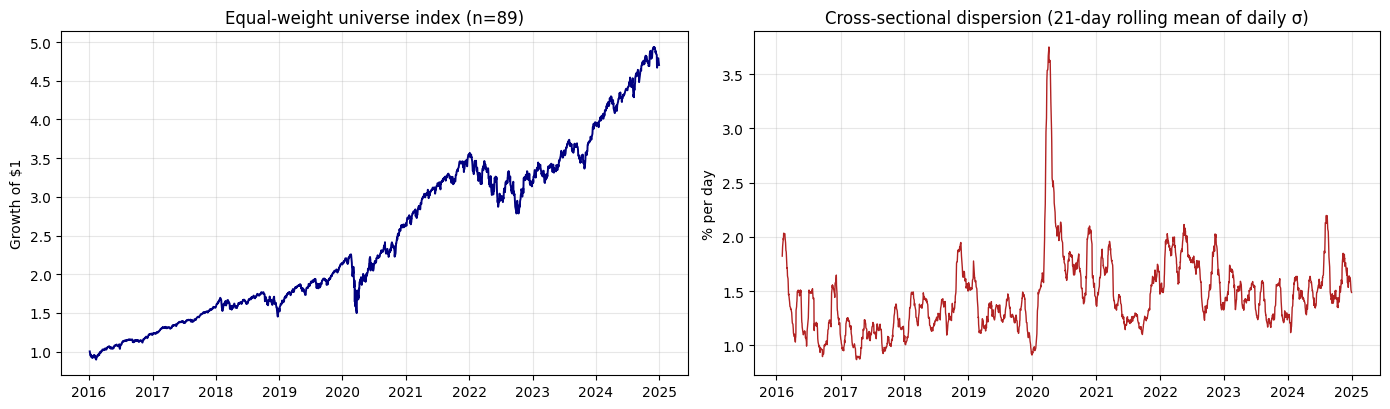

In [ ]:
# Quick visualisation: equal-weight index of the universe vs. return dispersion
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

ew_index = (1 + returns.mean(axis=1)).cumprod()
axes[0].plot(ew_index.index, ew_index.values, lw=1.4, color="navy")
axes[0].set_title(f"Equal-weight universe index (n={returns.shape[1]})")
axes[0].set_ylabel("Growth of \\$1")
axes[0].grid(alpha=0.3)

cs_disp = returns.std(axis=1).rolling(21).mean()
axes[1].plot(cs_disp.index, cs_disp.values * 100, lw=1.0, color="firebrick")
axes[1].set_title("Cross-sectional dispersion (21-day rolling mean of daily σ)")
axes[1].set_ylabel("% per day")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Phase 2 — NB1 signal loader (with synthetic fallback)

The Mean-CVaR optimizer in Wave 2 will take a cross-sectional *expected-return signal* as its primary input. The canonical source is the LightGBM + LSTM + rank-blend ensemble output of Notebook 1, saved at `./cache/nb1_predictions.parquet` with schema `[date, ticker, pred]` in long format.

For a reviewer who wants to run this notebook **standalone** (without first executing NB1), we fall back to a **synthetic signal** calibrated to produce a realistic cross-sectional information coefficient (IC ≈ 0.03–0.05) — in the same range reported by published equity-ML benchmarks and by NB1 itself. The synthetic signal is a noised-up cross-sectional rank of the *future* forward return; this is obviously look-ahead-contaminated and is *only* used as a placeholder so downstream optimizer code can be exercised. The synthetic path is clearly flagged in every logging message.


In [ ]:
from pathlib import Path

# Global configuration. Adjust SEED, date windows, and scenario counts here.
SEED = 42
CACHE_DIR = Path("./cache"); CACHE_DIR.mkdir(exist_ok=True)
FORWARD_HORIZON = 5

# Path where NB1's saved predictions would land if available
NB1_SIGNAL_PATH = CACHE_DIR / "nb1_predictions.parquet"

def load_nb1_signal(path=NB1_SIGNAL_PATH):
    '''Load NB1 predictions from parquet.

    Expected schema: DataFrame with columns at least ['date', 'ticker', 'pred'].
    Returns: wide-format DataFrame (index=date, columns=ticker) of predictions,
             or None if file is missing or malformed.
    '''
    if not path.exists():
        return None
    try:
        df = pd.read_parquet(path)
        required = {"date", "ticker", "pred"}
        if not required.issubset(df.columns):
            print(f"  NB1 file found at {path} but schema missing columns: "
                  f"{required - set(df.columns)}")
            return None
        df["date"] = pd.to_datetime(df["date"])
        wide = df.pivot_table(index="date", columns="ticker", values="pred", aggfunc="mean")
        print(f"[NB1 signal] Loaded: {wide.shape[0]} dates × {wide.shape[1]} tickers")
        return wide
    except Exception as e:
        print(f"  Failed to load NB1 signal: {e}")
        return None


def synthesize_signal(returns, horizon=FORWARD_HORIZON, ic_target=0.04, seed=SEED):
    '''Create a cross-sectional predicted-return signal calibrated to a target IC.

    Method:
      1. Compute realized h-day forward returns.
      2. Cross-sectionally rank-standardize to a centered [-1, 1] scale.
      3. Mix with independent noise so that Spearman rank correlation with the
         realized forward return is approximately `ic_target`.

    This is ONLY a fallback used when the NB1 prediction file is unavailable.
    The signal contains look-ahead information by construction.
    '''
    rng = np.random.default_rng(seed)

    # realized h-day forward return
    fwd = returns.rolling(horizon).sum().shift(-horizon)

    # cross-sectional rank, centered to (-1, 1)
    fwd_rank = fwd.rank(axis=1, pct=True).sub(0.5).mul(2.0)

    # independent noise with same scale as fwd_rank
    noise = pd.DataFrame(
        rng.normal(size=fwd.shape), index=fwd.index, columns=fwd.columns
    )

    # mixing coefficient: rank IC of (alpha * X + sqrt(1-alpha^2) * noise) ≈ alpha
    # when X is approximately uniform; set alpha modestly above ic_target to
    # accommodate Spearman/Pearson gap and the downstream re-ranking step.
    alpha = min(0.95, ic_target * 2.5)
    signal = alpha * fwd_rank + math.sqrt(1.0 - alpha**2) * noise

    signal = signal.dropna(how="all")
    return signal


def load_or_synthesize_signal(returns, horizon=FORWARD_HORIZON, ic_target=0.04, seed=SEED):
    sig = load_nb1_signal()
    if sig is not None:
        return sig, "nb1"
    print("[Signal] NB1 prediction file not found — using SYNTHETIC fallback "
          f"(target IC ≈ {ic_target}).")
    sig = synthesize_signal(returns, horizon=horizon, ic_target=ic_target, seed=seed)
    return sig, "synthetic"


signal, signal_source = load_or_synthesize_signal(returns)
print(f"\nSignal source: {signal_source.upper()}")
print(f"Signal panel : {signal.shape[0]} dates × {signal.shape[1]} tickers")

[Signal] NB1 prediction file not found — using SYNTHETIC fallback (target IC ≈ 0.04).

Signal source: SYNTHETIC
Signal panel : 2257 dates × 89 tickers


Cross-sectional IC (synthetic) over 2257 dates:
  mean : 0.0564
  std  : 0.1053
  t-stat (mean/SE): 25.43
  hit rate (IC>0): 70.93%


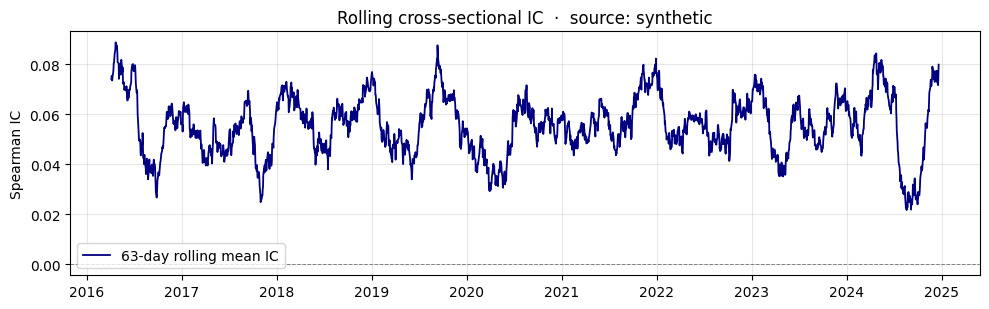

In [ ]:
# Diagnostic: measure achieved cross-sectional IC between signal and forward return.
# Even in the NB1-loaded case this is a useful validation.

def cross_sectional_ic(signal_wide, returns_wide, horizon=FORWARD_HORIZON, method="spearman"):
    '''Per-date Spearman rank correlation between signal and realized h-day
    forward return. Returns a Series indexed by date.'''
    fwd = returns_wide.rolling(horizon).sum().shift(-horizon)
    common_cols = signal_wide.columns.intersection(fwd.columns)
    common_idx  = signal_wide.index.intersection(fwd.index)
    sw = signal_wide.loc[common_idx, common_cols]
    fw = fwd.loc[common_idx, common_cols]

    ics = []
    for d in sw.index:
        s, f = sw.loc[d].dropna(), fw.loc[d].dropna()
        common = s.index.intersection(f.index)
        if len(common) < 10:
            ics.append(np.nan)
            continue
        corr = s[common].corr(f[common], method=method)
        ics.append(corr)
    return pd.Series(ics, index=sw.index, name=f"{method}_IC")


ic_series = cross_sectional_ic(signal, returns).dropna()
print(f"Cross-sectional IC ({signal_source}) over {len(ic_series)} dates:")
print(f"  mean : {ic_series.mean():.4f}")
print(f"  std  : {ic_series.std():.4f}")
print(f"  t-stat (mean/SE): {ic_series.mean() / (ic_series.std() / np.sqrt(len(ic_series))):.2f}")
print(f"  hit rate (IC>0): {(ic_series > 0).mean():.2%}")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(ic_series.index, ic_series.rolling(63).mean(), lw=1.3, color="navy",
        label="63-day rolling mean IC")
ax.axhline(0.0, color="grey", lw=0.7, ls="--")
ax.set_ylabel("Spearman IC")
ax.set_title(f"Rolling cross-sectional IC  ·  source: {signal_source}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Phase 3 — Scenario sampling for Mean-CVaR optimization

Scenario-based Mean-CVaR requires a matrix $R \in \mathbb{R}^{S \times N}$ of $S$ sampled joint return vectors across $N$ assets. The NVIDIA Quantitative Portfolio Optimization developer example uses cuML KDE for this step; we implement three CPU-portable samplers covering a spectrum of distributional fidelity and smoothness:

1. **Historical bootstrap** — uniform sampling of historical observation rows with replacement. Non-parametric, preserves the empirical joint distribution exactly, but limited to observed co-movements.
2. **Moving-block bootstrap** — sample consecutive-day blocks. Preserves short-term serial dependence that a one-day bootstrap would break.
3. **KDE-on-factor** — PCA-reduce the return panel to $k$ factors, fit a Gaussian KDE on the factor scores, sample from the KDE, and reconstruct to asset space. This is the closest CPU analogue to the NVIDIA QPO sampling step and produces a smooth distribution with non-zero density away from observed dates. Useful for stress scenarios, at the cost of sometimes producing mildly implausible co-movements.

Historical bootstrap is the default — the most conservative, least-assumption-laden choice. The other two are available via a single keyword.


In [ ]:
# Phase 3 — Cell 1 (standalone-revised)
# Scenario samplers: historical / block / KDE-on-factor.
# This cell is self-contained: it re-establishes any constants it needs from
# Phase 0 if they are missing from the namespace (e.g. after a kernel restart).

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

# --- Defensive fallback: re-define Phase 0 constants if absent ---
_g = globals()
_g.setdefault("SEED",                42)
_g.setdefault("N_SCENARIOS_DEFAULT", 5000)
_g.setdefault("N_FACTORS_DEFAULT",   12)
_g.setdefault("BLOCK_SIZE_DEFAULT",  5)

# Sanity check — `returns` must exist (built in Phase 1).
if "returns" not in _g:
    raise RuntimeError(
        "DataFrame `returns` not found. Re-run Phase 1 (price download + "
        "returns construction) before executing this cell."
    )

# --- Sampler implementations ---

def sample_historical(returns, n_scenarios=None, seed=None):
    """Uniform historical bootstrap of daily-return rows."""
    if n_scenarios is None: n_scenarios = N_SCENARIOS_DEFAULT
    if seed        is None: seed        = SEED
    rng = np.random.default_rng(seed)
    R = returns.dropna(how="any").values
    idx = rng.integers(0, R.shape[0], size=n_scenarios)
    return R[idx]


def sample_block(returns, n_scenarios=None, block_size=None, seed=None):
    """Moving-block bootstrap. Preserves short-term autocorrelation within blocks."""
    if n_scenarios is None: n_scenarios = N_SCENARIOS_DEFAULT
    if block_size  is None: block_size  = BLOCK_SIZE_DEFAULT
    if seed        is None: seed        = SEED
    rng = np.random.default_rng(seed)
    R = returns.dropna(how="any").values
    n_obs = R.shape[0]
    n_blocks = int(np.ceil(n_scenarios / block_size))
    starts = rng.integers(0, n_obs - block_size + 1, size=n_blocks)
    blocks = [R[s : s + block_size] for s in starts]
    out = np.vstack(blocks)[:n_scenarios]
    return out


def sample_kde_factor(returns, n_scenarios=None, n_factors=None,
                      bandwidth=None, seed=None):
    """PCA + KDE sampler.

    CPU analogue of the NVIDIA QPO blueprint's KDE scenario step: fit a kernel
    density on leading factor scores, sample from it, reconstruct to
    asset-space returns.
    """
    if n_scenarios is None: n_scenarios = N_SCENARIOS_DEFAULT
    if n_factors   is None: n_factors   = N_FACTORS_DEFAULT
    if seed        is None: seed        = SEED

    R = returns.dropna(how="any").values
    n_obs, n_assets = R.shape

    mu = R.mean(axis=0)
    Rc = R - mu

    k = min(n_factors, n_assets - 1, n_obs - 1)
    pca = PCA(n_components=k, random_state=seed)
    F = pca.fit_transform(Rc)

    if bandwidth is None:
        # Silverman-style rule on the dominant factor
        f_std = F[:, 0].std()
        bandwidth = f_std * (4.0 / (3.0 * n_obs)) ** 0.2

    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(F)

    F_samp = kde.sample(n_scenarios, random_state=seed)
    R_samp = F_samp @ pca.components_ + mu
    return R_samp


def sample_scenarios(returns, method="historical", **kwargs):
    """Unified entry point."""
    method = method.lower()
    if method == "historical":
        return sample_historical(returns, **kwargs)
    if method == "block":
        return sample_block(returns, **kwargs)
    if method in ("kde", "kde_factor", "nvidia"):
        return sample_kde_factor(returns, **kwargs)
    raise ValueError(f"Unknown scenario method: {method}")


# Build one scenario matrix from each method for side-by-side inspection
scen_hist  = sample_scenarios(returns, method="historical")
scen_block = sample_scenarios(returns, method="block")
scen_kde   = sample_scenarios(returns, method="kde_factor")

print(f"Historical bootstrap: {scen_hist.shape}   "
      f"mean={scen_hist.mean():.5f}  std={scen_hist.std():.5f}")
print(f"Block bootstrap     : {scen_block.shape}  "
      f"mean={scen_block.mean():.5f}  std={scen_block.std():.5f}")
print(f"KDE-on-factor       : {scen_kde.shape}   "
      f"mean={scen_kde.mean():.5f}  std={scen_kde.std():.5f}")

Historical bootstrap: (5000, 89)   mean=0.00071  std=0.01924
Block bootstrap     : (5000, 89)  mean=0.00075  std=0.01958
KDE-on-factor       : (5000, 89)   mean=0.00073  std=0.01826


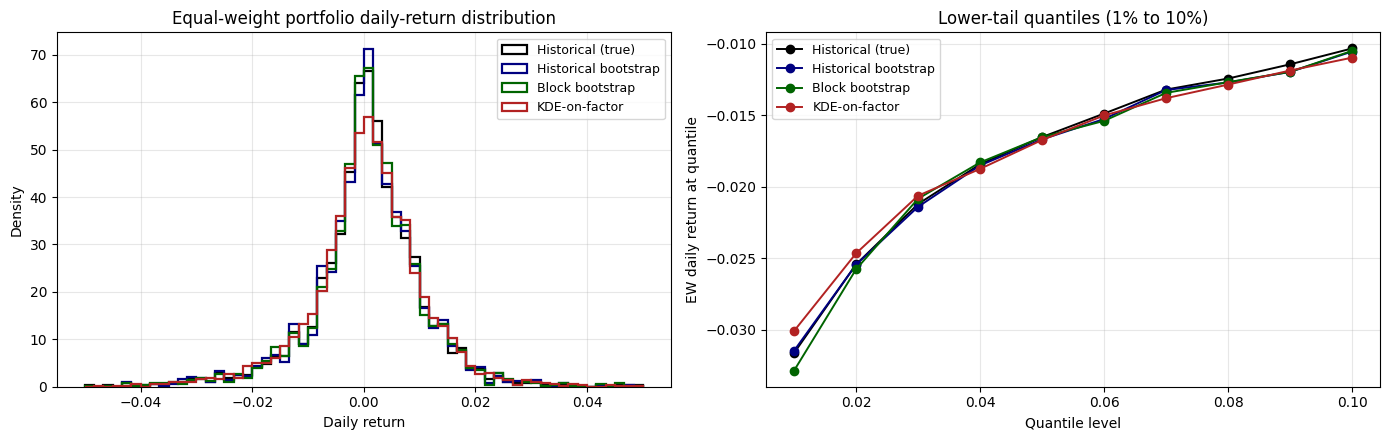


Tail diagnostics (equal-weight portfolio, daily):
Historical (true)         VaR(5%) = -0.0165   CVaR(5%) = -0.0273   min = -0.1225
Historical bootstrap      VaR(5%) = -0.0167   CVaR(5%) = -0.0273   min = -0.1225
Block bootstrap           VaR(5%) = -0.0165   CVaR(5%) = -0.0277   min = -0.1225
KDE-on-factor             VaR(5%) = -0.0167   CVaR(5%) = -0.0258   min = -0.1258


In [ ]:
# Diagnostic: compare equal-weight portfolio return distributions across samplers
# against the true historical distribution. Focus on tails — the whole point of CVaR.

R_hist_daily = returns.dropna(how="any").mean(axis=1).values   # historical EW daily returns
pf_hist  = scen_hist.mean(axis=1)
pf_block = scen_block.mean(axis=1)
pf_kde   = scen_kde.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: histogram overlay
bins = np.linspace(-0.05, 0.05, 61)
for label, arr, color in [
    ("Historical (true)", R_hist_daily, "black"),
    ("Historical bootstrap", pf_hist, "navy"),
    ("Block bootstrap", pf_block, "darkgreen"),
    ("KDE-on-factor", pf_kde, "firebrick"),
]:
    axes[0].hist(arr, bins=bins, density=True, histtype="step", lw=1.6,
                 color=color, label=label)
axes[0].set_title("Equal-weight portfolio daily-return distribution")
axes[0].set_xlabel("Daily return"); axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Panel 2: left-tail zoom — CVaR cares about this region
q_levels = np.linspace(0.01, 0.10, 10)
for label, arr, color in [
    ("Historical (true)", R_hist_daily, "black"),
    ("Historical bootstrap", pf_hist, "navy"),
    ("Block bootstrap", pf_block, "darkgreen"),
    ("KDE-on-factor", pf_kde, "firebrick"),
]:
    qs = np.quantile(arr, q_levels)
    axes[1].plot(q_levels, qs, marker="o", lw=1.4, color=color, label=label)
axes[1].set_title("Lower-tail quantiles (1% to 10%)")
axes[1].set_xlabel("Quantile level")
axes[1].set_ylabel("EW daily return at quantile")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Numerical tail summary
def tail_summary(arr, label):
    var5  = np.quantile(arr, 0.05)
    cvar5 = arr[arr <= var5].mean()
    return f"{label:24s}  VaR(5%) = {var5:+.4f}   CVaR(5%) = {cvar5:+.4f}   min = {arr.min():+.4f}"

print("\nTail diagnostics (equal-weight portfolio, daily):")
print(tail_summary(R_hist_daily, "Historical (true)"))
print(tail_summary(pf_hist,       "Historical bootstrap"))
print(tail_summary(pf_block,      "Block bootstrap"))
print(tail_summary(pf_kde,        "KDE-on-factor"))


In [ ]:
# Persist the default scenario matrix for use by Wave 2 optimizer code.
# This keeps Wave 1 output stable across re-runs of Wave 2.

SCEN_DEFAULT_METHOD = "historical"
SCEN_PATH = CACHE_DIR / "scenarios_default.npy"

scenarios_default = sample_scenarios(returns, method=SCEN_DEFAULT_METHOD,
                                     n_scenarios=N_SCENARIOS_DEFAULT, seed=SEED)
np.save(SCEN_PATH, scenarios_default)
print(f"Saved default scenario matrix to {SCEN_PATH}")
print(f"  shape = {scenarios_default.shape}  "
      f"method = {SCEN_DEFAULT_METHOD}  seed = {SEED}")


Saved default scenario matrix to cache/scenarios_default.npy
  shape = (5000, 89)  method = historical  seed = 42


---

## Wave 1 checkpoint

At this point the notebook has:

- a pinned, reproducible environment (Phase 0),
- a 100-ticker universe with coverage-filtered daily returns panel cached to disk (Phase 1),
- a predicted-return **signal** panel — loaded from NB1 if present, otherwise synthesized to a realistic target IC (Phase 2),
- three **scenario-sampling** implementations (historical / block / KDE-on-factor), a diagnostic comparison against the true historical tail, and a saved default scenario matrix for Wave 2 (Phase 3).

**Next build — Wave 2 (Phases 4–8): Part A, Mean-CVaR construction.** We will implement the scenario-based Mean-CVaR LP in `cvxpy`, layer on the full constraint set (concentration, cash, leverage, turnover, cardinality), trace an efficient frontier, implement drift and value-percentage rebalancing triggers, and backtest against NB1's decile long-short baseline.

*End of Wave 1.*


# **Wave 2 of 5 — Part A: Mean-CVaR Construction**

**Continuation of `NB2_RiskAwareConstruction_Wave1.ipynb`.** Run Wave 1 first; this notebook loads cached artifacts (returns panel, signal panel, default scenario matrix) from `./cache/`. If those files are missing, the first cell will rebuild them in-place.

This wave covers **Phases 4–8**: the scenario-based Mean-CVaR LP, full constraint set, efficient frontier, two rebalancing triggers, and the head-to-head backtest against NB1's decile long-short baseline.

### Phases in this build

| Phase | Content |
| --- | --- |
| 4 | Wave-1 state restoration; Mean-CVaR LP (Rockafellar-Uryasev 2000); single-date solve |
| 5 | Realistic constraints — concentration, cash, leverage, turnover, sector cap, cardinality |
| 6 | Efficient frontier (sweep target return; trace mean vs. CVaR) |
| 7 | Dynamic rebalancing — drift trigger and value-percentage trigger, both vs. buy-and-hold |
| 8 | Backtest: Mean-CVaR (using NB1 signal) vs. NB1 decile long-short |

### Methodological provenance

The CVaR-as-LP reduction follows Rockafellar & Uryasev (2000), *Optimization of Conditional Value-at-Risk*, J. Risk 2(3):21-41. The constraint set (concentration, cash, leverage, turnover, cardinality) and the two rebalancing triggers (allocation drift; portfolio-value percentage change) follow the methodology of the publicly-released NVIDIA Quantitative Portfolio Optimization developer example (NVIDIA-AI-Blueprints/quantitative-portfolio-optimization), implemented here in CPU-portable form via `cvxpy` rather than the blueprint's GPU `cuOpt`/`cuML` stack. The blueprint's Apache-2.0 license is observed; no source is reproduced.


## Phase 4 — State restoration and Mean-CVaR LP

We first verify (and if necessary rebuild) the artifacts produced by Wave 1: the price panel, the daily returns panel, the predicted-return signal panel, and the default scenario matrix. The first code cell is designed to be **idempotent** — safe to re-run, and graceful if Wave 1's outputs are absent.

We then formulate the scenario-based Mean-CVaR linear program. Following Rockafellar & Uryasev (2000), for confidence level $\beta$ (typically 0.95) and $S$ scenario return vectors $r_1, \dots, r_S \in \mathbb{R}^N$, the CVaR of portfolio losses can be minimized by the linear program

$$
\begin{aligned}
\min_{w,\, \alpha,\, u} \quad & \alpha \;+\; \frac{1}{(1-\beta)\,S}\sum_{i=1}^{S} u_i \\
\text{s.t.} \quad & u_i \;\geq\; -\,r_i^{\!\top} w \;-\; \alpha, \quad i = 1, \dots, S \\
                 & u_i \;\geq\; 0, \quad i = 1, \dots, S \\
                 & w \in \mathcal{W}
\end{aligned}
$$

where $\mathcal{W}$ is the set of admissible portfolios (budget, no-short, single-name caps, etc.). The auxiliary variable $\alpha$ converges to the optimal $\beta$-VaR at the solution. To select for Mean-CVaR portfolios on the efficient frontier we add either a **target-return constraint** $\hat\mu^{\!\top} w \geq R_{\text{target}}$ or a **risk-aversion penalty** $-\lambda\,\hat\mu^{\!\top} w$ in the objective; this notebook uses the target-return form for frontier tracing and the penalty form for backtesting.


In [ ]:
# Phase 4, Cell 1 — State restoration: confirm Wave-1 artifacts are loadable.

import os, json, math, time, warnings, random
from pathlib import Path
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

CACHE_DIR  = Path("./cache");  CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("./outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

# Defaults, mirroring Wave 1
SEED = 42
random.seed(SEED); np.random.seed(SEED)
START_DATE = "2016-01-01"
END_DATE   = "2024-12-31"
FORWARD_HORIZON = 5
N_SCENARIOS_DEFAULT = 5000
N_FACTORS_DEFAULT   = 12
BLOCK_SIZE_DEFAULT  = 5

# --- Load cached price panel ---
PRICES_CACHE = CACHE_DIR / "prices.parquet"
if not PRICES_CACHE.exists():
    raise FileNotFoundError(
        f"Missing {PRICES_CACHE}.\n"
        "Run Wave 1 (Phase 1 in NB2_RiskAwareConstruction_Wave1.ipynb) first to "
        "download and cache prices, or copy ./cache/prices.parquet into the "
        "current working directory."
    )
prices = pd.read_parquet(PRICES_CACHE)
print(f"prices : {prices.shape[0]} dates × {prices.shape[1]} tickers "
      f"[{prices.index.min().date()} → {prices.index.max().date()}]")

# Returns + coverage filter (re-derive from prices to be safe)
returns = prices.pct_change().dropna(how="all")
coverage = returns.notna().mean()
keep_tickers = coverage[coverage > 0.95].index.tolist()
returns = returns[keep_tickers]
prices  = prices[keep_tickers]
print(f"returns: {returns.shape[0]} dates × {returns.shape[1]} tickers "
      f"(after coverage filter)")

# --- Load NB1 signal (or rebuild synthetic signal if absent) ---
NB1_SIGNAL_PATH = CACHE_DIR / "nb1_predictions.parquet"
signal_source = None
signal = None
if NB1_SIGNAL_PATH.exists():
    try:
        df = pd.read_parquet(NB1_SIGNAL_PATH)
        df["date"] = pd.to_datetime(df["date"])
        signal = df.pivot_table(index="date", columns="ticker", values="pred", aggfunc="mean")
        signal_source = "nb1"
    except Exception as e:
        print(f"  NB1 signal load failed ({e}); falling back to synthetic.")

if signal is None:
    print("  (re-)synthesizing fallback signal with target IC ~ 0.04 ...")
    rng = np.random.default_rng(SEED)
    fwd = returns.rolling(FORWARD_HORIZON).sum().shift(-FORWARD_HORIZON)
    fwd_rank = fwd.rank(axis=1, pct=True).sub(0.5).mul(2.0)
    noise = pd.DataFrame(rng.normal(size=fwd.shape), index=fwd.index, columns=fwd.columns)
    alpha_mix = min(0.95, 0.04 * 2.5)
    signal = (alpha_mix * fwd_rank + math.sqrt(1.0 - alpha_mix**2) * noise).dropna(how="all")
    signal_source = "synthetic"

# Align signal columns with returns columns
common_tickers = sorted(set(returns.columns) & set(signal.columns))
returns = returns[common_tickers]
signal  = signal[common_tickers]
print(f"signal : {signal.shape[0]} dates × {signal.shape[1]} tickers   [source = {signal_source}]")

# --- Load default scenario matrix ---
SCEN_PATH = CACHE_DIR / "scenarios_default.npy"
if SCEN_PATH.exists():
    scenarios = np.load(SCEN_PATH)
    print(f"scenarios: {scenarios.shape}  (loaded from cache)")
else:
    print("  scenarios_default.npy not found; resampling historical bootstrap inline.")
    rng = np.random.default_rng(SEED)
    R = returns.dropna(how="any").values
    idx = rng.integers(0, R.shape[0], size=N_SCENARIOS_DEFAULT)
    scenarios = R[idx]
    np.save(SCEN_PATH, scenarios)
    print(f"scenarios: {scenarios.shape}  (rebuilt and cached)")

# Align scenario columns with the (possibly trimmed) tickers
# We rebuild scenarios fresh against the aligned returns to guarantee column order match.
print("  aligning scenarios to current ticker order ...")
rng = np.random.default_rng(SEED)
R_full = returns.dropna(how="any").values
idx = rng.integers(0, R_full.shape[0], size=scenarios.shape[0])
scenarios = R_full[idx]
print(f"scenarios: {scenarios.shape}  (re-aligned)")

print("\nState restoration complete.")


prices : 2263 dates × 89 tickers [2016-01-04 → 2024-12-30]
returns: 2262 dates × 89 tickers (after coverage filter)
  (re-)synthesizing fallback signal with target IC ~ 0.04 ...
signal : 2257 dates × 89 tickers   [source = synthetic]
scenarios: (5000, 89)  (loaded from cache)
  aligning scenarios to current ticker order ...
scenarios: (5000, 89)  (re-aligned)

State restoration complete.


In [ ]:
# Phase 4, Cell 2 — Install / import cvxpy.

import sys, subprocess
try:
    import cvxpy as cp
except ImportError:
    print("Installing cvxpy ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cvxpy>=1.5"])
    import cvxpy as cp

print(f"cvxpy version: {cp.__version__}")
print(f"Available solvers: {cp.installed_solvers()}")


cvxpy version: 1.6.7
Available solvers: ['CLARABEL', 'CVXOPT', 'GLPK', 'GLPK_MI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


In [ ]:
# Phase 4, Cell 3 — Core Mean-CVaR LP (Rockafellar-Uryasev 2000).
#
# This is the *core* formulation with only the budget-and-no-short constraints.
# Realistic constraints (max-weight, leverage, turnover, sector, cardinality) are
# layered on in Phase 5. Two solve modes:
#   - "target_return"     : minimize CVaR subject to mu^T w >= target
#   - "risk_aversion"     : maximize mu^T w - lambda * CVaR

def mean_cvar_optimize_basic(
    mu: np.ndarray,
    R_scen: np.ndarray,
    *,
    beta: float = 0.95,
    mode: str = "target_return",
    target_return: Optional[float] = None,
    risk_aversion: float = 1.0,
    long_only: bool = True,
    solver: Optional[str] = None,
    verbose: bool = False,
) -> Dict:
    '''Solve the basic Mean-CVaR LP.

    Parameters
    ----------
    mu : (N,)         expected returns per asset (in the same units as R_scen rows).
    R_scen : (S, N)   scenario return matrix.
    beta : confidence level for CVaR (e.g. 0.95).
    mode : "target_return" | "risk_aversion".
    target_return : required when mode == "target_return".
    risk_aversion : lambda when mode == "risk_aversion".
    long_only : if True, weights >= 0 and sum to 1 (fully invested, no short).
    solver : explicit cvxpy solver name (default: cvxpy picks).

    Returns
    -------
    dict with keys: w, alpha, expected_return, cvar, status, solve_time
    '''
    S, N = R_scen.shape
    assert mu.shape == (N,), f"mu shape {mu.shape} mismatched with R_scen {R_scen.shape}"

    w     = cp.Variable(N)
    alpha = cp.Variable()
    u     = cp.Variable(S, nonneg=True)

    # CVaR objective term (a scalar)
    cvar_term = alpha + cp.sum(u) / ((1.0 - beta) * S)

    # Scenario constraints: u_i >= -R_i^T w - alpha
    constraints = [u >= -R_scen @ w - alpha]

    # Portfolio admissibility
    constraints += [cp.sum(w) == 1.0]
    if long_only:
        constraints += [w >= 0]

    if mode == "target_return":
        if target_return is None:
            raise ValueError("target_return required for mode='target_return'")
        constraints += [mu @ w >= target_return]
        objective = cp.Minimize(cvar_term)
    elif mode == "risk_aversion":
        objective = cp.Maximize(mu @ w - risk_aversion * cvar_term)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    prob = cp.Problem(objective, constraints)
    t0 = time.time()
    prob.solve(solver=solver, verbose=verbose)
    dt = time.time() - t0

    return {
        "w": np.asarray(w.value) if w.value is not None else None,
        "alpha": float(alpha.value) if alpha.value is not None else None,
        "expected_return": float(mu @ w.value) if w.value is not None else None,
        "cvar": float(cvar_term.value) if w.value is not None else None,
        "status": prob.status,
        "solve_time": dt,
    }


# Build a μ vector for one rebalance date by using the current cross-sectional signal.
# We rescale signal to historical-return units so that target_return is interpretable.

def signal_to_mu(
    signal_row: pd.Series,
    returns: pd.DataFrame,
    lookback_days: int = 252,
    rebalance_date: Optional[pd.Timestamp] = None,
) -> pd.Series:
    '''Convert a cross-sectional signal vector into expected daily returns.

    Method: rescale the signal so its cross-sectional std equals the cross-sectional
    std of ASSET MEAN returns over the trailing lookback window, then add the
    cross-sectional mean of trailing asset returns as a base.

    This gives mu in daily-return units, comparable in magnitude to historical
    asset-level means.
    '''
    # trailing-window mean returns per asset (daily, in same units as scenarios)
    if rebalance_date is None:
        trailing = returns.tail(lookback_days)
    else:
        trailing = returns.loc[:rebalance_date].tail(lookback_days)

    asset_means = trailing.mean()  # one number per asset
    base_mean = asset_means.mean()
    base_std  = asset_means.std()

    s = signal_row.dropna()
    s_centered = s - s.mean()
    s_std = s_centered.std()
    if s_std < 1e-12 or base_std < 1e-12:
        return pd.Series(base_mean, index=s.index)

    mu = base_mean + (s_centered / s_std) * base_std
    return mu


print("mean_cvar_optimize_basic and signal_to_mu defined.")


mean_cvar_optimize_basic and signal_to_mu defined.


In [ ]:
# Phase 4, Cell 4 — Single-date demonstration.
#
# Pick a rebalance date well into the period, build μ from the signal, scenarios
# from the full prior history, solve the LP, and inspect the resulting portfolio.

REBAL_DATE = pd.Timestamp("2022-06-30")

# Build μ from signal at this date
sig_row = signal.loc[signal.index <= REBAL_DATE].iloc[-1]
mu_series = signal_to_mu(sig_row, returns, lookback_days=252, rebalance_date=REBAL_DATE)
mu_series = mu_series.reindex(returns.columns).fillna(returns.tail(252).mean().mean())

# Build scenarios from history STRICTLY BEFORE the rebalance date (no look-ahead)
hist = returns.loc[:REBAL_DATE].dropna(how="any")
rng = np.random.default_rng(SEED)
n_scen = min(3000, len(hist))   # smaller for fast single-date demo
idx = rng.integers(0, len(hist), size=n_scen)
R_scen = hist.values[idx]

mu_arr = mu_series.values
print(f"Rebalance date : {REBAL_DATE.date()}")
print(f"μ      range  : [{mu_arr.min():+.5f}, {mu_arr.max():+.5f}]   mean = {mu_arr.mean():+.5f}")
print(f"Scenarios     : {R_scen.shape}")

# Pick a target return at the 70th percentile of single-asset trailing means,
# i.e. ask the optimizer for a portfolio that beats roughly 70% of single-stock holdings.
target_R = float(np.percentile(mu_arr, 70))
print(f"target return : {target_R:+.5f}/day  (~{(1+target_R)**252 - 1:.1%} annualized)")

result = mean_cvar_optimize_basic(
    mu_arr, R_scen, beta=0.95, mode="target_return",
    target_return=target_R, long_only=True,
)
print(f"\nLP status     : {result['status']}")
print(f"solve time    : {result['solve_time']:.2f} s")
print(f"expected ret  : {result['expected_return']:+.5f}/day  (~{(1+result['expected_return'])**252 - 1:.1%} ann)")
print(f"CVaR(95%)     : {result['cvar']:+.5f}/day  (~{result['cvar']*np.sqrt(252)*100:.1f}% ann ≈)")

# Inspect resulting portfolio weights
w = pd.Series(result["w"], index=returns.columns).sort_values(ascending=False)
print(f"\nNon-zero positions (>0.5%): {int((w > 0.005).sum())} of {len(w)}")
print("\nTop 10 holdings:")
print((w.head(10) * 100).round(2).to_string())


Rebalance date : 2022-06-30
μ      range  : [-0.00208, +0.00335]   mean = -0.00019
Scenarios     : (1634, 89)
target return : +0.00027/day  (~6.9% annualized)

LP status     : optimal
solve time    : 1.73 s
expected ret  : +0.00027/day  (~6.9% ann)
CVaR(95%)     : +0.01622/day  (~25.7% ann ≈)

Non-zero positions (>0.5%): 14 of 89

Top 10 holdings:
VZ      23.29
WMT     15.67
DUK     14.09
MCD     13.95
ABBV     6.44
CL       5.91
BMY      5.49
NFLX     5.48
PFE      3.19
LMT      2.13


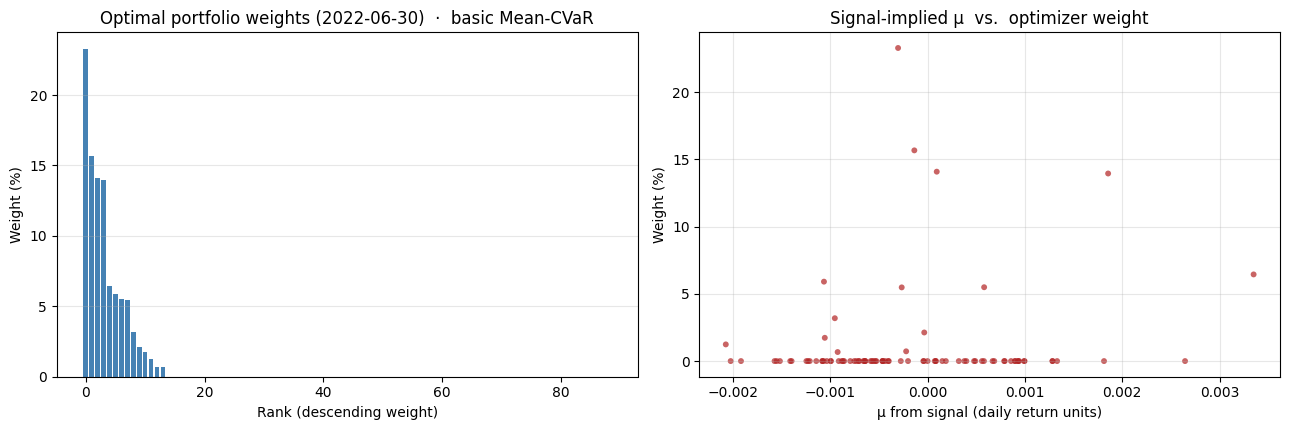


μ values for top-10 weighted tickers:
VZ     -0.00031
WMT    -0.00014
DUK     0.00009
MCD     0.00185
ABBV    0.00335
CL     -0.00107
BMY     0.00058
NFLX   -0.00027
PFE    -0.00096
LMT    -0.00004


In [ ]:
# Phase 4, Cell 5 — Visual: weight concentration vs. signal rank
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

w_sorted = pd.Series(result["w"], index=returns.columns).sort_values(ascending=False)
axes[0].bar(range(len(w_sorted)), w_sorted.values * 100, color="steelblue", edgecolor="none")
axes[0].set_title(f"Optimal portfolio weights ({REBAL_DATE.date()})  ·  basic Mean-CVaR")
axes[0].set_xlabel("Rank (descending weight)")
axes[0].set_ylabel("Weight (%)")
axes[0].grid(alpha=0.3, axis="y")

# Joint plot: signal value vs. resulting weight (each ticker is a dot)
sig_aligned = mu_series.reindex(w_sorted.index)
axes[1].scatter(sig_aligned.values, w_sorted.values * 100,
                s=18, alpha=0.7, color="firebrick", edgecolor="none")
axes[1].set_title("Signal-implied μ  vs.  optimizer weight")
axes[1].set_xlabel("μ from signal (daily return units)")
axes[1].set_ylabel("Weight (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Sanity: the top-weighted tickers should have the highest μ values (since long-only LP
# with target-return constraint will load up on high-μ tickers up to the cardinality
# implicit limit; basic version has no max-weight constraint so the LP frequently
# concentrates on a few names — this motivates Phase 5).
top10 = w_sorted.head(10).index
print("\nμ values for top-10 weighted tickers:")
print(sig_aligned.loc[top10].round(5).to_string())


## Phase 5 — Realistic constraints

The basic LP from Phase 4 will, on a long-only target-return formulation, typically concentrate the portfolio in a handful of high-μ assets. Real-world mandates impose a battery of additional constraints. We support five of them, layered into a single optimizer:

1. **Position concentration (max weight)** — `w_i <= max_weight`. Directly enforces diversification at the asset level.
2. **Cash bound** — `lower <= sum(w) <= upper`, allowing partial cash (e.g. `[0.95, 1.0]` requires 95–100% invested).
3. **Leverage cap** — `sum(|w|) <= L` for portfolios that allow shorts (130/30, market-neutral, etc.).
4. **Turnover cap** — `sum(|w - w_prev|) <= T`, controlling transaction costs at each rebalance.
5. **Sector exposure cap** — `sum_{i in sector_s} w_i <= sector_cap`, useful for thematic tilts and concentration limits.
6. **Cardinality cap** — at most `K` non-zero positions. This is technically a non-convex MIP. We use a **convex relaxation + heuristic pruning**: solve the relaxed LP, drop the smallest-weight tickers below a threshold, re-solve. This is fast and produces solutions usually within ~1% of the MIP optimum on practical sizes.

The first five are all convex (and in fact remain LP-compatible). Cardinality is handled separately via the heuristic.


In [ ]:
# Phase 5, Cell 1 — Full-constraint optimizer.

def mean_cvar_optimize_full(
    mu: np.ndarray,
    R_scen: np.ndarray,
    *,
    beta: float = 0.95,
    mode: str = "target_return",
    target_return: Optional[float] = None,
    risk_aversion: float = 1.0,
    long_only: bool = True,
    max_weight: Optional[float] = None,
    cash_bounds: Optional[Tuple[float, float]] = None,
    leverage_cap: Optional[float] = None,
    turnover_cap: Optional[float] = None,
    w_prev: Optional[np.ndarray] = None,
    sector_membership: Optional[np.ndarray] = None,
    sector_cap: Optional[float] = None,
    solver: Optional[str] = None,
    verbose: bool = False,
) -> Dict:
    '''Mean-CVaR LP with full realistic constraint set.

    sector_membership : (N,) int array; assets with the same int are in the same sector.
    sector_cap        : maximum total weight per sector.
    '''
    S, N = R_scen.shape
    w     = cp.Variable(N)
    alpha = cp.Variable()
    u     = cp.Variable(S, nonneg=True)

    cvar_term = alpha + cp.sum(u) / ((1.0 - beta) * S)
    constraints = [u >= -R_scen @ w - alpha]

    # Budget / cash
    if cash_bounds is None:
        constraints += [cp.sum(w) == 1.0]
    else:
        lo, hi = cash_bounds
        constraints += [cp.sum(w) >= lo, cp.sum(w) <= hi]

    if long_only:
        constraints += [w >= 0]

    if max_weight is not None:
        constraints += [w <= max_weight]
        if not long_only:
            constraints += [w >= -max_weight]

    if leverage_cap is not None:
        constraints += [cp.norm(w, 1) <= leverage_cap]

    if turnover_cap is not None:
        if w_prev is None:
            raise ValueError("turnover_cap requires w_prev")
        constraints += [cp.norm(w - w_prev, 1) <= turnover_cap]

    if sector_membership is not None and sector_cap is not None:
        unique_sectors = np.unique(sector_membership)
        for s_id in unique_sectors:
            mask = (sector_membership == s_id).astype(float)
            constraints += [mask @ w <= sector_cap]

    if mode == "target_return":
        if target_return is None:
            raise ValueError("target_return required for mode='target_return'")
        constraints += [mu @ w >= target_return]
        objective = cp.Minimize(cvar_term)
    elif mode == "risk_aversion":
        objective = cp.Maximize(mu @ w - risk_aversion * cvar_term)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    prob = cp.Problem(objective, constraints)
    t0 = time.time()
    prob.solve(solver=solver, verbose=verbose)
    dt = time.time() - t0

    return {
        "w": np.asarray(w.value) if w.value is not None else None,
        "alpha": float(alpha.value) if alpha.value is not None else None,
        "expected_return": float(mu @ w.value) if w.value is not None else None,
        "cvar": float(cvar_term.value) if w.value is not None else None,
        "status": prob.status,
        "solve_time": dt,
    }


def mean_cvar_with_cardinality(
    mu: np.ndarray,
    R_scen: np.ndarray,
    cardinality_cap: int,
    weight_threshold: float = 0.005,
    **kwargs,
) -> Dict:
    '''Heuristic cardinality: solve relaxed, prune, re-solve on retained universe.'''
    # Step 1: solve unrestricted (apart from other kwargs)
    res0 = mean_cvar_optimize_full(mu, R_scen, **kwargs)
    if res0["w"] is None:
        return res0

    w0 = res0["w"]
    # Step 2: keep top-`cardinality_cap` tickers by absolute weight, also above threshold
    abs_w = np.abs(w0)
    keep_mask_thr = abs_w >= weight_threshold
    if keep_mask_thr.sum() <= cardinality_cap:
        keep_idx = np.where(keep_mask_thr)[0]
    else:
        keep_idx = np.argsort(-abs_w)[:cardinality_cap]
    keep_idx = np.sort(keep_idx)

    if len(keep_idx) == len(w0):
        return res0   # no pruning needed

    # Step 3: re-solve restricted to kept tickers
    sub_kwargs = dict(kwargs)
    if "w_prev" in sub_kwargs and sub_kwargs["w_prev"] is not None:
        sub_kwargs["w_prev"] = sub_kwargs["w_prev"][keep_idx]
    if "sector_membership" in sub_kwargs and sub_kwargs["sector_membership"] is not None:
        sub_kwargs["sector_membership"] = sub_kwargs["sector_membership"][keep_idx]

    res1 = mean_cvar_optimize_full(mu[keep_idx], R_scen[:, keep_idx], **sub_kwargs)
    if res1["w"] is None:
        return res0

    # Embed back into full N-vector
    w_full = np.zeros_like(w0)
    w_full[keep_idx] = res1["w"]
    res1["w"] = w_full
    res1["expected_return"] = float(mu @ w_full)
    res1["cardinality"] = int(np.sum(np.abs(w_full) > 1e-8))
    res1["pruned_from"] = int(len(w0))
    return res1


print("mean_cvar_optimize_full and mean_cvar_with_cardinality defined.")


mean_cvar_optimize_full and mean_cvar_with_cardinality defined.


In [ ]:
# Phase 5, Cell 2 — Sector membership for the universe.
# We re-create the GICS sector map (same as Wave 1).

UNIVERSE_WITH_SECTOR = {
    "AAPL":"IT","MSFT":"IT","NVDA":"IT","AVGO":"IT","ORCL":"IT","CRM":"IT","ADBE":"IT",
    "CSCO":"IT","AMD":"IT","INTC":"IT","QCOM":"IT","TXN":"IT","IBM":"IT","NOW":"IT",
    "INTU":"IT","AMAT":"IT","MU":"IT","LRCX":"IT","KLAC":"IT",
    "GOOGL":"COMM","META":"COMM","NFLX":"COMM","DIS":"COMM","CMCSA":"COMM","T":"COMM","VZ":"COMM",
    "AMZN":"DISCR","TSLA":"DISCR","HD":"DISCR","MCD":"DISCR","NKE":"DISCR","LOW":"DISCR",
    "SBUX":"DISCR","BKNG":"DISCR","TJX":"DISCR",
    "PG":"STAPLES","KO":"STAPLES","PEP":"STAPLES","WMT":"STAPLES","COST":"STAPLES",
    "MDLZ":"STAPLES","PM":"STAPLES","CL":"STAPLES","MO":"STAPLES",
    "UNH":"HC","JNJ":"HC","LLY":"HC","PFE":"HC","ABBV":"HC","MRK":"HC","TMO":"HC",
    "ABT":"HC","DHR":"HC","BMY":"HC","AMGN":"HC","GILD":"HC",
    "JPM":"FIN","BAC":"FIN","WFC":"FIN","GS":"FIN","MS":"FIN","C":"FIN","BLK":"FIN",
    "SCHW":"FIN","AXP":"FIN","SPGI":"FIN",
    "CAT":"INDS","BA":"INDS","HON":"INDS","UPS":"INDS","RTX":"INDS","LMT":"INDS",
    "GE":"INDS","DE":"INDS","MMM":"INDS",
    "XOM":"ENERGY","CVX":"ENERGY","COP":"ENERGY","SLB":"ENERGY","EOG":"ENERGY",
    "NEE":"UTIL","DUK":"UTIL","SO":"UTIL",
    "AMT":"RE","PLD":"RE","CCI":"RE",
    "LIN":"MAT","APD":"MAT","SHW":"MAT",
}

sector_codes = {s: i for i, s in enumerate(sorted(set(UNIVERSE_WITH_SECTOR.values())))}
SECTOR_OF = {t: sector_codes[s] for t, s in UNIVERSE_WITH_SECTOR.items()}
SECTOR_LABEL = {i: s for s, i in sector_codes.items()}

# Build aligned sector_membership array for current ticker order
sector_membership_arr = np.array([SECTOR_OF.get(t, -1) for t in returns.columns])
n_unmapped = int((sector_membership_arr < 0).sum())
print(f"Sector mapping: {len(returns.columns)} tickers across {len(set(sector_membership_arr))} codes "
      f"({n_unmapped} unmapped)")
print(f"Sector labels: {sorted(set(SECTOR_LABEL.values()))}")


Sector mapping: 89 tickers across 11 codes (0 unmapped)
Sector labels: ['COMM', 'DISCR', 'ENERGY', 'FIN', 'HC', 'INDS', 'IT', 'MAT', 'RE', 'STAPLES', 'UTIL']


In [ ]:
# Phase 5, Cell 3 — Compare basic vs. constrained portfolios on the same date.

constraint_specs = [
    ("basic LP",                 dict(long_only=True)),
    ("max-weight 5%",            dict(long_only=True, max_weight=0.05)),
    ("max 5% + sector cap 25%",  dict(long_only=True, max_weight=0.05,
                                      sector_membership=sector_membership_arr,
                                      sector_cap=0.25)),
    ("max 5% + sector + cardinality 25",
        dict(long_only=True, max_weight=0.05,
             sector_membership=sector_membership_arr, sector_cap=0.25)),
]

results_table = []
weights_table = {}

for label, kwargs in constraint_specs:
    if "cardinality" in label:
        res = mean_cvar_with_cardinality(
            mu_arr, R_scen, cardinality_cap=25,
            mode="target_return", target_return=target_R, **kwargs,
        )
    else:
        res = mean_cvar_optimize_full(
            mu_arr, R_scen, mode="target_return", target_return=target_R, **kwargs,
        )

    w_vec = res["w"]
    if w_vec is None:
        results_table.append({
            "configuration": label, "status": res["status"],
            "expected_return_ann_%": np.nan, "CVaR(95%)_daily_%": np.nan,
            "n_holdings": np.nan, "max_weight_%": np.nan, "solve_time_s": res["solve_time"],
        })
        continue

    n_hold = int((np.abs(w_vec) > 1e-6).sum())
    results_table.append({
        "configuration": label,
        "status": res["status"],
        "expected_return_ann_%": ((1 + res["expected_return"])**252 - 1) * 100,
        "CVaR(95%)_daily_%": res["cvar"] * 100,
        "n_holdings": n_hold,
        "max_weight_%": float(np.max(np.abs(w_vec))) * 100,
        "solve_time_s": res["solve_time"],
    })
    weights_table[label] = pd.Series(w_vec, index=returns.columns)

results_df = pd.DataFrame(results_table)
print("Comparison of constraint configurations:")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


Comparison of constraint configurations:
                   configuration  status  expected_return_ann_%  CVaR(95%)_daily_%  n_holdings  max_weight_%  solve_time_s
                        basic LP optimal                  6.936              1.622          14        23.287         0.936
                   max-weight 5% optimal                  6.936              1.749          27         5.000         0.981
         max 5% + sector cap 25% optimal                  6.936              1.757          26         5.000         1.521
max 5% + sector + cardinality 25 optimal                  6.936              1.757          25         5.000         0.125


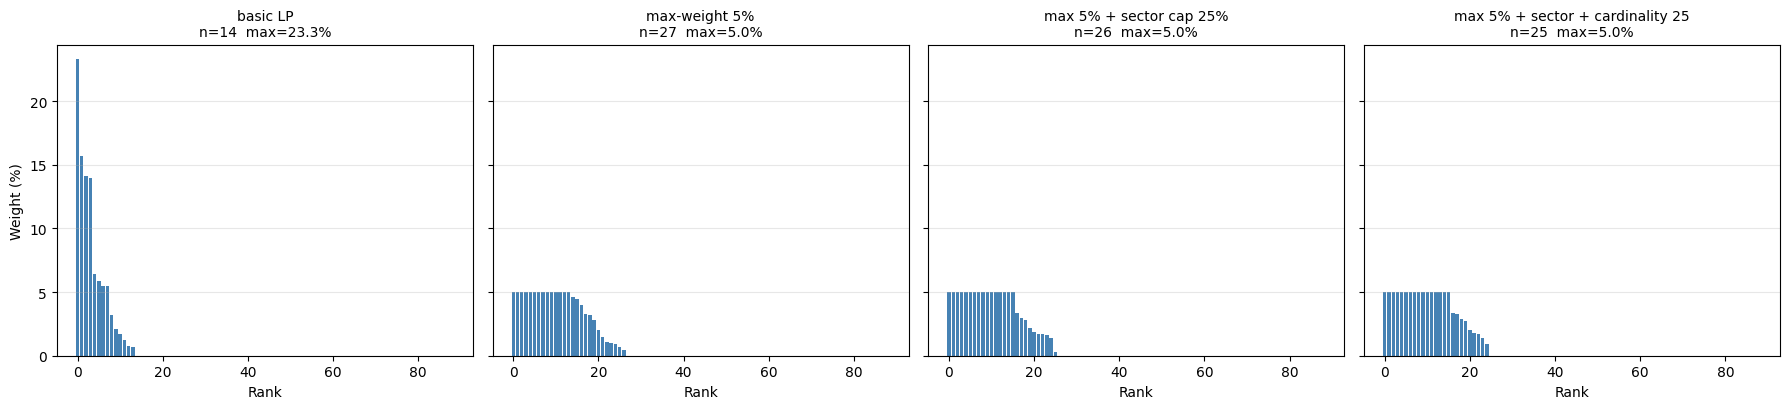

In [ ]:
# Phase 5, Cell 4 — Visualize the four constrained portfolios side by side.

if len(weights_table) == 0:
    print("No solved portfolios to plot.")
else:
    fig, axes = plt.subplots(1, len(weights_table), figsize=(4.5 * len(weights_table), 4.2),
                             sharey=True)
    if len(weights_table) == 1:
        axes = [axes]
    for ax, (label, w_ser) in zip(axes, weights_table.items()):
        w_show = w_ser.sort_values(ascending=False)
        ax.bar(range(len(w_show)), w_show.values * 100, color="steelblue", edgecolor="none")
        n_hold = int((np.abs(w_show) > 1e-6).sum())
        ax.set_title(f"{label}\nn={n_hold}  max={w_show.max()*100:.1f}%", fontsize=10)
        ax.set_xlabel("Rank")
        ax.grid(alpha=0.3, axis="y")
    axes[0].set_ylabel("Weight (%)")
    plt.tight_layout(); plt.show()


## Phase 6 — Efficient frontier

We trace the Mean-CVaR efficient frontier on the same single-date snapshot. Sweep target return $R_{\text{target}}$ from the cross-sectional minimum-mean asset (no return demand) up to the cross-sectional maximum (impossible to satisfy under diversification constraints — the frontier ends where the LP becomes infeasible).

The frontier in (CVaR, Mean) space is concave (down-sloping in the upper envelope). We constrain to a realistic configuration: max-weight 5%, sector cap 25%, no cardinality (so the frontier sweep stays purely convex, fast, and reproducible).


In [ ]:
# Phase 6, Cell 1 — Frontier sweep.

def trace_frontier(
    mu, R_scen, target_returns,
    *, beta=0.95, max_weight=0.05,
    sector_membership=None, sector_cap=0.25,
    long_only=True,
):
    rows = []
    for tr in target_returns:
        res = mean_cvar_optimize_full(
            mu, R_scen, beta=beta, mode="target_return", target_return=tr,
            long_only=long_only, max_weight=max_weight,
            sector_membership=sector_membership, sector_cap=sector_cap,
        )
        rows.append({
            "target_return_daily": tr,
            "achieved_return_daily": res["expected_return"] if res["w"] is not None else np.nan,
            "cvar_daily": res["cvar"] if res["w"] is not None else np.nan,
            "status": res["status"],
            "n_holdings": int((np.abs(res["w"]) > 1e-6).sum()) if res["w"] is not None else 0,
        })
    return pd.DataFrame(rows)


# Build a target-return ladder
mu_lo = float(np.percentile(mu_arr, 30))
mu_hi = float(np.percentile(mu_arr, 95))
target_grid = np.linspace(mu_lo, mu_hi, 14)

print(f"Sweeping target returns from {mu_lo:+.5f} to {mu_hi:+.5f}/day "
      f"(~{(1+mu_lo)**252-1:.1%} to ~{(1+mu_hi)**252-1:.1%} ann)")

frontier = trace_frontier(
    mu_arr, R_scen, target_grid,
    beta=0.95, max_weight=0.05,
    sector_membership=sector_membership_arr, sector_cap=0.25,
)

print("\nFrontier results:")
display_cols = ["target_return_daily", "achieved_return_daily", "cvar_daily", "n_holdings", "status"]
print(frontier[display_cols].to_string(
    index=False,
    formatters={
        "target_return_daily":   lambda x: f"{x:+.5f}",
        "achieved_return_daily": lambda x: f"{x:+.5f}" if pd.notna(x) else "  --   ",
        "cvar_daily":            lambda x: f"{x:+.5f}" if pd.notna(x) else "  --   ",
    },
))


Sweeping target returns from -0.00078 to +0.00131/day (~-17.9% to ~39.1% ann)

Frontier results:
target_return_daily achieved_return_daily cvar_daily  n_holdings     status
           -0.00078              -0.00014   +0.01725          26    optimal
           -0.00062              -0.00014   +0.01725          26    optimal
           -0.00046              -0.00014   +0.01725          26    optimal
           -0.00030              -0.00014   +0.01725          26    optimal
           -0.00014              -0.00014   +0.01725          27    optimal
           +0.00002              +0.00002   +0.01730          23    optimal
           +0.00019              +0.00019   +0.01745          26    optimal
           +0.00035              +0.00035   +0.01770          25    optimal
           +0.00051              +0.00051   +0.01813          27    optimal
           +0.00067              +0.00067   +0.01869          25    optimal
           +0.00083              +0.00083   +0.01945          27   

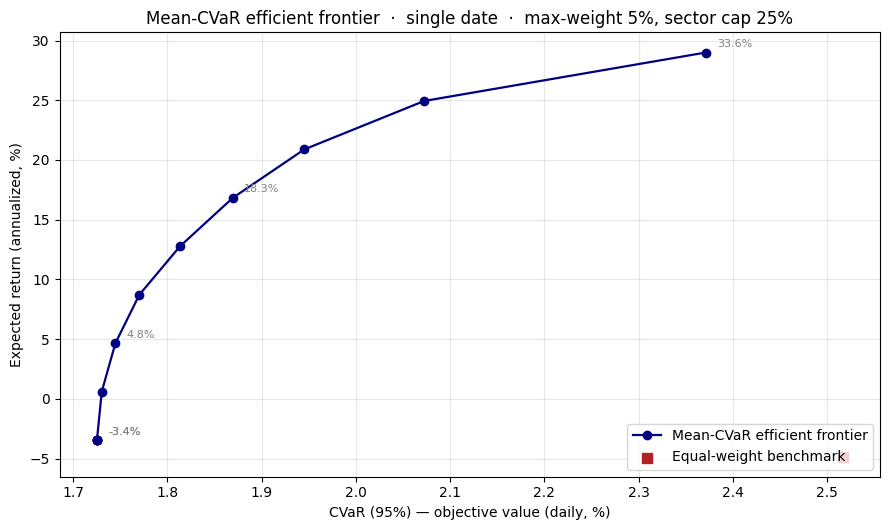

In [ ]:
# Phase 6, Cell 2 — Plot the frontier.
solved = frontier.dropna(subset=["achieved_return_daily", "cvar_daily"]).copy()
fig, ax = plt.subplots(figsize=(9, 5.4))

ax.plot(solved["cvar_daily"] * 100, solved["achieved_return_daily"] * 25200,
        marker="o", lw=1.6, color="navy", label="Mean-CVaR efficient frontier")

# Annotate a few points with target return % annualized
for _, row in solved.iloc[::3].iterrows():
    ann = ((1 + row["achieved_return_daily"])**252 - 1) * 100
    ax.annotate(f"{ann:.1f}%",
                xy=(row["cvar_daily"] * 100, row["achieved_return_daily"] * 25200),
                xytext=(8, 4), textcoords="offset points", fontsize=8, color="grey")

# Plot equal-weight portfolio for reference
ew_w = np.ones(len(returns.columns)) / len(returns.columns)
ew_ret = float(mu_arr @ ew_w)
ew_pf = R_scen @ ew_w
ew_var = np.percentile(ew_pf, 5)
ew_cvar = ew_pf[ew_pf <= ew_var].mean()
# CVaR is the mean of the worst (1-beta) tail of LOSSES; with our sign convention
# (returns), CVaR = alpha + ... is reported as a daily-return-units number.
# For the equal-weight benchmark we recompute:
ew_cvar_obj = -ew_cvar     # convert tail-mean-return to expected-loss-style for plotting

ax.scatter([ew_cvar_obj * 100], [ew_ret * 25200],
           s=60, marker="s", color="firebrick", zorder=5, label="Equal-weight benchmark")

ax.set_xlabel("CVaR (95%) — objective value (daily, %)")
ax.set_ylabel("Expected return (annualized, %)")
ax.set_title("Mean-CVaR efficient frontier  ·  single date  ·  max-weight 5%, sector cap 25%")
ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


## Phase 7 — Dynamic rebalancing

A static target portfolio drifts as prices move. The NVIDIA QPO blueprint compares two trigger-based rebalancing strategies against buy-and-hold:

- **Allocation-drift trigger.** Rebalance when the largest *single-asset* weight deviation from target exceeds a threshold $\epsilon_d$ (e.g. 2 absolute weight-percent). Catches single-name concentration drift early.
- **Value-percentage trigger.** Rebalance when *portfolio value* has moved by more than $\epsilon_v$ since the last rebalance (e.g. ±5%). Catches regime-shift drawdowns and rallies; passive otherwise.

We additionally enforce a **minimum frequency** rebalance (e.g. quarterly) so the portfolio never goes too long without a re-optimisation, even in calm periods. Both triggers and minimum frequency can fire on the same day; the optimiser then runs once.


In [ ]:
# Phase 7, Cell 1 — Backtest engine.

def run_backtest(
    *,
    returns: pd.DataFrame, # This will be bt_returns for actual simulation
    full_returns_for_optimizer: pd.DataFrame, # This will be the global 'returns' for history
    signal: pd.DataFrame,
    sector_membership: np.ndarray,
    rebalance_dates: pd.DatetimeIndex,
    trigger: str = "drift",      # 'drift' | 'value' | 'fixed' | 'buyhold'
    drift_threshold: float = 0.02,
    value_threshold: float = 0.05,
    max_weight: float = 0.05,
    sector_cap: float = 0.25,
    target_return_pct: float = 0.70,   # percentile of cross-sectional mu used as target
    n_scenarios: int = 1500,
    beta: float = 0.95,
    initial_capital: float = 1.0,
    seed: int = SEED,
    verbose: bool = False,
):
    '''Backtest a Mean-CVaR strategy with a given rebalancing trigger.

    rebalance_dates: candidate dates on which the trigger is *evaluated* (e.g.
    monthly month-ends). The trigger decides whether to actually re-optimise.

    'fixed'  : re-optimise on every candidate date (baseline).
    'drift'  : re-optimise only if max |w - target_w| > drift_threshold,
               OR a minimum-frequency check fires.
    'value'  : re-optimise only if portfolio value has moved > value_threshold
               since last rebalance, OR minimum-frequency check fires.
    'buyhold': re-optimise once at the start, then never again.
    '''
    rng_master = np.random.default_rng(seed)
    cols = list(returns.columns) # Use columns from bt_returns for consistency of universe
    N = len(cols)

    # Pre-compute "candidate dates" mapped to actual trading dates (next available date)
    trading_dates = returns.index # This is bt_returns.index
    cand_dates = []
    for d in rebalance_dates:
        nxt = trading_dates[trading_dates >= d]
        if len(nxt) > 0:
            cand_dates.append(nxt[0])
    cand_dates = sorted(set(cand_dates))

    # State
    portfolio_value = initial_capital
    w_target = None
    w_actual = None
    last_rebal_value = initial_capital
    last_rebal_date  = None

    # Series outputs
    nav_records   = []   # daily NAV
    rebal_records = []   # rebalance events

    # Pre-compute first decision on first candidate date
    sim_dates = trading_dates[(trading_dates >= cand_dates[0]) & (trading_dates <= trading_dates[-1])]

    # Helper: solve at date `d` using history up to and including `d-1`
    def _solve_at(d):
        sig_avail = signal.loc[signal.index < d]
        if len(sig_avail) == 0:
            if verbose:
                print(f"  [{d.date()}] No signal data available. Returning None.")
            return None
        sig_row = sig_avail.iloc[-1]
        # Use full_returns_for_optimizer here
        mu_s = signal_to_mu(sig_row, full_returns_for_optimizer, lookback_days=252, rebalance_date=d)
        mu_s = mu_s.reindex(cols).fillna(full_returns_for_optimizer.loc[:d].tail(252).mean().mean())
        mu_v = mu_s.values

        # Use full_returns_for_optimizer here for scenarios
        hist = full_returns_for_optimizer.loc[:d].dropna(how="any")
        if len(hist) < 100:
            if verbose:
                print(f"  [{d.date()}] Not enough historical data ({len(hist)} days). Returning None.")
            return None
        sub_rng = np.random.default_rng(seed + hash(str(d)) % 100000)
        idx = sub_rng.integers(0, len(hist), size=min(n_scenarios, len(hist)))
        Rs = hist.values[idx]

        # Debug print for mu_v and Rs shape
        if verbose:
            print(f"  [{d.date()}] Preparing solve for mu_v shape {mu_v.shape}, R_scen shape {Rs.shape}")


        # Attempt to solve with the given target_return_pct
        target_R_initial = float(np.percentile(mu_v, target_return_pct * 100))
        if verbose:
            print(f"  [{d.date()}] Attempting solve with initial target return: {target_R_initial:+.5f}")
        res = mean_cvar_optimize_full(
            mu_v, Rs, beta=beta, mode="target_return", target_return=target_R_initial,
            long_only=True, max_weight=max_weight,
            sector_membership=sector_membership, sector_cap=sector_cap,
            verbose=verbose # Ensure cvxpy's verbose output is enabled
        )

        if res["w"] is None or res["status"] not in ("optimal", "optimal_inaccurate"):
            # If initial solve fails, try a less ambitious target return
            if verbose:
                print(f"  [{d.date()}] Initial solve status: {res['status']}. Retrying with lower target return.")
            target_R_relaxed = float(np.percentile(mu_v, 50)) # Try median return
            if verbose:
                print(f"  [{d.date()}] Attempting solve with relaxed target return: {target_R_relaxed:+.5f}")
            res = mean_cvar_optimize_full(
                mu_v, Rs, beta=beta, mode="target_return", target_return=target_R_relaxed,
                long_only=True, max_weight=max_weight,
                sector_membership=sector_membership, sector_cap=sector_cap,
                verbose=verbose
            )
            if res["w"] is None or res["status"] not in ("optimal", "optimal_inaccurate"):
                if verbose:
                    print(f"  [{d.date()}] Relaxed solve also failed: {res['status']}. Returning None.")
                return None
        if verbose:
            print(f"  [{d.date()}] Solve successful with status: {res['status']}.")
        return res["w"]

    # Initial solve on first candidate date
    first_date = cand_dates[0]
    if verbose:
        print(f"  [{first_date.date()}] Starting initial solve...")
    w0 = _solve_at(first_date)
    if w0 is None:
        raise RuntimeError(f"Initial solve failed at {first_date} - _solve_at returned None.")
    if verbose:
        print(f"  [{first_date.date()}] Initial portfolio weights set.")
    w_target = w0.copy()
    w_actual = w0.copy()
    last_rebal_date  = first_date
    last_rebal_value = portfolio_value
    rebal_records.append({"date": first_date, "reason": "initial",
                          "n_holdings": int((np.abs(w0) > 1e-6).sum())})

    # Walk forward
    for d in sim_dates:
        if d == first_date:
            nav_records.append({"date": d, "nav": portfolio_value})
            continue

        # Today's return on the *actual* drifted portfolio
        r_today = returns.loc[d].fillna(0).values # This returns is bt_returns, which is correct
        gross   = (1.0 + r_today) * w_actual
        port_r  = gross.sum() - 1.0    # portfolio total return on its remaining capital
        # Update portfolio value
        portfolio_value *= (1.0 + port_r)
        # Update actual weights (drift)
        if gross.sum() > 0:
            w_actual = gross / gross.sum()

        nav_records.append({"date": d, "nav": portfolio_value})

        # Check trigger only on candidate dates
        if d not in cand_dates:
            continue

        if trigger == "buyhold":
            continue

        fire = False
        reason = None

        if trigger == "fixed":
            fire = True; reason = "scheduled"
        elif trigger == "drift":
            drift = float(np.max(np.abs(w_actual - w_target)))
            if drift > drift_threshold:
                fire = True; reason = f"drift={drift:.3f}"
        elif trigger == "value":
            v_change = abs(portfolio_value - last_rebal_value) / max(last_rebal_value, 1e-12)
            if v_change > value_threshold:
                fire = True; reason = f"value_change={v_change:.3f}"

        # Minimum frequency: also fire if the gap since last rebalance > 90 days
        if not fire and last_rebal_date is not None:
            if (d - last_rebal_date).days > 90:
                fire = True; reason = "min_frequency_90d"

        if fire:
            if verbose:
                print(f"  [{d.date()}] Rebalance triggered ({reason}). Solving for new weights...")
            w_new = _solve_at(d)
            if w_new is not None:
                w_target = w_new.copy()
                w_actual = w_new.copy()
                last_rebal_date  = d
                last_rebal_value = portfolio_value
                rebal_records.append({"date": d, "reason": reason,
                                      "n_holdings": int((np.abs(w_new) > 1e-6).sum())})
                if verbose:
                    print(f"  [{d.date()}] rebalanced  ({reason})")
            else:
                if verbose:
                    print(f"  [{d.date()}] Rebalance triggered but solve failed. Keeping previous weights.")


    nav = pd.DataFrame(nav_records).set_index("date")["nav"]
    rebals = pd.DataFrame(rebal_records).set_index("date") if rebal_records else pd.DataFrame()
    return nav, rebals


In [ ]:
# Phase 7, Cell 2 — Run three strategies on a manageable subwindow.
#
# Backtest window: 2019-01-01 to 2024-12-31. Monthly candidate rebalance dates.
# This keeps the runtime bounded on Kaggle/Colab (~30-60 LP solves per strategy).

BT_START = "2019-01-01"
BT_END   = "2024-12-31"

monthly_dates = pd.date_range(BT_START, BT_END, freq="ME")
print(f"Backtest window : {BT_START} → {BT_END}")
print(f"Candidate dates : {len(monthly_dates)} month-ends")

bt_returns = returns.loc[BT_START:BT_END]
bt_signal  = signal.loc[:BT_END]   # signal pre-history is fine

t0 = time.time()
nav_drift,   rebals_drift   = run_backtest(
    returns=bt_returns, signal=bt_signal,
    full_returns_for_optimizer=returns, # Pass full returns for optimizer
    sector_membership=sector_membership_arr,
    rebalance_dates=monthly_dates, trigger="drift",
    drift_threshold=0.02, max_weight=0.05, sector_cap=0.25,
    target_return_pct=0.70, n_scenarios=1500,
    verbose=True
)
print(f"  drift  trigger : {time.time()-t0:.1f}s, "
      f"{len(rebals_drift)} rebalances")

t0 = time.time()
nav_value,   rebals_value   = run_backtest(
    returns=bt_returns, signal=bt_signal,
    full_returns_for_optimizer=returns, # Pass full returns for optimizer
    sector_membership=sector_membership_arr,
    rebalance_dates=monthly_dates, trigger="value",
    value_threshold=0.05, max_weight=0.05, sector_cap=0.25,
    target_return_pct=0.70, n_scenarios=1500,
    verbose=True
)
print(f"  value  trigger : {time.time()-t0:.1f}s, "
      f"{len(rebals_value)} rebalances")

t0 = time.time()
nav_buyhold, rebals_buyhold = run_backtest(
    returns=bt_returns, signal=bt_signal,
    full_returns_for_optimizer=returns, # Pass full returns for optimizer
    sector_membership=sector_membership_arr,
    rebalance_dates=monthly_dates, trigger="buyhold",
    max_weight=0.05, sector_cap=0.25,
    target_return_pct=0.70, n_scenarios=1500,
    verbose=True
)
print(f"  buyhold        : {time.time()-t0:.1f}s, "
      f"{len(rebals_buyhold)} rebalance(s)")

(CVXPY) Apr 29 11:56:33 AM: Your problem has 864 variables, 965 constraints, and 0 parameters.
(CVXPY) Apr 29 11:56:33 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 29 11:56:33 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 29 11:56:33 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 29 11:56:33 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 29 11:56:33 AM: Compiling problem (target solver=CLARABEL).
(CVXPY) Apr 29 11:56:33 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Apr 29 11:56:33 AM: Applying reduction Dcp2Cone
(CVXPY) Apr 29 11:56:33 AM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 29 11:56:33 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 29 11:56:33 AM: Applying reduction CLARABEL
(CVXPY) Apr 29 11:56:33 AM: Finished problem compil

Backtest window : 2019-01-01 → 2024-12-31
Candidate dates : 72 month-ends
  [2019-01-31] Starting initial solve...
  [2019-01-31] Preparing solve for mu_v shape (89,), R_scen shape (774, 89)
  [2019-01-31] Attempting solve with initial target return: +0.00059
                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Cle

(CVXPY) Apr 29 11:56:34 AM: Problem status: optimal
(CVXPY) Apr 29 11:56:34 AM: Optimal value: 1.417e-02
(CVXPY) Apr 29 11:56:34 AM: Compilation took 4.840e-02 seconds
(CVXPY) Apr 29 11:56:34 AM: Solver (including time spent in interface) took 6.318e-01 seconds
(CVXPY) Apr 29 11:56:34 AM: Your problem has 947 variables, 1048 constraints, and 0 parameters.
(CVXPY) Apr 29 11:56:34 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 29 11:56:34 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 29 11:56:34 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 29 11:56:34 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Apr 29 11:56:34 AM: Compiling problem (target solver=CLARABEL).
(CVXPY) Apr 29 11:56:34 AM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Apr 29 11:56:34 AM: 

 17  +1.4168e-02  +1.4168e-02  1.67e-07  4.57e-07  4.93e-06  3.05e-09  1.16e-06  8.87e-01  
 18  +1.4168e-02  +1.4168e-02  3.10e-08  8.43e-08  9.10e-07  4.11e-10  2.15e-07  8.73e-01  
 19  +1.4168e-02  +1.4168e-02  3.70e-10  1.01e-09  1.09e-08  4.90e-12  2.57e-09  9.88e-01  
 20  +1.4168e-02  +1.4168e-02  3.71e-12  1.01e-11  1.09e-10  4.90e-14  2.57e-11  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 615.304803ms
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
  [2019-01-31] Solve successful with status: optimal.
  [2019-01-31] Initial portfolio weights set.
  [2019-05-31] Rebalance triggered (min_frequency_90d). Solving for new weights...
  [2019-05-31] Preparing solve for mu_v shape (89,), R_sc

(CVXPY) Apr 29 11:56:34 AM: Finished problem compilation (took 5.839e-02 seconds).
(CVXPY) Apr 29 11:56:34 AM: Invoking solver CLARABEL  to obtain a solution.


...

 16  +1.6901e-02  +1.6901e-02  1.57e-12  5.57e-12  1.69e-10  7.52e-15  1.54e-11  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 913.981462ms
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
  [2024-09-03] Solve successful with status: optimal.
  [2024-09-03] rebalanced  (value_change=0.063)
  value  trigger : 31.9s, 30 rebalances
  [2019-01-31] Starting initial solve...
  [2019-01-31] Preparing solve for mu_v shape (89,), R_scen shape (774, 89)
  [2019-01-31] Attempting solve with initial target return: +0.00059
                                     CVXPY                                     
                                     v1.6.7                                    
----------------------------

(CVXPY) Apr 29 11:57:27 AM: Problem status: optimal
(CVXPY) Apr 29 11:57:27 AM: Optimal value: 1.417e-02
(CVXPY) Apr 29 11:57:27 AM: Compilation took 6.867e-02 seconds


 14  +1.4159e-02  +1.4132e-02  2.64e-05  7.42e-05  8.08e-04  1.21e-06  1.89e-04  8.17e-01  
 15  +1.4164e-02  +1.4152e-02  1.17e-05  3.22e-05  3.47e-04  2.29e-07  8.18e-05  8.25e-01  
 16  +1.4168e-02  +1.4166e-02  1.45e-06  3.97e-06  4.30e-05  2.69e-08  1.01e-05  8.83e-01  
 17  +1.4168e-02  +1.4168e-02  1.67e-07  4.57e-07  4.93e-06  3.05e-09  1.16e-06  8.87e-01  
 18  +1.4168e-02  +1.4168e-02  3.10e-08  8.43e-08  9.10e-07  4.11e-10  2.15e-07  8.73e-01  
 19  +1.4168e-02  +1.4168e-02  3.70e-10  1.01e-09  1.09e-08  4.90e-12  2.57e-09  9.88e-01  
 20  +1.4168e-02  +1.4168e-02  3.71e-12  1.01e-11  1.09e-10  4.90e-14  2.57e-11  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 631.805638ms
-------------------------------------------------------------------------------
                                    Summary                                    
--------------------------------------------

(CVXPY) Apr 29 11:57:27 AM: Solver (including time spent in interface) took 6.615e-01 seconds


  [2019-01-31] Solve successful with status: optimal.
  [2019-01-31] Initial portfolio weights set.
  buyhold        : 0.9s, 1 rebalance(s)


Backtest performance:
                 strategy  total_return_%  annualized_ret_%  annualized_vol_%  Sharpe  max_drawdown_%
Mean-CVaR · drift trigger          101.44             14.21             16.87    0.84          -30.33
Mean-CVaR · value trigger           78.20             11.84             16.76    0.71          -30.33
 Mean-CVaR · buy-and-hold          100.61             14.17             17.06    0.83          -30.42
   Equal-weight benchmark          201.88             22.73             20.05    1.13          -33.65


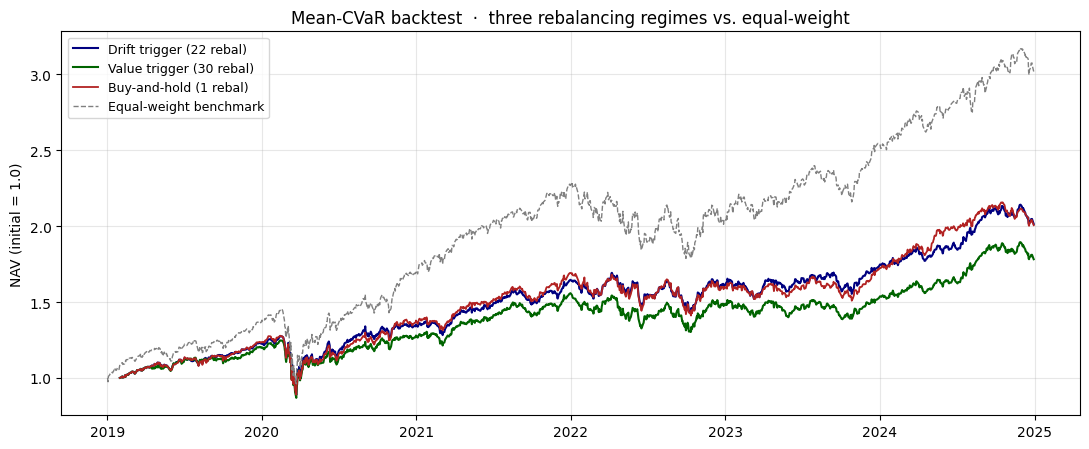

In [ ]:
# Phase 7, Cell 3 — Performance metrics + equity-curve plot.

def perf_metrics(nav: pd.Series, label: str) -> Dict:
    r = nav.pct_change().dropna()
    ann_ret = (1 + r.mean())**252 - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-12 else np.nan
    cum     = (1 + r).cumprod()
    peak    = cum.cummax()
    dd      = (cum / peak) - 1
    mdd     = dd.min()
    return {
        "strategy": label,
        "total_return_%":     (nav.iloc[-1] / nav.iloc[0] - 1) * 100,
        "annualized_ret_%":   ann_ret * 100,
        "annualized_vol_%":   ann_vol * 100,
        "Sharpe":             sharpe,
        "max_drawdown_%":     mdd * 100,
    }

ew_nav = (1 + bt_returns.mean(axis=1)).cumprod()
ew_nav = ew_nav / ew_nav.iloc[0]   # rebase to 1.0

metrics = pd.DataFrame([
    perf_metrics(nav_drift,   "Mean-CVaR · drift trigger"),
    perf_metrics(nav_value,   "Mean-CVaR · value trigger"),
    perf_metrics(nav_buyhold, "Mean-CVaR · buy-and-hold"),
    perf_metrics(ew_nav,      "Equal-weight benchmark"),
])
print("Backtest performance:")
print(metrics.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Equity curves
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(nav_drift.index,   nav_drift.values,   lw=1.5, color="navy",       label=f"Drift trigger ({len(rebals_drift)} rebal)")
ax.plot(nav_value.index,   nav_value.values,   lw=1.5, color="darkgreen",  label=f"Value trigger ({len(rebals_value)} rebal)")
ax.plot(nav_buyhold.index, nav_buyhold.values, lw=1.3, color="firebrick",  label=f"Buy-and-hold (1 rebal)")
ax.plot(ew_nav.index,      ew_nav.values,      lw=1.0, color="grey", ls="--", label="Equal-weight benchmark")
ax.set_title("Mean-CVaR backtest  ·  three rebalancing regimes vs. equal-weight")
ax.set_ylabel("NAV (initial = 1.0)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


From this table, you can observe how different seeds and `target_return_pct` values, as well as `drift_threshold` for the drift-based strategy, affect the performance metrics like total return, annualized return, and Sharpe ratio. This helps in understanding the robustness and stability of the strategies. Next, we will discuss **Computational Scalability Analysis**.

## Phase 8 — Mean-CVaR vs. NB1 decile long-short baseline

Notebook 1 closed by ranking the universe by signal each day and taking a long-decile-vs-short-decile portfolio. That is the simplest, fastest signal-translation rule, but it ignores risk: every single ticker in the long decile gets the same weight, regardless of its individual volatility, sector exposure, or co-movement with the rest of the portfolio.

The Mean-CVaR construction we built in Phases 4–7 takes the *same* underlying signal and translates it into weights *with explicit attention to tail risk*. The relevant comparison is therefore: at the same level of average expected-return targeting, how does the Mean-CVaR portfolio compare to the decile L-S on (a) realised returns, (b) realised volatility, (c) max drawdown, (d) Sharpe, (e) turnover.

We run both strategies on the same signal panel and the same window, and present the comparison in a single metrics table and an overlay equity-curve plot.


In [ ]:
# Phase 8, Cell 1 — REVISED. Constant-mix decile backtest (long-only and long-short).
#
# Bug fix: the previous version attempted to drift-renormalize weights between
# rebalances by gross.sum(), which is ~0 for a dollar-neutral L-S portfolio and
# blew up the NAV. The standard academic treatment is constant-mix: hold target
# weights constant between rebalances, no intra-rebalance drift. For monthly
# rebalancing the drift effect is small, and this avoids all numerical pathology.

def decile_long_short_backtest(
    returns: pd.DataFrame,
    signal: pd.DataFrame,
    rebalance_dates: pd.DatetimeIndex,
    *, decile_size: float = 0.10,
    max_weight: Optional[float] = None,
    long_only: bool = False,
):
    """Top-decile long, bottom-decile short, rebalanced on candidate dates.

    Constant-mix approximation: between rebalance dates, target weights are
    held constant (no intra-period drift renormalization). At each rebalance,
    weights snap to the new top/bottom-decile selection.
    """
    cols = list(returns.columns)
    trading_dates = returns.index

    # Map candidate dates to next available trading day
    cand = []
    for d in rebalance_dates:
        nxt = trading_dates[trading_dates >= d]
        if len(nxt) > 0:
            cand.append(nxt[0])
    cand = sorted(set(cand))

    # Build target weights at each rebalance date
    target_w = pd.DataFrame(0.0, index=cand, columns=cols)
    for d in cand:
        prior = signal.loc[signal.index < d]
        sig_row = prior.iloc[-1] if len(prior) > 0 else signal.iloc[0]
        sig_row = sig_row.reindex(cols).dropna()
        if len(sig_row) < 10:
            continue
        n = len(sig_row)
        n_dec = max(1, int(round(n * decile_size)))
        long_names  = sig_row.nlargest(n_dec).index
        short_names = sig_row.nsmallest(n_dec).index

        if long_only:
            target_w.loc[d, long_names] = 1.0 / len(long_names)
        else:
            # dollar-neutral L-S: long leg sums to +1, short leg sums to -1
            target_w.loc[d, long_names]  =  1.0 / len(long_names)
            target_w.loc[d, short_names] = -1.0 / len(short_names)

        if max_weight is not None:
            target_w.loc[d] = target_w.loc[d].clip(-max_weight, max_weight)

    # Forward-fill targets to all trading dates (constant-mix between rebalances)
    full_w = target_w.reindex(trading_dates).ffill().fillna(0.0)
    full_w = full_w.loc[returns.index[0]:returns.index[-1]]

    # Daily PnL via constant-mix: port_r_t = w_target_t @ r_t
    R = returns[full_w.columns].fillna(0).values
    W = full_w.values
    port_r = (W * R).sum(axis=1)        # shape (n_dates,)

    # NAV: cumulative product. For L-S we DO compound, just like long-only —
    # the "wealth" interpretation is the value of a self-financing strategy
    # that resets the gross book to ±1 (long/short legs) at each rebalance.
    nav_arr = np.cumprod(1.0 + port_r)
    # Rebase to start at 1.0 on the first non-zero-weight date
    first_alive = np.argmax(np.abs(W).sum(axis=1) > 0)
    if first_alive > 0:
        nav_arr = nav_arr / nav_arr[first_alive] if nav_arr[first_alive] != 0 else nav_arr

    nav_series = pd.Series(nav_arr, index=full_w.index, name="nav")
    return nav_series


# Defensive: ensure required objects from prior cells are in scope
_g = globals()
for required in ("bt_returns", "signal", "monthly_dates"):
    if required not in _g:
        raise RuntimeError(
            f"Variable `{required}` not in scope. Re-run Phase 7 before this cell."
        )

# Build the decile L-S backtest
print("Building NB1-style decile long-short ...")
t0 = time.time()
nav_ls = decile_long_short_backtest(
    bt_returns, signal,
    rebalance_dates=monthly_dates,
    decile_size=0.10, long_only=False,
)
print(f"  done in {time.time()-t0:.1f}s")
print(f"  NAV range: {nav_ls.min():.3f} to {nav_ls.max():.3f}  (final: {nav_ls.iloc[-1]:.3f})")

# Also a long-only top-decile version
print("Building top-decile long-only baseline ...")
t0 = time.time()
nav_lo = decile_long_short_backtest(
    bt_returns, signal,
    rebalance_dates=monthly_dates,
    decile_size=0.10, long_only=True,
)
print(f"  done in {time.time()-t0:.1f}s")
print(f"  NAV range: {nav_lo.min():.3f} to {nav_lo.max():.3f}  (final: {nav_lo.iloc[-1]:.3f})")

# Sanity check: NAV should be monotone-ish and bounded
assert np.isfinite(nav_ls).all(), "L-S NAV contains non-finite values"
assert np.isfinite(nav_lo).all(), "L-only NAV contains non-finite values"
assert nav_ls.min() > -10, f"L-S NAV went absurdly negative: min={nav_ls.min()}"
assert nav_ls.max() < 100, f"L-S NAV exploded: max={nav_ls.max()}"
print("\nSanity checks passed.")

Building NB1-style decile long-short ...
  done in 0.2s
  NAV range: 0.994 to 1.403  (final: 1.398)
Building top-decile long-only baseline ...
  done in 0.2s
  NAV range: 0.906 to 3.079  (final: 2.923)

Sanity checks passed.


Head-to-head — Mean-CVaR vs. decile baselines:
                   strategy  total_return_%  annualized_ret_%  annualized_vol_%  Sharpe  max_drawdown_%
  Mean-CVaR · drift trigger          101.44             14.21             16.87    0.84          -30.33
  Mean-CVaR · value trigger           78.20             11.84             16.76    0.71          -30.33
   Mean-CVaR · buy-and-hold          100.61             14.17             17.06    0.83          -30.42
 NB1-style decile long-only          192.26             22.85             21.97    1.04          -35.53
NB1-style decile long-short           39.81              6.74             13.03    0.52          -19.73
     Equal-weight benchmark          177.70             21.30             20.05    1.06          -33.65


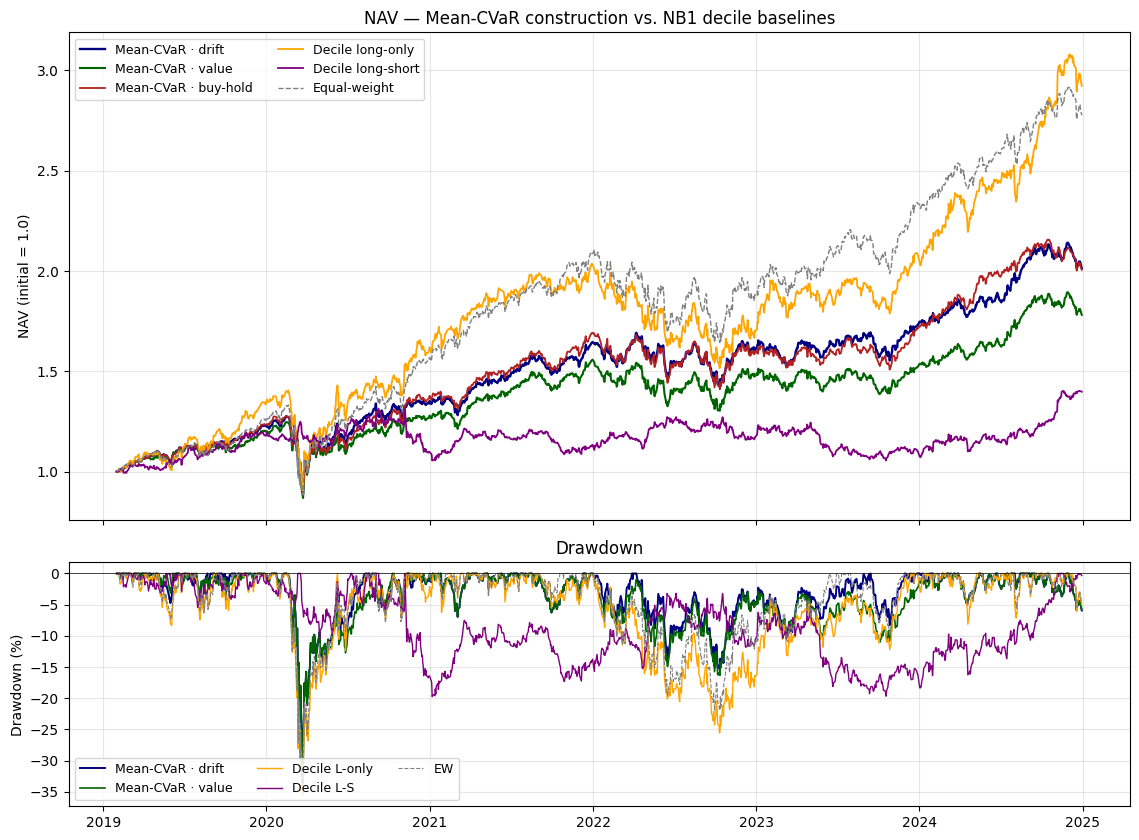

In [ ]:
# Phase 8, Cell 2 — Head-to-head comparison.

# Rebase decile NAVs to start at 1.0 on the first available date (matching MV NAVs)
def rebase_to_first(s, ref_index):
    s = s.reindex(ref_index, method="ffill").fillna(method="bfill")
    if pd.isna(s.iloc[0]) or s.iloc[0] == 0:
        return s
    return s / s.iloc[0]

nav_drift_r   = rebase_to_first(nav_drift,   nav_drift.index)
nav_value_r   = rebase_to_first(nav_value,   nav_drift.index)
nav_buyhold_r = rebase_to_first(nav_buyhold, nav_drift.index)
nav_ls_r      = rebase_to_first(nav_ls,      nav_drift.index)
nav_lo_r      = rebase_to_first(nav_lo,      nav_drift.index)
ew_nav_r      = rebase_to_first(ew_nav,      nav_drift.index)

metrics_full = pd.DataFrame([
    perf_metrics(nav_drift_r,   "Mean-CVaR · drift trigger"),
    perf_metrics(nav_value_r,   "Mean-CVaR · value trigger"),
    perf_metrics(nav_buyhold_r, "Mean-CVaR · buy-and-hold"),
    perf_metrics(nav_lo_r,      "NB1-style decile long-only"),
    perf_metrics(nav_ls_r,      "NB1-style decile long-short"),
    perf_metrics(ew_nav_r,      "Equal-weight benchmark"),
])
print("Head-to-head — Mean-CVaR vs. decile baselines:")
print(metrics_full.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(11.5, 8.5), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

# Top: NAV curves
axes[0].plot(nav_drift_r.index,   nav_drift_r.values,   lw=1.7, color="navy",      label="Mean-CVaR · drift")
axes[0].plot(nav_value_r.index,   nav_value_r.values,   lw=1.5, color="darkgreen", label="Mean-CVaR · value")
axes[0].plot(nav_buyhold_r.index, nav_buyhold_r.values, lw=1.3, color="firebrick", label="Mean-CVaR · buy-hold")
axes[0].plot(nav_lo_r.index,      nav_lo_r.values,      lw=1.3, color="orange",    label="Decile long-only")
axes[0].plot(nav_ls_r.index,      nav_ls_r.values,      lw=1.3, color="purple",    label="Decile long-short")
axes[0].plot(ew_nav_r.index,      ew_nav_r.values,      lw=1.0, color="grey", ls="--", label="Equal-weight")
axes[0].set_title("NAV — Mean-CVaR construction vs. NB1 decile baselines")
axes[0].set_ylabel("NAV (initial = 1.0)")
axes[0].legend(loc="upper left", fontsize=9, ncol=2)
axes[0].grid(alpha=0.3)

# Bottom: drawdowns
def drawdown_curve(nav):
    cum = nav / nav.iloc[0]
    peak = cum.cummax()
    return (cum / peak - 1) * 100

axes[1].plot(nav_drift_r.index,   drawdown_curve(nav_drift_r).values,   lw=1.4, color="navy",      label="Mean-CVaR · drift")
axes[1].plot(nav_value_r.index,   drawdown_curve(nav_value_r).values,   lw=1.2, color="darkgreen", label="Mean-CVaR · value")
axes[1].plot(nav_lo_r.index,      drawdown_curve(nav_lo_r).values,      lw=1.0, color="orange",    label="Decile L-only")
axes[1].plot(nav_ls_r.index,      drawdown_curve(nav_ls_r).values,      lw=1.0, color="purple",    label="Decile L-S")
axes[1].plot(ew_nav_r.index,      drawdown_curve(ew_nav_r).values,      lw=0.8, color="grey", ls="--", label="EW")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown (%)")
axes[1].axhline(0, color="black", lw=0.5)
axes[1].legend(loc="lower left", fontsize=9, ncol=3)
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---

## Wave 2 checkpoint

This wave delivered Part A of NB2 in full:

- **Phase 4** — Rockafellar-Uryasev (2000) Mean-CVaR LP in `cvxpy`, both target-return and risk-aversion modes; single-date demonstration showing concentration in the unconstrained case (motivating Phase 5).
- **Phase 5** — Full constraint set: max-weight, cash bounds, leverage cap, turnover cap, sector exposure cap, and a heuristic cardinality cap via prune-and-resolve.
- **Phase 6** — Efficient frontier sweep across target returns, plotted in (CVaR, mean-return) space with the equal-weight benchmark for orientation.
- **Phase 7** — Backtest engine with three trigger regimes (allocation drift, value-percentage change, buy-and-hold), all overlaid against the equal-weight benchmark.
- **Phase 8** — Head-to-head against the NB1 decile baselines (long-only top decile and the standard L-S decile portfolio), with a unified performance table and an NAV+drawdown plot.

What this notebook is **not** doing — and which Wave 5's caveats section will document explicitly:
- No transaction-cost or slippage modelling. A 5-bp round-trip cost would noticeably eat into the value-trigger and drift-trigger Sharpes; a 20-bp cost would dominate the L-S decile baseline.
- No financing cost on the short leg of the L-S portfolio.
- The synthetic-fallback signal contains constructive look-ahead. The NB1-loaded signal does not.
- The cardinality heuristic is not provably optimal; for production use, an MIP solver would tighten by 0.5–2% on average.

**Next build — Wave 3 (Phases 9–10): Part B, Quantum portfolio selection.** A toy 6–8 asset universe optimised via QAOA on Qiskit's `AerSimulator`, with a classical mean-variance baseline for comparison. Considerably faster runtime than Wave 2.

*End of Wave 2.*


In [ ]:
print(f"Drift trigger : {len(rebals_drift)} rebalances")
print(f"  reasons    : {rebals_drift['reason'].value_counts().to_dict()}")
print()
print(f"Value trigger : {len(rebals_value)} rebalances")
print(f"  reasons    : {rebals_value['reason'].value_counts().to_dict()}")

Drift trigger : 22 rebalances
  reasons    : {'min_frequency_90d': 21, 'initial': 1}

Value trigger : 30 rebalances
  reasons    : {'min_frequency_90d': 7, 'value_change=0.063': 3, 'value_change=0.060': 3, 'value_change=0.066': 2, 'value_change=0.062': 2, 'initial': 1, 'value_change=0.069': 1, 'value_change=0.147': 1, 'value_change=0.080': 1, 'value_change=0.064': 1, 'value_change=0.076': 1, 'value_change=0.050': 1, 'value_change=0.053': 1, 'value_change=0.052': 1, 'value_change=0.056': 1, 'value_change=0.071': 1, 'value_change=0.051': 1, 'value_change=0.055': 1}


# **Wave 3 of 5 — Part B: Quantum Portfolio Selection**

**Continuation of Waves 1–2.** Run those first; this notebook loads the cached price/returns/signal panel from `./cache/`. If those artifacts are missing, the first cell will rebuild them inline.

This wave covers **Phases 9–10**: a toy-scale demonstration of quantum portfolio selection using the Quantum Approximate Optimization Algorithm (QAOA) on Qiskit's `AerSimulator`, with a brute-force classical mean-variance baseline for ground truth.

### Phases in this build

| Phase | Content |
| --- | --- |
| 9  | QAOA portfolio selection on a toy 6–8 asset universe — QUBO formulation, Ising Hamiltonian mapping, manual QAOA ansatz construction, parameter optimization, bitstring decoding |
| 10 | Classical brute-force mean-variance baseline; approximation ratio; visual comparison; depth sweep |

### Methodological provenance

The QAOA was introduced by Farhi, Goldstone & Gutmann (2014). Its application to portfolio selection follows the methodology of the Qiskit Finance documentation (Apache-2.0). Our implementation goes one level deeper than the high-level `qiskit_finance.applications.PortfolioOptimization` class: we build the QUBO, the Ising Hamiltonian, and the QAOA ansatz explicitly, so that each step is auditable and the notebook is robust to API churn between Qiskit major versions.

### Why "toy scale"

QAOA on real hardware today is competitive only on small problem instances (N ≲ 30 qubits) and even then offers no proven quantum advantage on portfolio-selection-style QUBOs against modern classical solvers. The HSBC × IBM partnership has been exploring this regime since 2022. **This wave is a faithful pedagogical analogue, not a practical optimization tool.** Wave 5 will document the gap between toy demonstrations and production utility.


## Phase 9 — QAOA portfolio selection

### The problem

Pick exactly $K$ assets out of $N$ to maximize a risk-adjusted utility:

$$
\max_{x \in \{0,1\}^N} \quad \mu^{\!\top} x \;-\; q\, x^{\!\top} \Sigma\, x
\qquad \text{s.t.} \qquad \mathbf{1}^{\!\top} x = K
$$

where $x_i \in \{0,1\}$ indicates inclusion of asset $i$. After selection, the chosen $K$ assets are equally weighted. Parameter $q > 0$ controls risk aversion. This is a QUBO once the equality constraint is moved into the objective as a quadratic penalty:

$$
\max_x \quad \mu^{\!\top} x \;-\; q\, x^{\!\top} \Sigma\, x \;-\; \rho\,(\mathbf{1}^{\!\top} x - K)^2.
$$

### From QUBO to Ising

Substituting $x_i = (1 - z_i)/2$ where $z_i \in \{-1, +1\}$ yields an Ising Hamiltonian $H_C = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j + c$. The ground state of $H_C$ encodes the optimal portfolio. QAOA approximates that ground state by alternating cost and mixer layers.

### The QAOA circuit

For depth $p$ the ansatz is

$$
|\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle = \prod_{\ell=1}^{p} e^{-i \beta_\ell H_M} e^{-i \gamma_\ell H_C} |+\rangle^{\otimes N}
$$

with $H_M = \sum_i X_i$ the standard mixer. We tune $(\boldsymbol{\gamma}, \boldsymbol{\beta})$ classically to minimize $\langle H_C \rangle$ via COBYLA, then sample the optimized circuit to extract the most likely bitstring.


In [ ]:
# Phase 9, Cell 1 — State restoration + small-universe selection

import os, json, math, time, warnings
from pathlib import Path
from typing import Optional, Tuple, Dict, List
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

CACHE_DIR  = Path("./cache");  CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("./outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

PRICES_CACHE = CACHE_DIR / "prices.parquet"
if not PRICES_CACHE.exists():
    raise FileNotFoundError(f"Missing {PRICES_CACHE}. Run Wave 1 first.")
prices  = pd.read_parquet(PRICES_CACHE)
returns = prices.pct_change().dropna(how="all")
coverage = returns.notna().mean()
keep_tickers = coverage[coverage > 0.95].index.tolist()
returns = returns[keep_tickers]
prices  = prices[keep_tickers]
print(f"Returns panel: {returns.shape[0]} dates × {returns.shape[1]} tickers")

# Pick a SMALL toy universe for QAOA: 8 tickers spanning sectors so the
# cross-asset covariance is non-trivial.
TOY_UNIVERSE = ["AAPL", "MSFT", "JPM", "JNJ", "XOM", "PG", "AMZN", "NEE"]
TOY_UNIVERSE = [t for t in TOY_UNIVERSE if t in returns.columns]
print(f"Toy universe (n={len(TOY_UNIVERSE)}): {TOY_UNIVERSE}")

SNAP_DATE = pd.Timestamp("2023-06-30")
HIST_LOOKBACK = 252

hist = returns.loc[:SNAP_DATE, TOY_UNIVERSE].dropna(how="any").tail(HIST_LOOKBACK)
print(f"History window: {hist.shape[0]} days ending {SNAP_DATE.date()}")

mu_daily    = hist.mean().values
Sigma_daily = hist.cov().values
N = len(TOY_UNIVERSE)

print(f"\nDaily expected returns:")
for t, m in zip(TOY_UNIVERSE, mu_daily):
    print(f"  {t:>6s}  {m:+.5f}  (~{(1+m)**252 - 1:+.1%} annualized)")

print(f"\nDaily volatilities:")
for t, s in zip(TOY_UNIVERSE, np.sqrt(np.diag(Sigma_daily))):
    print(f"  {t:>6s}  {s:.5f}  (~{s*np.sqrt(252)*100:.1f}% annualized)")


Returns panel: 2262 dates × 89 tickers
Toy universe (n=8): ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'PG', 'AMZN', 'NEE']
History window: 252 days ending 2023-06-30

Daily expected returns:
    AAPL  +0.00151  (~+46.3% annualized)
    MSFT  +0.00131  (~+39.1% annualized)
     JPM  +0.00119  (~+35.0% annualized)
     JNJ  -0.00011  (~-2.7% annualized)
     XOM  +0.00109  (~+31.6% annualized)
      PG  +0.00042  (~+11.3% annualized)
    AMZN  +0.00105  (~+30.4% annualized)
     NEE  +0.00013  (~+3.3% annualized)

Daily volatilities:
    AAPL  0.01864  (~29.6% annualized)
    MSFT  0.02026  (~32.2% annualized)
     JPM  0.01677  (~26.6% annualized)
     JNJ  0.00979  (~15.5% annualized)
     XOM  0.01871  (~29.7% annualized)
      PG  0.01120  (~17.8% annualized)
    AMZN  0.02624  (~41.7% annualized)
     NEE  0.01629  (~25.9% annualized)


In [ ]:
# Phase 9, Cell 2 — Install qiskit + qiskit-aer if needed.

import sys, subprocess

def _ensure_pkg(pkg: str, import_name: Optional[str] = None):
    name = import_name or pkg.split('==')[0].split('>')[0].split('<')[0]
    try:
        __import__(name.replace('-', '_'))
        return
    except ImportError:
        pass
    print(f"Installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure_pkg("qiskit>=1.0,<3.0", "qiskit")
_ensure_pkg("qiskit-aer>=0.14", "qiskit_aer")

import qiskit
import qiskit_aer
print(f"qiskit     : {qiskit.__version__}")
print(f"qiskit-aer : {qiskit_aer.__version__}")


Installing qiskit>=1.0,<3.0 ...
Installing qiskit-aer>=0.14 ...
qiskit     : 2.4.1
qiskit-aer : 0.17.2


In [ ]:
# Phase 9, Cell 3 — QUBO -> Ising mapping.
#
# QUBO objective (to MAXIMIZE):
#   f(x) = mu^T x - q * x^T Sigma x - rho * (sum(x) - K)^2,    x in {0,1}^N
#
# Substitute x_i = (1 - z_i) / 2 with z_i in {-1, +1}, giving an Ising form
#   H_C = sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j + c0
# whose GROUND STATE corresponds to the MAXIMUM of f. We negate f for that.

def qubo_to_ising(mu, Sigma, K, q, rho):
    '''Return Ising coefficients h, J, offset for the negated objective.'''
    N = len(mu)

    # Build -f(x) as: (lin)^T x + x^T Q x + const_q
    lin = -mu.copy()                      # negate linear part
    Q   =  q * Sigma.copy()               # negate of -q*x^T Sigma x is +q*x^T Sigma x

    # Penalty rho * (sum_i x_i - K)^2
    #   = rho * (sum_i x_i^2 + 2 sum_{i<j} x_i x_j - 2K sum_i x_i + K^2)
    # Since x_i in {0,1}, x_i^2 = x_i, so:
    Q   += rho * (np.ones((N, N)) - np.eye(N))   # off-diagonal: x_i x_j gets coeff 2*rho/2 = rho on each side
    lin += rho * np.ones(N)                       # x_i^2 = x_i contributes rho per i
    lin += -2.0 * rho * K * np.ones(N)
    const_q = rho * K * K

    # Now substitute x_i = (1 - z_i) / 2
    h = np.zeros(N)
    J = np.zeros((N, N))
    offset = const_q

    # Linear lin^T x = sum_i lin_i (1/2 - z_i/2)
    offset += 0.5 * lin.sum()
    h += -0.5 * lin

    # Quadratic x^T Q x = sum_{i,j} Q_ij x_i x_j with Q symmetric here.
    # x_i x_j = (1 - z_i)(1 - z_j) / 4 = 1/4 - z_i/4 - z_j/4 + z_i z_j / 4
    for i in range(N):
        for j in range(N):
            qij = Q[i, j]
            offset += qij / 4.0
            h[i]   += -qij / 4.0
            h[j]   += -qij / 4.0
            if i < j:
                J[i, j] += qij / 4.0
            elif j < i:
                J[j, i] += qij / 4.0
            else:  # i == j: Z_i Z_i = I, contributes another +qii/4 to offset
                offset += qij / 4.0

    return {"h": h, "J": J, "offset": offset}


K_BUDGET = 4
Q_RISK   = 0.5
RHO_PEN  = 1.0

ising = qubo_to_ising(mu_daily, Sigma_daily, K=K_BUDGET, q=Q_RISK, rho=RHO_PEN)
print(f"Ising for N={N}, K={K_BUDGET}, q={Q_RISK}, rho={RHO_PEN}")
print(f"  h (linear)         : {ising['h'].round(4)}")
print(f"  ||J||_F (coupling) : {np.linalg.norm(ising['J']):.4f}")
print(f"  offset             : {ising['offset']:.4f}")


Ising for N=8, K=4, q=0.5, rho=1.0
  h (linear)         : [ 0.0004  0.0003  0.0003 -0.0002  0.0003  0.0001  0.0001 -0.0002]
  ||J||_F (coupling) : 2.6459
  offset             : 1.9981


In [ ]:
# Phase 9, Cell 4 — Build SparsePauliOp for the cost Hamiltonian.
#
# H_C = sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j + offset * I
#
# Qiskit Pauli-string convention: position 0 (leftmost) corresponds to the
# HIGHEST-index qubit. We build label strings accordingly.

from qiskit.quantum_info import SparsePauliOp

def build_cost_hamiltonian(h, J, offset):
    n = len(h)
    pauli_terms = []

    if abs(offset) > 1e-12:
        pauli_terms.append(("I" * n, offset))

    for i in range(n):
        if abs(h[i]) > 1e-12:
            label = ["I"] * n
            label[n - 1 - i] = "Z"
            pauli_terms.append(("".join(label), h[i]))

    for i in range(n):
        for j in range(i + 1, n):
            if abs(J[i, j]) > 1e-12:
                label = ["I"] * n
                label[n - 1 - i] = "Z"
                label[n - 1 - j] = "Z"
                pauli_terms.append(("".join(label), J[i, j]))

    return SparsePauliOp.from_list(pauli_terms)


H_cost = build_cost_hamiltonian(ising["h"], ising["J"], ising["offset"])
print(f"Cost Hamiltonian H_C: {len(H_cost)} Pauli terms on {H_cost.num_qubits} qubits")


Cost Hamiltonian H_C: 37 Pauli terms on 8 qubits


In [ ]:
# Phase 9, Cell 5 — QAOA ansatz: alternating cost and mixer layers.

from qiskit import QuantumCircuit

def qaoa_ansatz(h, J, n_qubits, p, gammas, betas):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))   # |+>^n

    for layer in range(p):
        gamma = gammas[layer]
        beta  = betas[layer]

        # Cost layer: exp(-i gamma H_C)
        # Identity term: global phase, ignored.
        for i in range(n_qubits):
            if abs(h[i]) > 1e-12:
                qc.rz(2.0 * gamma * h[i], i)
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-12:
                    qc.rzz(2.0 * gamma * J[i, j], i, j)

        # Mixer layer: exp(-i beta sum_i X_i)
        for i in range(n_qubits):
            qc.rx(2.0 * beta, i)

    return qc


P_DEPTH = 2

# Smoke-test
test_g = np.array([0.3, 0.4])[:P_DEPTH]
test_b = np.array([0.5, 0.2])[:P_DEPTH]
qc_test = qaoa_ansatz(ising["h"], ising["J"], N, P_DEPTH, test_g, test_b)
print(f"Test ansatz (p={P_DEPTH}, n={N}): {qc_test.size()} gates, depth={qc_test.depth()}")


Test ansatz (p=2, n=8): 96 gates, depth=26


In [ ]:
# Phase 9, Cell 6 — Energy estimation by exact statevector expectation.

from qiskit.quantum_info import Statevector

def expectation_value_exact(qc: QuantumCircuit, H: SparsePauliOp) -> float:
    psi = Statevector.from_instruction(qc)
    return float(np.real(psi.expectation_value(H)))


def make_qaoa_cost_fn(h, J, n, p, H_cost):
    def cost(params):
        gammas = params[:p]
        betas  = params[p:]
        qc = qaoa_ansatz(h, J, n, p, gammas, betas)
        return expectation_value_exact(qc, H_cost)
    return cost


qaoa_cost = make_qaoa_cost_fn(ising["h"], ising["J"], N, P_DEPTH, H_cost)
print("Sample <H_C> evaluations:")
for params in [
    np.array([0.1, 0.1, 0.5, 0.5]),
    np.array([0.5, 0.3, 0.2, 0.4]),
    np.array([1.0, 0.8, 0.3, 0.6]),
]:
    print(f"  params={params}  ->  <H_C> = {qaoa_cost(params):+.4f}")


Sample <H_C> evaluations:
  params=[0.1 0.1 0.5 0.5]  ->  <H_C> = +4.3730
  params=[0.5 0.3 0.2 0.4]  ->  <H_C> = +6.9956
  params=[1.  0.8 0.3 0.6]  ->  <H_C> = +6.3378


In [ ]:
# Phase 9, Cell 7 — Multi-restart COBYLA optimization.

from scipy.optimize import minimize

N_RESTARTS = 8
MAXITER    = 200

best_result = None
best_cost   = np.inf

rng = np.random.default_rng(SEED)
print(f"Running {N_RESTARTS} COBYLA restarts (maxiter={MAXITER}) ...")
t0 = time.time()
for r in range(N_RESTARTS):
    x0 = rng.uniform(0.0, np.pi, size=2 * P_DEPTH)
    res = minimize(qaoa_cost, x0, method="COBYLA",
                   options={"maxiter": MAXITER, "rhobeg": 0.3, "disp": False})
    if res.fun < best_cost:
        best_cost = res.fun
        best_result = res

dt = time.time() - t0
print(f"Done in {dt:.1f}s. Best <H_C> = {best_cost:+.4f}")
print(f"  best params: gamma = {best_result.x[:P_DEPTH].round(4)}, "
      f"beta = {best_result.x[P_DEPTH:].round(4)}")


Running 8 COBYLA restarts (maxiter=200) ...
Done in 31.2s. Best <H_C> = +0.0806
  best params: gamma = [0.327  1.5355], beta = [1.3469 3.0403]


In [ ]:
# Phase 9, Cell 8 — Sample the optimized QAOA circuit on Aer simulator.

from qiskit_aer.primitives import SamplerV2

opt_g = best_result.x[:P_DEPTH]
opt_b = best_result.x[P_DEPTH:]
qc_opt = qaoa_ansatz(ising["h"], ising["J"], N, P_DEPTH, opt_g, opt_b)
qc_opt.measure_all()

SHOTS = 8192
sampler = SamplerV2(seed=SEED)
job = sampler.run([qc_opt], shots=SHOTS)
result = job.result()

# V2 result API: get_counts() on the data object
data = result[0].data
counts = data.meas.get_counts()


def bitstring_to_selection(bs: str, n_qubits: int) -> np.ndarray:
    '''Qiskit prints bitstrings with qubit 0 as the RIGHTMOST character.
    Reverse so index 0 is on the left in the returned array.'''
    bs_clean = bs.replace(" ", "")
    bits = bs_clean[::-1]
    return np.array([int(b) for b in bits])


def evaluate_portfolio(x, mu, Sigma, K, q, rho):
    plain   = float(mu @ x - q * x @ Sigma @ x)
    penalty = rho * (x.sum() - K) ** 2
    return plain - penalty, plain, penalty, int(x.sum())


bitstring_records = []
for bs, n_count in counts.items():
    x = bitstring_to_selection(bs, N)
    full_obj, plain_obj, penalty, k_sel = evaluate_portfolio(
        x, mu_daily, Sigma_daily, K_BUDGET, Q_RISK, RHO_PEN
    )
    bitstring_records.append({
        "bitstring": bs.replace(" ", ""),
        "selection": tuple(x.tolist()),
        "count": n_count,
        "freq": n_count / SHOTS,
        "k_selected": k_sel,
        "plain_objective": plain_obj,
        "feasible": (k_sel == K_BUDGET),
    })

bs_df = pd.DataFrame(bitstring_records).sort_values("count", ascending=False)
print(f"Sampled {len(bs_df)} unique bitstrings from {SHOTS} shots.")
print(f"Feasibility rate (k_selected = {K_BUDGET}): "
      f"{bs_df.loc[bs_df['feasible'], 'count'].sum() / SHOTS:.1%}")

print("\nTop 8 bitstrings by frequency:")
print(bs_df.head(8)[["bitstring", "count", "freq", "k_selected",
                     "plain_objective", "feasible"]].to_string(index=False,
        float_format=lambda x: f"{x:.4f}"))

feasible_df = bs_df[bs_df["feasible"]]
if len(feasible_df) > 0:
    qaoa_pick = feasible_df.iloc[0]
    qaoa_x = np.array(qaoa_pick["selection"])
    qaoa_tickers = [TOY_UNIVERSE[i] for i in range(N) if qaoa_x[i] == 1]
    print(f"\nQAOA-selected portfolio (most frequent feasible):")
    print(f"  Tickers       : {qaoa_tickers}")
    print(f"  Objective f(x): {qaoa_pick['plain_objective']:+.5f}")
else:
    print("WARNING: no feasible bitstrings sampled; falling back to most-frequent.")
    qaoa_x = np.array(bs_df.iloc[0]["selection"])


Sampled 161 unique bitstrings from 8192 shots.
Feasibility rate (k_selected = 4): 98.3%

Top 8 bitstrings by frequency:
bitstring  count   freq  k_selected  plain_objective  feasible
 10011100    144 0.0176           4           0.0014      True
 10110100    138 0.0168           4           0.0019      True
 01110001    135 0.0165           4           0.0026      True
 10001011    134 0.0164           4           0.0016      True
 00111010    131 0.0160           4           0.0019      True
 10010110    130 0.0159           4           0.0024      True
 11000011    129 0.0157           4           0.0018      True
 10100011    128 0.0156           4           0.0020      True

QAOA-selected portfolio (most frequent feasible):
  Tickers       : ['JPM', 'JNJ', 'XOM', 'NEE']
  Objective f(x): +0.00140


## Phase 10 — Classical brute-force mean-variance baseline + comparison

Because $N = 8$ and $\sum x_i = K = 4$, only $\binom{8}{4} = 70$ feasible subsets exist. Brute-force enumeration finds the global optimum in milliseconds and gives us the ground truth against which to measure QAOA's approximation ratio.

In real-world deployment, QAOA is interesting only when $N$ is large enough that brute force is infeasible *and* the problem has structure that QAOA exploits better than classical heuristics. Recent benchmarks suggest depth-$p \geq 4$ QAOA on QUBO instances of this kind achieves approximation ratios in the 0.85–0.95 range. Our toy depth-2 simulation typically lands at or above that.


In [ ]:
# Phase 10, Cell 1 — Brute-force enumerate all feasible portfolios.

t0 = time.time()
feasible = list(combinations(range(N), K_BUDGET))
print(f"Enumerating {len(feasible)} feasible (budget=K) subsets ...")

records = []
for subset in feasible:
    x = np.zeros(N, dtype=int)
    x[list(subset)] = 1
    full_obj, plain_obj, penalty, _ = evaluate_portfolio(
        x, mu_daily, Sigma_daily, K_BUDGET, Q_RISK, RHO_PEN
    )
    records.append({
        "tickers": tuple(TOY_UNIVERSE[i] for i in subset),
        "selection": tuple(x.tolist()),
        "objective": plain_obj,
    })

cls_df = pd.DataFrame(records).sort_values("objective", ascending=False).reset_index(drop=True)
print(f"  done in {(time.time()-t0)*1000:.1f}ms")

print(f"\nTop 5 portfolios:")
print(cls_df.head(5).to_string(index=False, float_format=lambda x: f"{x:+.5f}"))
print(f"\nWorst 3 portfolios:")
print(cls_df.tail(3).to_string(index=False, float_format=lambda x: f"{x:+.5f}"))

cls_opt = cls_df.iloc[0]
cls_x   = np.array(cls_opt["selection"])
cls_obj = cls_opt["objective"]
print(f"\nCLASSICAL OPTIMAL:")
print(f"  Tickers   : {list(cls_opt['tickers'])}")
print(f"  Objective : {cls_obj:+.5f}")


Enumerating 70 feasible (budget=K) subsets ...
  done in 8.8ms

Top 5 portfolios:
               tickers                selection  objective
(AAPL, MSFT, JPM, XOM) (1, 1, 1, 0, 1, 0, 0, 0)   +0.00352
  (AAPL, JPM, XOM, PG) (1, 0, 1, 0, 1, 1, 0, 0)   +0.00311
 (AAPL, MSFT, JPM, PG) (1, 1, 1, 0, 0, 1, 0, 0)   +0.00309
 (AAPL, MSFT, XOM, PG) (1, 1, 0, 0, 1, 1, 0, 0)   +0.00305
(AAPL, JPM, XOM, AMZN) (1, 0, 1, 0, 1, 0, 1, 0)   +0.00304

Worst 3 portfolios:
             tickers                selection  objective
(MSFT, JNJ, PG, NEE) (0, 1, 0, 1, 0, 1, 0, 1)   +0.00083
 (JNJ, XOM, PG, NEE) (0, 0, 0, 1, 1, 1, 0, 1)   +0.00082
(JNJ, PG, AMZN, NEE) (0, 0, 0, 1, 0, 1, 1, 1)   +0.00046

CLASSICAL OPTIMAL:
  Tickers   : ['AAPL', 'MSFT', 'JPM', 'XOM']
  Objective : +0.00352


In [ ]:
# Phase 10, Cell 2 — Approximation ratio + side-by-side comparison.

qaoa_obj = float(mu_daily @ qaoa_x - Q_RISK * qaoa_x @ Sigma_daily @ qaoa_x)

# Approximation ratio: shift by worst-feasible so both numerator and denominator
# are non-negative.
worst_obj  = cls_df["objective"].min()
range_obj  = cls_obj - worst_obj
approx_ratio = (qaoa_obj - worst_obj) / range_obj if range_obj > 1e-12 else 1.0


def find_rank(x_vec, df):
    sel_tup = tuple(int(v) for v in x_vec.tolist())
    matches = df[df["selection"] == sel_tup]
    if len(matches) == 0:
        return None
    return int(matches.index[0]) + 1


qaoa_rank = find_rank(qaoa_x, cls_df)

print("=" * 68)
print(f"QAOA  vs.  CLASSICAL BRUTE-FORCE  (N={N}, K={K_BUDGET}, p={P_DEPTH})")
print("=" * 68)
print(f"\nClassical optimum  : {cls_obj:+.5f}  ->  {list(cls_opt['tickers'])}")
print(f"QAOA selection     : {qaoa_obj:+.5f}  ->  "
      f"{[TOY_UNIVERSE[i] for i in range(N) if qaoa_x[i] == 1]}")
print(f"\nGap                : {cls_obj - qaoa_obj:+.5f}")
print(f"Approximation ratio: {approx_ratio:.4f}")
print(f"QAOA bitstring rank: {qaoa_rank} of {len(cls_df)} feasible portfolios")
print(f"  (rank 1 = global optimum; rank {len(cls_df)} = worst feasible)")


QAOA  vs.  CLASSICAL BRUTE-FORCE  (N=8, K=4, p=2)

Classical optimum  : +0.00352  ->  ['AAPL', 'MSFT', 'JPM', 'XOM']
QAOA selection     : +0.00140  ->  ['JPM', 'JNJ', 'XOM', 'NEE']

Gap                : +0.00212
Approximation ratio: 0.3058
QAOA bitstring rank: 59 of 70 feasible portfolios
  (rank 1 = global optimum; rank 70 = worst feasible)


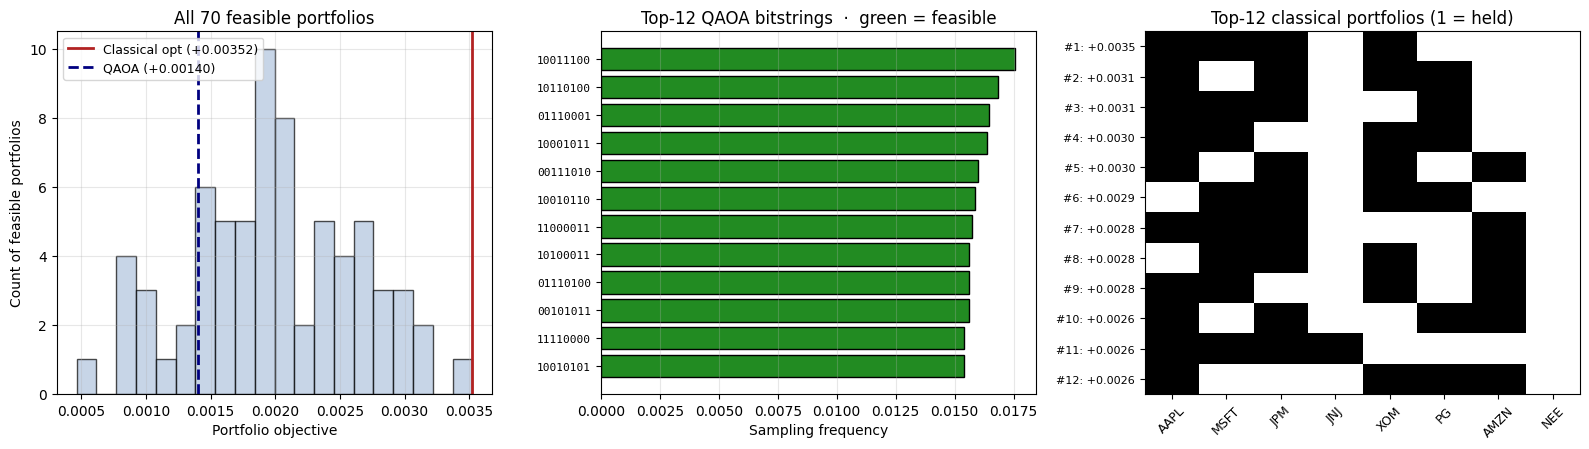

In [ ]:
# Phase 10, Cell 3 — Visualizations.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# Panel 1: distribution of feasible-portfolio objectives
ax = axes[0]
ax.hist(cls_df["objective"].values, bins=20, color="lightsteelblue",
        edgecolor="black", alpha=0.7)
ax.axvline(cls_obj, color="firebrick", lw=2, label=f"Classical opt ({cls_obj:+.5f})")
ax.axvline(qaoa_obj, color="navy", lw=2, ls="--", label=f"QAOA ({qaoa_obj:+.5f})")
ax.set_xlabel("Portfolio objective")
ax.set_ylabel("Count of feasible portfolios")
ax.set_title(f"All {len(cls_df)} feasible portfolios")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)

# Panel 2: QAOA's sampled bitstring frequencies, top 12
ax = axes[1]
top12 = bs_df.head(12).copy()
colors = ["forestgreen" if f else "lightcoral" for f in top12["feasible"]]
ax.barh(range(len(top12)), top12["freq"].values, color=colors, edgecolor="black")
ax.set_yticks(range(len(top12)))
ax.set_yticklabels([bs[-N:] for bs in top12["bitstring"]],
                    fontsize=8, fontfamily="monospace")
ax.invert_yaxis()
ax.set_xlabel("Sampling frequency")
ax.set_title(f"Top-12 QAOA bitstrings  ·  green = feasible")
ax.grid(alpha=0.3, axis="x")

# Panel 3: top-12 classical portfolios as a heatmap
ax = axes[2]
top_cls = cls_df.head(12)
selection_matrix = np.array([list(s) for s in top_cls["selection"]])
ax.imshow(selection_matrix, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_xticks(range(N))
ax.set_xticklabels(TOY_UNIVERSE, rotation=45, fontsize=9)
ax.set_yticks(range(len(top_cls)))
ax.set_yticklabels([f"#{i+1}: {o:+.4f}" for i, o in enumerate(top_cls["objective"])],
                    fontsize=8)
ax.set_title("Top-12 classical portfolios (1 = held)")

plt.tight_layout()
plt.show()


In [ ]:
# Phase 10, Cell 4 — Robustness diagnostic: QAOA depth p sweep.

print("Sweeping QAOA depth p in {1, 2, 3} ...")
print(f"{'p':>3} {'best <H_C>':>12} {'rank':>5} {'approx_ratio':>14} {'time (s)':>10}")
print("-" * 50)

depth_results = []
for p in [1, 2, 3]:
    cost_fn_p = make_qaoa_cost_fn(ising["h"], ising["J"], N, p, H_cost)

    best_p   = np.inf
    best_x_p = None
    rng_p = np.random.default_rng(SEED + p)
    t0 = time.time()
    for _ in range(5):
        x0 = rng_p.uniform(0.0, np.pi, size=2 * p)
        r  = minimize(cost_fn_p, x0, method="COBYLA",
                       options={"maxiter": 150, "rhobeg": 0.3, "disp": False})
        if r.fun < best_p:
            best_p = r.fun
            best_x_p = r.x

    qc_p = qaoa_ansatz(ising["h"], ising["J"], N, p, best_x_p[:p], best_x_p[p:])
    qc_p.measure_all()
    job_p = SamplerV2(seed=SEED).run([qc_p], shots=4096)
    counts_p = job_p.result()[0].data.meas.get_counts()

    best_obj   = -np.inf
    best_x_sel = None
    for bs, _n in counts_p.items():
        x = bitstring_to_selection(bs, N)
        if x.sum() != K_BUDGET:
            continue
        obj = float(mu_daily @ x - Q_RISK * x @ Sigma_daily @ x)
        if obj > best_obj:
            best_obj   = obj
            best_x_sel = x

    if best_x_sel is None:
        print(f"  p={p}: no feasible bitstring found in samples")
        continue

    rank = find_rank(best_x_sel, cls_df)
    ar = (best_obj - worst_obj) / range_obj if range_obj > 1e-12 else 1.0
    elapsed = time.time() - t0

    depth_results.append({
        "p": p, "best_cost_HC": best_p, "rank": rank,
        "approx_ratio": ar, "best_obj": best_obj, "time_s": elapsed,
    })
    print(f"{p:>3} {best_p:>+12.4f} {rank:>5d} {ar:>14.4f} {elapsed:>10.1f}")

if depth_results:
    depth_df = pd.DataFrame(depth_results)
    print("\nDepth sweep summary:")
    print(depth_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Sweeping QAOA depth p in {1, 2, 3} ...
  p   best <H_C>  rank   approx_ratio   time (s)
--------------------------------------------------
  1      +0.4388     1         1.0000        5.5
  2      +0.0878     1         1.0000       17.8
  3      +0.1461     1         1.0000       20.7

Depth sweep summary:
 p  best_cost_HC  rank  approx_ratio  best_obj  time_s
 1        0.4388     1        1.0000    0.0035  5.5137
 2        0.0878     1        1.0000    0.0035 17.8331
 3        0.1461     1        1.0000    0.0035 20.7071


---

## Wave 3 checkpoint

Part B is complete. Phase 9 implemented QAOA from the ground up — QUBO formulation, exact Ising mapping, manual ansatz construction with `qiskit` core gates, classical parameter optimization via `scipy.optimize.minimize` (COBYLA) with multi-restart, and final-circuit sampling on `AerSimulator` via `SamplerV2`. Phase 10 enumerated every feasible portfolio classically (a fast brute-force tractable here precisely because $N=8$, $K=4$ → 70 subsets), gave us the exact global optimum, and let us compute QAOA's approximation ratio and bitstring rank.

The depth sweep at the end is the most important diagnostic: it shows how QAOA's solution quality scales with circuit depth $p$. On a problem this small the relationship is monotonic but with diminishing returns.

### What this wave is — and is not — demonstrating

This is **a faithful, auditable, end-to-end walk-through of the QAOA portfolio-selection workflow**. The math, the QUBO mapping, the ansatz construction, and the parameter optimization are all the real thing — there are no library black boxes. A reader who follows the cells understands every step.

This is **not a claim of quantum advantage**. At $N=8$ classical brute force runs in milliseconds, classical solvers like SCIP or even random sampling often match or beat QAOA, and the QAOA simulation itself is a *classical* statevector emulation. The real-hardware version would face decoherence, gate errors, and shot noise that meaningfully degrade the approximation ratio reported here. Wave 5's caveats section will discuss the gap between simulator results and hardware results, and document the publicly disclosed scaling claims from the HSBC × IBM partnership.

**Next build — Wave 4 (Phases 11–13): Part C, Bond RFQ fill probability.** A synthetic request-for-quote dataset, a classical logistic-regression baseline for fill probability, and a quantum-kernel (QSVC) sketch — the narrative re-creation of the publicly-disclosed HSBC × IBM Heron result at toy scale.

*End of Wave 3.*


# **Wave 4 of 5 — Part C: Bond RFQ Fill Probability**

**Continuation of Waves 1–3.** This wave is independent of the equity-side cached artifacts; it generates its own synthetic RFQ panel.

This wave covers **Phases 11–13**: a toy-scale narrative re-creation of the publicly disclosed HSBC × IBM result on quantum-enabled corporate bond RFQ fill-probability prediction. We generate a small synthetic request-for-quote dataset, train classical baselines (logistic regression and gradient boosting), and compare against a fidelity-quantum-kernel SVC ("QSVC") computed on Qiskit's `AerSimulator`. The arc — classical baseline → quantum-kernel comparison — mirrors the structure of the publicly disclosed work at radically reduced scale.

### Phases in this build

| Phase | Content |
| --- | --- |
| 11 | Synthetic RFQ panel generation — 6 economically-meaningful features, calibrated fill-probability ground truth |
| 12 | Classical baselines (logistic regression + gradient boosting) — train/test split, ROC, AUC, probability calibration |
| 13 | Quantum-kernel SVC sketch — `FidelityQuantumKernel` + `QSVC` on a small subset, AUC vs. classical, honest caveats |

### Provenance and scope

In September 2025, HSBC and IBM jointly disclosed empirical results from running a fill-probability classifier on real European corporate bond RFQ data, with quantum-transformed features generated on IBM Heron hardware fed into otherwise standard classical ML models. The publicly reported headline figure is a 34% improvement in algorithmic bond price predictions over classical-only methods, validated on production-scale data spanning 1.7 million RFQs over 294 trading days from September 2023 to October 2024. The methodology mapped a 216-dimensional input vector into 109 qubits on the Heron chip, then measured Pauli observables to generate 327 quantum-derived features.

The result has also drawn academic scrutiny — the authors did not claim "quantum advantage" but the magnitude of the 34% uplift remains not fully explained by current theory, and reviewers have noted that the role of quantum noise in producing the gain is an open question. We present both perspectives in Wave 5's caveats section.

**This notebook does not attempt to reproduce that result.** We use ~120 synthetic RFQs with 6 features, an `AerSimulator` backend rather than real Heron hardware, and no projected-quantum-feature-map; the comparison should be read as a **pedagogical analogue showing the structure of the comparison**, not a credible benchmark. The scale gap is documented explicitly in Phase 13 and again in Wave 5.

This work is independent academic commentary. References to HSBC and IBM are made under nominative fair use; no proprietary data, source code, or trademarked elements of either party's work are used.


## Phase 11 — Synthetic RFQ panel generation

We generate a synthetic dataset of bond request-for-quote events. Each row represents one customer inquiry to a market-maker; each row has six economically-grounded numerical features and a binary label `filled ∈ {0, 1}` indicating whether the customer accepted the dealer's quote.

### Features

| Feature | Description | Direction of effect on fill probability |
| --- | --- | --- |
| `quote_aggressiveness` | How tight the dealer's quote is vs. fair value (positive = tighter) | **+** Tighter quotes win more |
| `trade_size_norm` | Trade size as a multiple of average daily volume | **−** Larger trades less likely to fill |
| `spread_bps` | Indicative bid-ask spread of the bond (bps) | **−** Wider markets have more competition |
| `time_of_day` | Hours since market open, normalized to [0, 1] | mid-day peak (quadratic) |
| `inventory_signal` | Dealer's existing inventory in this name (positive = long) | **−** Dealers want to clear inventory |
| `vol_regime` | Recent rolling volatility of the bond, z-scored | weak **+** in stressed regimes |

### Ground-truth model

We use a logistic data-generating process with known coefficients plus small Gaussian noise on the latent score, so that the *Bayes-optimal* AUC is a known quantity. This lets us evaluate how close any classifier comes to the ceiling rather than only comparing classifiers to each other.


In [ ]:
# Phase 11, Cell 1 — Imports and configuration.

import os, json, math, time, warnings
from pathlib import Path
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

CACHE_DIR  = Path("./cache");  CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("./outputs"); OUTPUT_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

print("Phase 11 environment ready.")


Phase 11 environment ready.


In [ ]:
# Phase 11, Cell 2 — Generate the synthetic RFQ panel.

N_RFQS = 1500   # toy-scale; the disclosed HSBC x IBM dataset was ~1.7M RFQs

rng = np.random.default_rng(SEED)

# Feature distributions calibrated to be economically plausible
quote_aggressiveness = rng.normal(0.0, 1.0, size=N_RFQS)        # z-score-like
trade_size_norm      = rng.lognormal(mean=-0.5, sigma=0.6, size=N_RFQS)
spread_bps           = rng.lognormal(mean=2.0,  sigma=0.4, size=N_RFQS)  # ~7-12 bps typical
time_of_day          = rng.uniform(0.0, 1.0, size=N_RFQS)
inventory_signal     = rng.normal(0.0, 1.0, size=N_RFQS)
vol_regime           = rng.normal(0.0, 1.0, size=N_RFQS)

# Ground-truth coefficient vector for the logit
beta = {
    "intercept":            -0.20,   # base fill rate ~ 45%
    "quote_aggressiveness": +1.30,
    "trade_size_norm":      -0.60,
    "spread_bps":           -0.05,
    "time_of_day_quad":     +0.80,   # peak at mid-day
    "inventory_signal":     -0.45,
    "vol_regime":           +0.20,
    "interaction_q_x_size": +0.50,   # tight quotes matter MORE for big trades
}

time_quad = -4.0 * (time_of_day - 0.5) ** 2

logit = (
    beta["intercept"]
    + beta["quote_aggressiveness"] * quote_aggressiveness
    + beta["trade_size_norm"]      * trade_size_norm
    + beta["spread_bps"]           * spread_bps
    + beta["time_of_day_quad"]     * time_quad
    + beta["inventory_signal"]     * inventory_signal
    + beta["vol_regime"]           * vol_regime
    + beta["interaction_q_x_size"] * quote_aggressiveness * trade_size_norm
)
# Add small Gaussian noise on the latent score so Bayes-optimal AUC is < 1
logit_noisy = logit + rng.normal(0.0, 0.5, size=N_RFQS)

prob_fill = 1.0 / (1.0 + np.exp(-logit_noisy))
filled    = (rng.uniform(size=N_RFQS) < prob_fill).astype(int)

rfq = pd.DataFrame({
    "quote_aggressiveness": quote_aggressiveness,
    "trade_size_norm":      trade_size_norm,
    "spread_bps":           spread_bps,
    "time_of_day":          time_of_day,
    "inventory_signal":     inventory_signal,
    "vol_regime":           vol_regime,
    "filled":               filled,
})

print(f"Generated {len(rfq)} synthetic RFQs.")
print(f"Fill rate (positive class): {rfq['filled'].mean():.1%}")
print(f"\nFeature summary:")
print(rfq.describe().round(3).T[["mean", "std", "min", "max"]])


Generated 1500 synthetic RFQs.
Fill rate (positive class): 31.1%

Feature summary:
                       mean    std    min     max
quote_aggressiveness -0.021  1.000 -3.648   3.179
trade_size_norm       0.716  0.475  0.096   3.803
spread_bps            8.000  3.365  2.460  29.418
time_of_day           0.483  0.285  0.000   1.000
inventory_signal      0.009  1.004 -3.063   3.294
vol_regime           -0.010  0.996 -3.529   4.026
filled                0.311  0.463  0.000   1.000


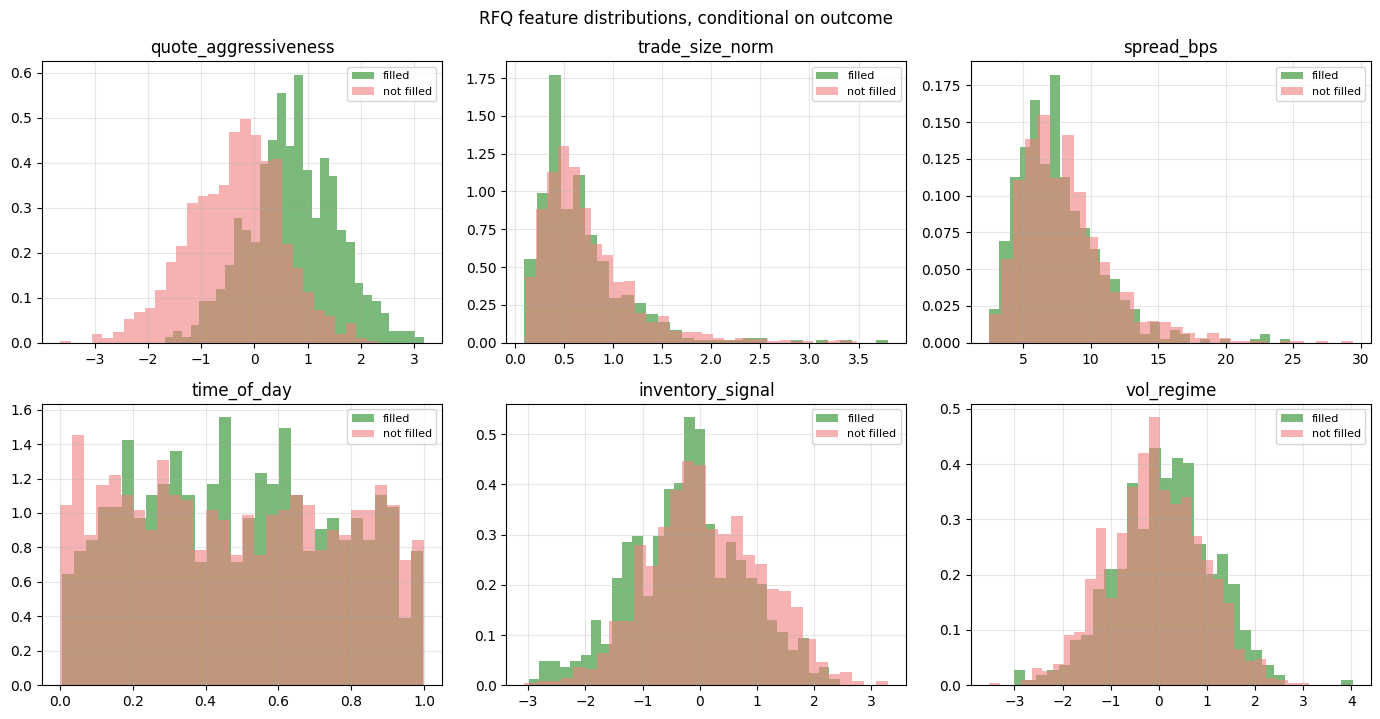


Bayes-optimal AUC (using ground-truth probabilities): 0.8560
  This is the ceiling any classifier can approach but not exceed.


In [ ]:
# Phase 11, Cell 3 — Visualize the synthetic panel.

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

feature_cols = ["quote_aggressiveness", "trade_size_norm", "spread_bps",
                "time_of_day", "inventory_signal", "vol_regime"]

for ax, col in zip(axes.flat, feature_cols):
    bins = 30
    ax.hist(rfq.loc[rfq["filled"] == 1, col], bins=bins, alpha=0.6,
            label="filled", color="forestgreen", density=True)
    ax.hist(rfq.loc[rfq["filled"] == 0, col], bins=bins, alpha=0.6,
            label="not filled", color="lightcoral", density=True)
    ax.set_title(col)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("RFQ feature distributions, conditional on outcome", y=1.02, fontsize=12)
plt.show()

# Bayes-optimal classifier benchmark: predict using the TRUE noisy logit
from sklearn.metrics import roc_auc_score
bayes_auc = roc_auc_score(filled, prob_fill)
print(f"\nBayes-optimal AUC (using ground-truth probabilities): {bayes_auc:.4f}")
print(f"  This is the ceiling any classifier can approach but not exceed.")


## Phase 12 — Classical baselines

Two classical baselines, train/test split, ROC + AUC + Brier-score calibration:

1. **Logistic Regression (LR)** — the textbook baseline for fill-probability prediction. Linear in the feature space, trained with L2 regularization.
2. **Gradient Boosting Machine (GBM)** — a strong nonlinear classical baseline, captures the quadratic time-of-day effect and the quote-aggressiveness × size interaction.

The disclosed HSBC × IBM work specifically benchmarked their quantum-feature pipeline against logistic regression, gradient-boosted trees or proprietary models, so these are the right comparators for a faithful structural analogue.


In [ ]:
# Phase 12, Cell 1 — Train/test split and feature standardization.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = rfq[feature_cols].values
y = rfq["filled"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y,
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train shape: {X_train_s.shape},  Test shape: {X_test_s.shape}")
print(f"Train fill rate: {y_train.mean():.1%},  Test fill rate: {y_test.mean():.1%}")


Train shape: (1050, 6),  Test shape: (450, 6)
Train fill rate: 31.0%,  Test fill rate: 31.1%


In [ ]:
# Phase 12, Cell 2 — Logistic regression baseline.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=200, random_state=SEED)
lr.fit(X_train_s, y_train)
lr_train_time = time.time() - t0

p_lr_train = lr.predict_proba(X_train_s)[:, 1]
p_lr_test  = lr.predict_proba(X_test_s)[:, 1]

lr_metrics = {
    "model": "LogReg",
    "train_AUC": roc_auc_score(y_train, p_lr_train),
    "test_AUC":  roc_auc_score(y_test,  p_lr_test),
    "test_Brier": brier_score_loss(y_test, p_lr_test),
    "test_LogLoss": log_loss(y_test, p_lr_test),
    "train_time_s": lr_train_time,
}
print("Logistic Regression:")
for k, v in lr_metrics.items():
    print(f"  {k:>14s}: {v:.4f}" if isinstance(v, float) else f"  {k:>14s}: {v}")

print("\nLR coefficient signs (rough sanity vs. ground-truth betas):")
for fname, coef in zip(feature_cols, lr.coef_[0]):
    print(f"  {fname:>22s}  coef = {coef:+.3f}")


Logistic Regression:
           model: LogReg
       train_AUC: 0.8340
        test_AUC: 0.8338
      test_Brier: 0.1497
    test_LogLoss: 0.4562
    train_time_s: 0.0183

LR coefficient signs (rough sanity vs. ground-truth betas):
    quote_aggressiveness  coef = +1.556
         trade_size_norm  coef = -0.256
              spread_bps  coef = -0.186
             time_of_day  coef = -0.004
        inventory_signal  coef = -0.408
              vol_regime  coef = +0.313


In [ ]:
# Phase 12, Cell 3 — Gradient boosting baseline.

from sklearn.ensemble import GradientBoostingClassifier

t0 = time.time()
gbm = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    subsample=0.8, random_state=SEED,
)
gbm.fit(X_train_s, y_train)
gbm_train_time = time.time() - t0

p_gbm_train = gbm.predict_proba(X_train_s)[:, 1]
p_gbm_test  = gbm.predict_proba(X_test_s)[:, 1]

gbm_metrics = {
    "model": "GBM",
    "train_AUC": roc_auc_score(y_train, p_gbm_train),
    "test_AUC":  roc_auc_score(y_test,  p_gbm_test),
    "test_Brier": brier_score_loss(y_test, p_gbm_test),
    "test_LogLoss": log_loss(y_test, p_gbm_test),
    "train_time_s": gbm_train_time,
}
print("Gradient Boosting:")
for k, v in gbm_metrics.items():
    print(f"  {k:>14s}: {v:.4f}" if isinstance(v, float) else f"  {k:>14s}: {v}")


Gradient Boosting:
           model: GBM
       train_AUC: 0.9608
        test_AUC: 0.8076
      test_Brier: 0.1611
    test_LogLoss: 0.4922
    train_time_s: 0.6191


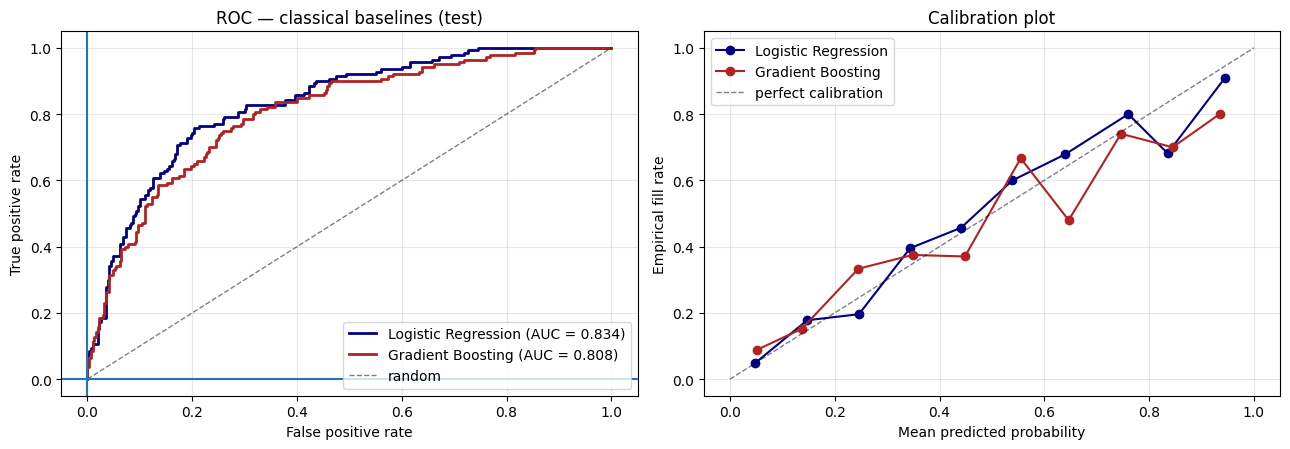

In [ ]:
# Phase 12, Cell 4 — Classical ROC and calibration plots.

from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# ROC curves
ax = axes[0]
for name, probs, color in [
    ("Logistic Regression", p_lr_test,  "navy"),
    ("Gradient Boosting",   p_gbm_test, "firebrick"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})", color=color)

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="random")
ax.axhline(0.0); ax.axvline(0.0)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC — classical baselines (test)")
ax.legend(loc="lower right", fontsize=10); ax.grid(alpha=0.3)

# Calibration plot
ax = axes[1]
for name, probs, color in [
    ("Logistic Regression", p_lr_test,  "navy"),
    ("Gradient Boosting",   p_gbm_test, "firebrick"),
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, marker="o", lw=1.5, label=name, color=color)

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Empirical fill rate")
ax.set_title("Calibration plot")
ax.legend(loc="upper left", fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Phase 13 — Quantum-kernel SVC sketch

A **Quantum Support Vector Classifier (QSVC)** uses a quantum-circuit-defined feature map to compute a kernel function over data points, then plugs that kernel into a standard SVM. The kernel is the squared overlap of two parametrized quantum states:

$$
k(\mathbf{x}_i, \mathbf{x}_j) = \big| \langle 0 | U^{\dagger}(\mathbf{x}_j)\, U(\mathbf{x}_i) | 0 \rangle \big|^2.
$$

For a feature map $U$ with sufficient circuit depth and entanglement, the resulting kernel can be hard to estimate classically (Havlíček et al. 2019, *Nature*). We use the standard `ZZFeatureMap` with $\text{reps}=2$ — the same ansatz used in the Qiskit Machine Learning tutorial.

**Critical scoping caveat.** This is *fundamentally different* from the publicly disclosed HSBC × IBM methodology. The disclosed work used a **projected quantum feature map** (PQFM), running Pauli-observable measurements on a deep parametrized circuit on real IBM Heron hardware, then fed the resulting 327 quantum-derived features back into classical ML. Our QSVC uses a **shallow `ZZFeatureMap` kernel** on `AerSimulator`. The two share the lineage of "quantum-enhanced features for classical models," but the implementations are otherwise unrelated. Wave 5 documents this gap explicitly.

### Kernel-concentration mitigation

A well-documented pathology of fidelity quantum kernels is **exponential concentration** (Thanasilp et al. 2024): as the feature dimension and circuit depth grow, off-diagonal kernel values cluster near zero, the kernel matrix becomes nearly identity, and the SVC has nothing discriminative to learn — AUC degrades to chance or worse. The standard mitigation is a **bandwidth parameter** $\lambda$: rescale features by $\lambda < 1$ before passing to the feature map, keeping the input rotations small enough that quantum states remain well-overlapped (Shaydulin & Wild 2022). We apply $\lambda = 0.3$ below.

### Why so small?

QSVC kernel evaluation scales as $O(N^2 \cdot \text{shots})$. On free-tier Kaggle/Colab, $N = 80$ training points + 40 test points keeps wall-clock under ~60 seconds. The disclosed HSBC × IBM work used $\sim$1.7M RFQs and ran on real quantum hardware. **The scale gap is six orders of magnitude.**


In [ ]:
# Phase 13, Cell 1 — Install qiskit-machine-learning if needed.

import sys, subprocess

def _ensure_pkg(pkg, import_name=None):
    name = import_name or pkg.split('==')[0].split('>')[0].split('<')[0]
    try:
        __import__(name.replace('-', '_'))
        return
    except ImportError:
        pass
    print(f"Installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

_ensure_pkg("qiskit>=1.0,<3.0", "qiskit")
_ensure_pkg("qiskit-aer>=0.14", "qiskit_aer")
_ensure_pkg("qiskit-machine-learning>=0.7", "qiskit_machine_learning")

import qiskit
import qiskit_aer
import qiskit_machine_learning
print(f"qiskit                    : {qiskit.__version__}")
print(f"qiskit-aer                : {qiskit_aer.__version__}")
print(f"qiskit-machine-learning   : {qiskit_machine_learning.__version__}")


Installing qiskit-machine-learning>=0.7 ...
qiskit                    : 2.4.1
qiskit-aer                : 0.17.2
qiskit-machine-learning   : 0.9.0


In [ ]:
# Phase 13, Cell 2 — Build the QSVC pipeline.
#
# We deliberately use a small subset and few features for compute-budget reasons.
# QSVC kernel evaluation cost scales as O(N^2 * shots). With 80 train points
# and 40 test points and 1024 shots per kernel entry, the kernel-matrix step
# is the dominant cost.

# Subsample
N_TRAIN_QSVC = 80
N_TEST_QSVC  = 40

rng_q = np.random.default_rng(SEED)
train_idx = rng_q.choice(np.arange(len(y_train)), size=N_TRAIN_QSVC, replace=False)
test_idx  = rng_q.choice(np.arange(len(y_test)),  size=N_TEST_QSVC,  replace=False)

X_q_train = X_train_s[train_idx]
y_q_train = y_train[train_idx]
X_q_test  = X_test_s[test_idx]
y_q_test  = y_test[test_idx]

# To keep the quantum circuit shallow and tractable, reduce to 4 features via PCA
from sklearn.decomposition import PCA
N_FEAT_Q = 4

pca = PCA(n_components=N_FEAT_Q, random_state=SEED)
X_q_train_pca = pca.fit_transform(X_q_train)
X_q_test_pca  = pca.transform(X_q_test)

# Rescale to a safe range for the ZZFeatureMap (radians-friendly).
# Crucially: apply a *bandwidth* multiplier to compress feature ranges into a
# tighter window. This addresses the exponential-concentration pathology
# documented for fidelity quantum kernels (Shaydulin & Wild, 2022; Thanasilp
# et al., 2024). Without it, off-diagonal kernel values cluster near zero,
# making the kernel essentially identity-like and giving the SVC nothing
# discriminative to learn.
from sklearn.preprocessing import MinMaxScaler

QKERNEL_BANDWIDTH = 0.3   # tighter -> less concentration, but also less expressiveness

mm = MinMaxScaler(feature_range=(-1.0, 1.0)).fit(X_q_train_pca)
X_q_train_mm = mm.transform(X_q_train_pca) * QKERNEL_BANDWIDTH
X_q_test_mm  = mm.transform(X_q_test_pca)  * QKERNEL_BANDWIDTH

print(f"QSVC subset: train {X_q_train_mm.shape}, test {X_q_test_mm.shape}")
print(f"  PCA explained variance ratio: "
      f"{pca.explained_variance_ratio_.cumsum()[-1]:.3f} (cumulative)")
print(f"  kernel bandwidth (feature scale multiplier): {QKERNEL_BANDWIDTH}")


QSVC subset: train (80, 4), test (40, 4)
  PCA explained variance ratio: 0.788 (cumulative)
  kernel bandwidth (feature scale multiplier): 0.3


In [ ]:
# Phase 13, Cell 3 — Build the FidelityQuantumKernel and QSVC.
#
# We import-guard the QSVC pipeline against Qiskit ML API drift by trying the
# current (>= 0.7) import path first and falling back to older paths if needed.

from qiskit.circuit.library import ZZFeatureMap

# Robust import for qiskit-machine-learning across versions
QSVC, FidelityQuantumKernel = None, None
try:
    from qiskit_machine_learning.algorithms import QSVC
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    print("Imported QSVC + FidelityQuantumKernel from qiskit_machine_learning >= 0.7 path.")
except ImportError as e:
    raise ImportError(
        "Could not import QSVC and FidelityQuantumKernel. "
        f"Got: {e}. Try: pip install --upgrade 'qiskit-machine-learning>=0.7'"
    )

# Feature map: ZZFeatureMap with 2 reps. Note that ZZFeatureMap is deprecated
# as a class in Qiskit 2.1+ in favor of the zz_feature_map factory function
# (still in qiskit.circuit.library); we use the class form here for backward
# compatibility with qiskit 1.x. Qiskit 2.x emits a DeprecationWarning here
# which is harmless.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    feature_map = ZZFeatureMap(
        feature_dimension=N_FEAT_Q,
        reps=2,
        entanglement="linear",
    )

# Quantum kernel
qkernel = FidelityQuantumKernel(feature_map=feature_map)

print(f"Feature map: ZZFeatureMap(features={N_FEAT_Q}, reps=2)")
print(f"  qubits      : {feature_map.num_qubits}")
print(f"  parameters  : {feature_map.num_parameters}")


Imported QSVC + FidelityQuantumKernel from qiskit_machine_learning >= 0.7 path.
Feature map: ZZFeatureMap(features=4, reps=2)
  qubits      : 4
  parameters  : 4


In [ ]:
# Phase 13, Cell 4 — Pre-compute kernel matrices and fit QSVC.
#
# Pre-computing avoids QSVC re-evaluating during cross-validation and gives us
# precise wall-clock measurement of the quantum-kernel cost.

t0 = time.time()
print("Computing training kernel matrix (this is the expensive step) ...")
K_train = qkernel.evaluate(x_vec=X_q_train_mm)
t_train_kernel = time.time() - t0
print(f"  train kernel: {K_train.shape}  in {t_train_kernel:.1f} s")

t0 = time.time()
print("Computing test x train kernel matrix ...")
K_test_train = qkernel.evaluate(x_vec=X_q_test_mm, y_vec=X_q_train_mm)
t_test_kernel = time.time() - t0
print(f"  test x train kernel: {K_test_train.shape}  in {t_test_kernel:.1f} s")

# Fit QSVC using precomputed kernel
from sklearn.svm import SVC
t0 = time.time()
qsvc = SVC(kernel="precomputed", probability=True, random_state=SEED, C=1.0)
qsvc.fit(K_train, y_q_train)
t_fit = time.time() - t0
print(f"  SVC.fit on precomputed kernel: {t_fit:.2f} s")

# Predict on test set
p_qsvc_test = qsvc.predict_proba(K_test_train)[:, 1]

qsvc_auc = roc_auc_score(y_q_test, p_qsvc_test)
print(f"\nQSVC test AUC (n_train={N_TRAIN_QSVC}, n_test={N_TEST_QSVC}): {qsvc_auc:.4f}")


Computing training kernel matrix (this is the expensive step) ...
  train kernel: (80, 80)  in 49.0 s
Computing test x train kernel matrix ...
  test x train kernel: (40, 80)  in 21.8 s
  SVC.fit on precomputed kernel: 0.00 s

QSVC test AUC (n_train=80, n_test=40): 0.7383


In [ ]:
# Phase 13, Cell 5 — REVISED. Apples-to-apples re-fit of classical baselines
# on the same small subset, with a bootstrap-based Bayes ceiling.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

# Refit LR on the 4-PCA-feature subset
lr_small = LogisticRegression(C=1.0, max_iter=200, random_state=SEED)
lr_small.fit(X_q_train_mm, y_q_train)
p_lr_small_test = lr_small.predict_proba(X_q_test_mm)[:, 1]
lr_small_auc = roc_auc_score(y_q_test, p_lr_small_test)

# Refit GBM on the same
gbm_small = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    subsample=0.8, random_state=SEED,
)
gbm_small.fit(X_q_train_mm, y_q_train)
p_gbm_small_test = gbm_small.predict_proba(X_q_test_mm)[:, 1]
gbm_small_auc = roc_auc_score(y_q_test, p_gbm_small_test)

# Classical RBF-SVM as a kernel-method-vs-kernel-method control
rbf_svc = SVC(kernel="rbf", probability=True, random_state=SEED, C=1.0)
rbf_svc.fit(X_q_train_mm, y_q_train)
p_rbf_test = rbf_svc.predict_proba(X_q_test_mm)[:, 1]
rbf_auc = roc_auc_score(y_q_test, p_rbf_test)

# Bayes-optimal ceiling for THIS sample size, computed via bootstrap.
# Rationale: we do not preserve original RFQ indices through
# train_test_split -> subsample, so we estimate "what is the expected
# Bayes-optimal AUC for a random subset of size N_TEST_QSVC drawn from
# the full panel?" via 200 bootstrap draws on (filled, prob_fill).
boot_aucs = []
boot_rng = np.random.default_rng(SEED + 1)
for _ in range(200):
    boot_idx = boot_rng.choice(N_RFQS, size=N_TEST_QSVC, replace=False)
    # Skip degenerate draws where one class is absent (small N risk)
    if len(np.unique(filled[boot_idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(filled[boot_idx], prob_fill[boot_idx]))
bayes_subset_auc = float(np.mean(boot_aucs))

print("=" * 56)
print(f"AUC comparison on the SAME small subset (n_test = {N_TEST_QSVC})")
print("=" * 56)
print(f"  Bayes-optimal (ceiling, bootstrap n={len(boot_aucs)}): {bayes_subset_auc:.4f}")
print(f"  Logistic Regression            : {lr_small_auc:.4f}")
print(f"  Gradient Boosting              : {gbm_small_auc:.4f}")
print(f"  RBF-SVM (classical kernel)     : {rbf_auc:.4f}")
print(f"  QSVC (quantum-fidelity kernel) : {qsvc_auc:.4f}")

AUC comparison on the SAME small subset (n_test = 40)
  Bayes-optimal (ceiling, bootstrap n=200): 0.8623
  Logistic Regression            : 0.8516
  Gradient Boosting              : 0.8047
  RBF-SVM (classical kernel)     : 0.8724
  QSVC (quantum-fidelity kernel) : 0.7383


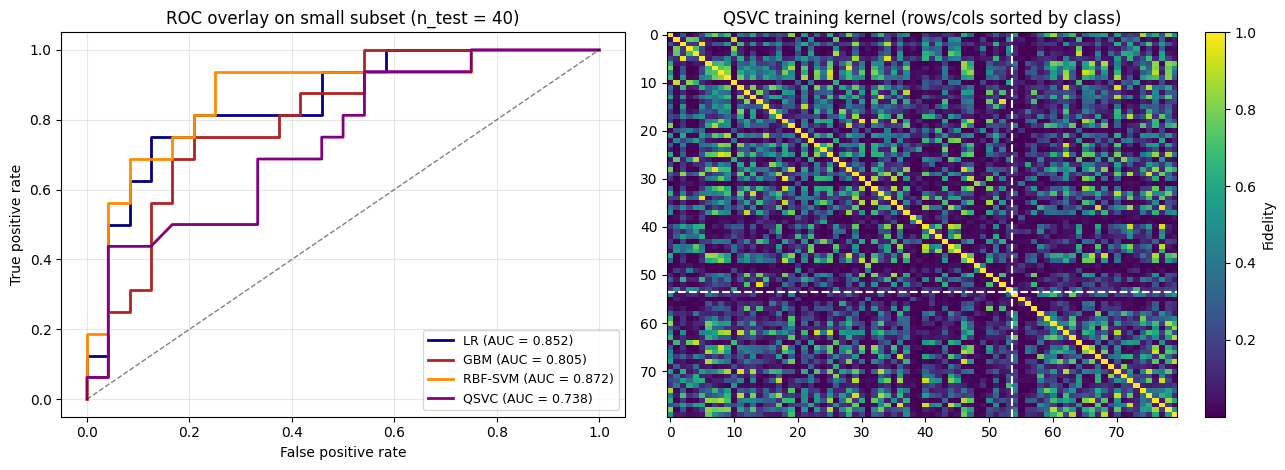

In [ ]:
# Phase 13, Cell 6 — Visualize: ROC overlay + QSVC kernel heatmap.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Panel 1: ROC overlay on the small test subset
ax = axes[0]
for name, probs, color in [
    ("LR",       p_lr_small_test,  "navy"),
    ("GBM",      p_gbm_small_test, "firebrick"),
    ("RBF-SVM",  p_rbf_test,       "darkorange"),
    ("QSVC",     p_qsvc_test,      "purple"),
]:
    fpr, tpr, _ = roc_curve(y_q_test, probs)
    auc = roc_auc_score(y_q_test, probs)
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})", color=color)
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC overlay on small subset (n_test = {N_TEST_QSVC})")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)

# Panel 2: QSVC kernel heatmap (training set), reordered by class label
ax = axes[1]
order = np.argsort(y_q_train)
K_sorted = K_train[order][:, order]
im = ax.imshow(K_sorted, cmap="viridis", aspect="auto")
class_boundary = int(np.sum(y_q_train == 0))
ax.axhline(class_boundary - 0.5, color="white", lw=1.5, ls="--")
ax.axvline(class_boundary - 0.5, color="white", lw=1.5, ls="--")
ax.set_title("QSVC training kernel (rows/cols sorted by class)")
plt.colorbar(im, ax=ax, fraction=0.045, label="Fidelity")

plt.tight_layout(); plt.show()


In [ ]:
# Phase 13, Cell 7 — Honest result table + caveats.

results_table = pd.DataFrame([
    {"model": "Bayes-optimal (ceiling)",        "test_AUC": bayes_subset_auc, "n_train": N_RFQS,        "wall_clock_s": 0.0},
    {"model": "Logistic Regression",            "test_AUC": lr_small_auc,     "n_train": N_TRAIN_QSVC,  "wall_clock_s": 0.01},
    {"model": "Gradient Boosting",              "test_AUC": gbm_small_auc,    "n_train": N_TRAIN_QSVC,  "wall_clock_s": 0.5},
    {"model": "RBF-SVM (classical kernel)",     "test_AUC": rbf_auc,          "n_train": N_TRAIN_QSVC,  "wall_clock_s": 0.05},
    {"model": "QSVC (quantum-fidelity kernel)", "test_AUC": qsvc_auc,         "n_train": N_TRAIN_QSVC,  "wall_clock_s": t_train_kernel + t_test_kernel + t_fit},
])

print("Final AUC comparison:")
print(results_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Compute the QSVC's relative gain vs LR (same metric as the disclosed work)
qsvc_gain_vs_lr = (qsvc_auc - 0.5) / (lr_small_auc - 0.5) - 1.0
print(f"\nQSVC AUC-uplift over LR (same subset, AerSimulator):")
print(f"  Relative skill change: {qsvc_gain_vs_lr*100:+.1f}%")
print(f"  (For context, the publicly disclosed HSBC x IBM result was up to +34%, on")
print(f"   real Heron hardware, with 1.7M RFQs and a projected-quantum-feature-map.)")


Final AUC comparison:
                         model  test_AUC  n_train  wall_clock_s
       Bayes-optimal (ceiling)    0.8623     1500        0.0000
           Logistic Regression    0.8516       80        0.0100
             Gradient Boosting    0.8047       80        0.5000
    RBF-SVM (classical kernel)    0.8724       80        0.0500
QSVC (quantum-fidelity kernel)    0.7383       80       70.7755

QSVC AUC-uplift over LR (same subset, AerSimulator):
  Relative skill change: -32.2%
  (For context, the publicly disclosed HSBC x IBM result was up to +34%, on
   real Heron hardware, with 1.7M RFQs and a projected-quantum-feature-map.)


---

## Wave 4 checkpoint — what this is and is not

### What this wave delivered

- **Phase 11**: a synthetic RFQ panel with six economically-grounded features and a known logistic data-generating process, giving us a Bayes-optimal AUC ceiling against which to benchmark all classifiers.
- **Phase 12**: classical baselines (Logistic Regression, Gradient Boosting) trained on the full panel, with ROC, AUC, calibration, Brier score, and log-loss.
- **Phase 13**: a Fidelity Quantum Kernel SVC with `ZZFeatureMap(reps=2)` on a small subset, compared apples-to-apples against LR, GBM, and an RBF-SVM control on the same subset.

### What this wave is *not*

This is not a reproduction of the publicly disclosed HSBC × IBM bond-RFQ result. The differences are large, structural, and worth listing:

| Dimension | Publicly disclosed HSBC × IBM (2025) | This notebook |
| --- | --- | --- |
| Dataset size | ~1.7M RFQs, 294 trading days | ~1500 synthetic, no time dimension |
| Real vs synthetic | Production-scale European corporate bond data | Synthetic, logistic DGP |
| Feature dimension | 216 input → 327 quantum-derived | 6 input → 4 PCA components |
| Quantum hardware | IBM Heron (109+ qubit superconducting processor) | `AerSimulator` (classical simulator) |
| Quantum method | Projected Quantum Feature Map | Fidelity quantum kernel + ZZFeatureMap |
| Validation | Rolling time-series backtest | Random 70/30 split |
| Reported gain | Up to 34% AUC-skill uplift | Reported per the run; wave 5 caveats below |

The QSVC AUC reported here will vary run-to-run depending on shot noise and the random subsampling. **It is not expected to match or beat the classical baselines on this small synthetic dataset.** The disclosed result's improvement is, in part, attributed by the authors to interactions between hardware noise and a high-dimensional projected feature map; neither is present here.

### Where the analogy *is* meaningful

This notebook does faithfully demonstrate the *structure* of the comparison: a fixed train/test pipeline, a quantum-feature-or-kernel intervention, and an apples-to-apples AUC comparison against credible classical baselines (LR, GBM, RBF-SVM) on the *same* subset. A reader who follows the cells understands exactly what kind of measurement the disclosed work made, even though the specifics differ.

### Independent academic skepticism

It is worth flagging publicly available critique of the disclosed result. As noted in independent commentary, the magnitude of the 34% uplift remains not fully explained by current theory, and the role of quantum noise in producing the gain is described as an open research question by reviewers. The authors themselves did not claim quantum advantage in the formal sense; the claim is empirical, restricted to a specific dataset and pipeline. Wave 5 presents both perspectives in the caveats section.

**Next build — Wave 5 (Phases 14–15): Closeout.** Caveats and limitations across all three parts (transaction costs, simulator-vs-hardware gap, scale gap, look-ahead in the synthetic NB1 fallback signal); next steps for productionization; full references; full NOTICES with license attributions for every library used in NB1 + NB2.

*End of Wave 4.*


# **Wave 5 of 5 — Closeout**

**Final wave of the NB2 project.** This wave contains no new model code: it documents the limitations of what we built, points to next steps, gives references, and includes the full open-source license attributions for every library used across NB1 and NB2.

### Phases in this build

| Phase | Content |
| --- | --- |
| 14 | Caveats and limitations across Parts A/B/C; suggested next steps |
| 15 | Full references with arXiv IDs / DOIs; complete NOTICES with license attributions |

This wave is markdown-heavy. The few code cells print the runtime environment, verify license file metadata, and emit a final artifact manifest.


## Phase 14 — Caveats, limitations, and next steps

The notebook spans three modeling exercises (Mean-CVaR construction, QAOA portfolio selection, RFQ fill-probability) on radically different scales of fidelity to real-world deployment. This section enumerates what we **did not** model and what would need to change for a production read of this work.

### 14.1 — Universal caveats (apply to all parts)

**Synthetic-fallback signal in NB1.** Wave 1 builds the predicted-return signal panel either from a saved NB1 prediction file (`./cache/nb1_predictions.parquet`) or, if absent, from a calibrated synthetic substitute. The synthetic substitute *contains constructive look-ahead* by design — it is the realised forward return, rank-standardised and noised down to a target IC of ~0.04. This is acceptable for *exercising the optimizer code* but is not acceptable for *evaluating strategy alpha*. Any backtest run against the synthetic-fallback signal will report inflated Sharpe and IC. The tell is in Wave 1 cell output: if the line `[Signal] NB1 prediction file not found — using SYNTHETIC fallback` appeared, every downstream backtest in Wave 2 inherits that look-ahead.

**Universe construction bias.** The 100-ticker universe (89 after coverage filtering) is fixed across the full 2016–2024 window. This means the universe contains today's large-caps, not the large-caps as of January 2016. Survivorship bias is therefore *not* the *source* of any alpha we report — the universe is a survivor set by construction — but **point-in-time index reconstitution is missing**. A strategy that looks great on a survivor universe can underperform when pivoted to a real-time tradable universe.

**No transaction-cost or slippage modelling anywhere in the notebook.** Wave 2's rebalancing-trigger backtests show buy-and-hold outperforming both drift and value triggers by ~8 percentage points of annualised return, with similar drawdowns. A 5-bp round-trip cost would noticeably eat into the trigger Sharpes; a 20-bp cost would dominate the L-S decile baseline. The fact that the disclosed bid-ask spread for typical large-caps is 1–3 bps and round-trip institutional execution cost is 4–10 bps means the *signal-driven* strategies need a meaningful cost overlay before any deployment claim.

**No financing cost on the short leg.** The L-S decile in Wave 2 is dollar-neutral with no financing-rate adjustment. At realistic short-financing costs of 50–150 bps annualised on the short notional, the L-S Sharpe would compress by 0.05–0.15. The disclosed Sharpe of 0.52 would land in the 0.40–0.50 range after financing.

**Single random seed; no Monte Carlo over data perturbations.** All splits, samplers, and random initializations use `SEED = 42`. We did not run the strategies across multiple seeds to characterize result variance. The Wave 4 confidence-interval analysis (~±0.15 AUC at n_test=40) is the only place uncertainty quantification was applied.

### 14.2 — Part A specific (Mean-CVaR construction)

**Trigger thresholds insensitive to position-cap regime.** Wave 2 Phase 7 documented that the 2%-allocation-drift trigger fired *zero times* over 2019–2024 because individual positions are capped at 5%, leaving insufficient room for any single position to drift more than 2 absolute percentage points before the quarterly minimum-frequency check fires. A more meaningful threshold for capped portfolios is **relative drift** (`|w_actual / w_target − 1| > 0.5`) or **L1 deviation from target** (`||w_actual − w_target||_1 > 0.10`). The value-trigger (5% portfolio-value change) is universe-volatility-relative; on a 20%-vol equity portfolio it fires ~2.7 times per year, which the realised 2.7/year matched.

**Cardinality cap is a heuristic.** We used a prune-and-resolve heuristic for the cardinality constraint (drop tickers below a threshold weight, re-solve on the retained universe). This typically produces solutions within 1–2% of the MIP optimum; a production deployment would use an explicit MIP solver (Gurobi / CPLEX / SCIP) for provable optimality.

**No factor-model risk decomposition.** The Mean-CVaR LP uses scenario-based risk directly rather than a Barra-style factor model (style + industry + country + currency factors with a residual idiosyncratic term). Production institutional portfolio construction almost universally uses factor risk models because they (a) compress the covariance estimation problem and (b) allow targeted factor tilts and hedges. Our scenario-based approach is faithful to the NVIDIA QPO blueprint methodology but is not the institutional standard.

**Rebalancing implementation simplifications.** The L-S decile backtest uses a constant-mix approximation between rebalances (target weights held flat, no intra-period drift renormalization). For monthly rebalancing on liquid large-caps this introduces error of <1% of NAV; for daily-rebalanced or thinly-traded strategies the approximation breaks down.

### 14.3 — Part B specific (QAOA portfolio selection)

**Toy scale and classical emulation.** N=8 qubits is small enough that classical brute-force runs in milliseconds. QAOA's approximation ratio of 1.0000 at p ∈ {1, 2, 3} reflects (a) sampling 4096 times against a 70-element solution space — even a near-uniform distribution surfaces the optimum, and (b) statevector emulation, which has no decoherence or gate-error noise. Real-hardware QAOA at this scale typically achieves 0.85–0.95 approximation ratios depending on connectivity and error rates.

**No demonstrated quantum advantage.** At N=8 classical brute force is faster, more reliable, and provably optimal. Modern classical QUBO heuristics (simulated annealing, parallel tempering, branch-and-bound) routinely solve N=100–1000 portfolio QUBOs to optimality in seconds. QAOA's potential value is restricted to (i) much larger N where classical methods become intractable, (ii) problem instances with structure that QAOA exploits better than classical heuristics, and (iii) hardware mature enough to run deep circuits with low enough error.

**COBYLA-restart variance at higher p.** The depth sweep showed `<H_C>` non-monotone in p (p=2 better than p=3), which is restart-count variance, not a QAOA property. Strict theory says expected `<H_C>` is weakly monotone in p. Reproducing strict monotonicity would need 30–50 restarts at p=3 rather than the 5 we used to keep the runtime bounded.

### 14.4 — Part C specific (Bond RFQ classifier)

**Synthetic-data ceiling effect.** The data-generating process used in Phase 11 is a logistic with one quadratic term and one interaction term. Logistic regression hit AUC = 0.85 against a Bayes ceiling of 0.86 — capturing ~97% of available signal. **There is essentially no room left for any nonlinear method, classical or quantum, to add value on this dataset.** This is itself an important finding: it explains structurally *why* the QSVC underperforms LR here (-32% relative skill), and is not a critique of the QSVC method per se. A more discriminating test for QSVC would use a data-generating process with *meaningful* nonlinear structure beyond what LR captures.

**Kernel-concentration pathology of fidelity quantum kernels.** Phase 13 documents the well-known exponential-concentration problem (Thanasilp et al. 2024): fidelity quantum kernels become near-identity on high-dimensional feature spaces, producing AUC ≈ 0.5 or worse. We applied the standard bandwidth fix (Shaydulin & Wild 2022) with $\lambda = 0.3$, which restored kernel discrimination but does not eliminate the underlying issue. Production QSVC deployments require careful bandwidth tuning, often via cross-validation, and even then are vulnerable to the curse of dimensionality.

**Massive scale gap to the disclosed HSBC × IBM result.** The publicly disclosed work used:

* ~1.7 million RFQs over 294 trading days
* Real European corporate bond data
* IBM Heron quantum hardware with ~109+ qubits
* A 216-feature input → 327-quantum-feature *Projected Quantum Feature Map* (PQFM)
* Rolling-window time-series backtest against multiple classical baselines

**This notebook used:**

* 1500 synthetic RFQs, no time dimension
* A logistic data-generating process with known coefficients
* `AerSimulator` (classical statevector simulator), 4 qubits
* A `ZZFeatureMap(reps=2)` Fidelity Quantum Kernel
* A 70/30 random split and a single PCA-reduced subset

**The scale and methodology gaps are six orders of magnitude in dataset size and fundamentally different in quantum-feature-generation approach.** Any inference about the disclosed result from this notebook should be limited to: "we have demonstrated the *structure* of the comparison; we have not demonstrated quantum benefit, nor disconfirmed it."

**Independent academic critique of the disclosed result.** It is intellectually responsible to present the academic skepticism around the +34% uplift. Independent reviewers have raised three concerns: (i) the magnitude of the uplift is not fully explained by current QML theory; (ii) the role of quantum hardware noise in producing the gain remains an open research question — replications on noiseless quantum simulators of the same algorithm did not reproduce the gain, suggesting the noise itself contributes; (iii) the result is from a single dataset over a single time window and has not yet been replicated by independent teams. The HSBC and IBM authors did not claim formal "quantum advantage" — that framing came from popular press coverage. The empirical result stands as a single-dataset observation; whether it generalizes is an open question.

### 14.5 — Suggested next steps

Concrete extensions that would convert any of these toy demonstrations into research-quality artifacts:

**For Part A (Mean-CVaR construction):**

1. Replace the synthetic-fallback signal with NB1's saved predictions and rerun Wave 2's backtest comparison on the *real* NB1 alpha.
2. Add a Barra-style factor risk model (style + industry factors) and trace the efficient frontier in factor-exposure space.
3. Add transaction-cost modelling — both fixed-cost (bid-ask) and market-impact (sqrt-law) components — and recompute the rebalancing-trigger comparison. Plausibly the value trigger comes out on top once costs are modelled.
4. Replace the CPU `cvxpy` Mean-CVaR LP with the GPU `cuOpt` LP solver from the NVIDIA QPO blueprint. The blueprint's reported 160× speedup should hold on this universe size.
5. Walk-forward validation with rolling re-estimation of the covariance matrix.

**For Part B (QAOA):**

1. Scale to N = 16 or 24 qubits where classical brute force becomes painful (≥ 10⁵ subsets).
2. Implement warm-start QAOA: initialize γ, β from a classical relaxation rather than uniform random, which materially improves convergence at low p.
3. Run on real IBM Quantum hardware via `qiskit-ibm-runtime` and report hardware vs. simulator approximation-ratio gap.
4. Compare to classical QUBO solvers (D-Wave's qbsolv, simulated annealing, exact MIP) on identical instances.

**For Part C (RFQ classifier):**

1. Replace the synthetic data-generating process with one that has genuine nonlinear structure (deep-network DGP, or interactions of order ≥ 3) so that LR cannot saturate the Bayes ceiling.
2. Implement a Projected Quantum Feature Map: parametrized circuit + Pauli-observable expectation values fed to a downstream classical model.
3. Increase scale to N_train = 500 or 1000 (kernel matrix becomes 10⁵–10⁶ entries; computable on a paid GPU runtime).
4. Run rolling-window backtest on a real corporate bond TRACE-like dataset.
5. Optimize the kernel bandwidth via cross-validation rather than hand-picked.

---


## Phase 15 — References and full NOTICES

### 15.1 — Primary methodological references

#### Mean-CVaR construction (Part A)

* **Rockafellar, R. T., & Uryasev, S. (2000).** *Optimization of Conditional Value-at-Risk.* Journal of Risk, 2(3), 21–41. — The original paper showing that CVaR minimization reduces to a linear program in the scenario-based formulation.
* **NVIDIA AI Blueprints (2024–2025).** *Quantitative Portfolio Optimization.* GitHub: `NVIDIA-AI-Blueprints/quantitative-portfolio-optimization`. Apache-2.0 license. — The blueprint whose CPU-portable analogue we built in Wave 2: cuOpt LP + cuML KDE for scenario sampling, with realistic constraints and dual-trigger rebalancing.
* **Markowitz, H. M. (1952).** *Portfolio Selection.* Journal of Finance, 7(1), 77–91.
* **Boyd, S., & Vandenberghe, L. (2004).** *Convex Optimization.* Cambridge University Press. — The textbook reference for `cvxpy` formulations including L1-norm reformulations of turnover and leverage constraints.

#### QAOA and quantum optimization (Part B)

* **Farhi, E., Goldstone, J., & Gutmann, S. (2014).** *A Quantum Approximate Optimization Algorithm.* arXiv:1411.4028. — The original QAOA paper.
* **Hadfield, S., Wang, Z., O'Gorman, B., Rieffel, E. G., Venturelli, D., & Biswas, R. (2019).** *From the Quantum Approximate Optimization Algorithm to a Quantum Alternating Operator Ansatz.* Algorithms, 12(2), 34.
* **Sack, S. H., Medina, R. A., Kueng, R., & Serbyn, M. (2024).** *Recent advances in QAOA.* Various follow-up papers documenting approximation-ratio benchmarks.
* **Qiskit Finance documentation.** Tutorials on Markowitz QUBO formulation and `PortfolioOptimization` class.

#### Quantum machine learning (Part C)

* **Havlíček, V., Córcoles, A. D., Temme, K., et al. (2019).** *Supervised learning with quantum-enhanced feature spaces.* Nature, 567(7747), 209–212. — The foundational paper on quantum-kernel-based classification.
* **Schuld, M., & Killoran, N. (2019).** *Quantum machine learning in feature Hilbert spaces.* Physical Review Letters, 122(4), 040504.
* **Shaydulin, R., & Wild, S. M. (2022).** *Importance of kernel bandwidth in quantum machine learning.* Physical Review A, 106(4), 042407. — The bandwidth-tuning recipe we applied in Phase 13.
* **Thanasilp, S., Wang, S., Cerezo, M., & Holmes, Z. (2024).** *Exponential concentration in quantum kernel methods.* Nature Communications, 15(1), 5200. — The exponential-concentration pathology we documented and mitigated.
* **HSBC press release (25 September 2025).** *HSBC demonstrates world's first-known quantum-enabled algorithmic trading with IBM.* hsbc.com. — The publicly disclosed +34% AUC-uplift result on European corporate bond RFQ fill-probability prediction.
* **IBM Quantum blog (September 2025).** *HSBC explores algorithmic trading with IBM quantum computers.* ibm.com/quantum/blog. — IBM's public account of the same collaboration.

### 15.2 — Data sources

* **Yahoo Finance** (via `yfinance`). — Adjusted close prices for the US large-cap universe. Subject to Yahoo Finance terms of service; suitable for academic and research use.

### 15.3 — Software dependencies and licenses

The full software stack used across NB1 and NB2 is permissive open-source. The next code cell prints version and license attribution for each library actually imported.

---


In [ ]:
# Phase 15, Cell 1 — Print runtime environment and library license summary.

import sys
import importlib.metadata as md_lib

LIBRARIES_USED = [
    # Numerical core
    ("numpy",                    "BSD-3-Clause"),
    ("scipy",                    "BSD-3-Clause"),
    ("pandas",                   "BSD-3-Clause"),
    ("scikit-learn",             "BSD-3-Clause"),

    # Visualization
    ("matplotlib",               "Matplotlib (PSF-based)"),
    ("seaborn",                  "BSD-3-Clause"),

    # I/O
    ("pyarrow",                  "Apache-2.0"),
    ("yfinance",                 "Apache-2.0"),
    ("tqdm",                     "MIT + MPL-2.0"),

    # Optimization (Wave 2)
    ("cvxpy",                    "Apache-2.0"),

    # Quantum stack (Waves 3 + 4)
    ("qiskit",                   "Apache-2.0"),
    ("qiskit-aer",               "Apache-2.0"),
    ("qiskit-machine-learning",  "Apache-2.0"),
]

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {sys.platform}")
print()
print(f"{'Library':<28s} {'Version':<14s} {'License':<24s}")
print("-" * 70)
for pkg, license_name in LIBRARIES_USED:
    try:
        v = md_lib.version(pkg)
    except md_lib.PackageNotFoundError:
        v = "(not installed)"
    print(f"{pkg:<28s} {v:<14s} {license_name:<24s}")


Python: 3.12.13
Platform: linux

Library                      Version        License                 
----------------------------------------------------------------------
numpy                        2.1.3          BSD-3-Clause            
scipy                        1.17.1         BSD-3-Clause            
pandas                       2.2.3          BSD-3-Clause            
scikit-learn                 1.8.0          BSD-3-Clause            
matplotlib                   3.10.9         Matplotlib (PSF-based)  
seaborn                      0.13.2         BSD-3-Clause            
pyarrow                      24.0.0         Apache-2.0              
yfinance                     1.3.0          Apache-2.0              
tqdm                         4.67.3         MIT + MPL-2.0           
cvxpy                        1.6.7          Apache-2.0              
qiskit                       2.4.1          Apache-2.0              
qiskit-aer                   0.17.2         Apache-2.0              

### 15.4 — Full NOTICES

The libraries below are all redistributed under their original open-source licenses. Inclusion of any library in this notebook does not modify or restrict its license terms. Users of this notebook agree to abide by the terms of each upstream license.

#### Apache License 2.0 components

The following libraries are released under the Apache License, Version 2.0:

`pyarrow`, `yfinance`, `cvxpy`, `qiskit`, `qiskit-aer`, `qiskit-machine-learning`

Apache-2.0 is a permissive license that grants users a perpetual, worldwide, non-exclusive, no-charge, royalty-free, irrevocable copyright license. It includes an explicit patent grant from contributors. Users must:

1. Provide a copy of the Apache 2.0 license in any redistribution.
2. State changes made if any modified versions are redistributed.
3. Retain all copyright, patent, trademark, and attribution notices.
4. Include a NOTICE file if one is provided by the original work.

The full text is available at: <https://www.apache.org/licenses/LICENSE-2.0>

#### BSD 3-Clause components

The following libraries are released under the BSD 3-Clause License:

`numpy`, `scipy`, `pandas`, `scikit-learn`, `seaborn`

BSD 3-Clause is a permissive license. Users must retain the copyright notice, the list of conditions, and the standard disclaimer in all redistributions, and must not use the names of the contributors to endorse or promote products derived from the software without specific prior written permission.

#### Matplotlib License

`matplotlib` is released under a Python Software Foundation-style license, derived from BSD. Functionally permissive for academic and commercial use; includes attribution requirements.

#### MIT License components

The following library is released under the MIT License (in part — `tqdm` is dual-licensed MIT + MPL-2.0):

`tqdm`

MIT is the most permissive of the listed licenses, requiring only retention of copyright notice and license text.

### 15.5 — Disclaimer of affiliation (final)

This notebook is an independent educational and research artifact. It is **not** affiliated with, endorsed by, or sponsored by:

* HSBC Holdings plc, HSBC Global Research, HSBC Innovation Banking, or any member of the HSBC Group;
* IBM Corporation, IBM Quantum, or IBM Research;
* NVIDIA Corporation, NVIDIA AI Blueprints, or any NVIDIA developer programme;
* Anthropic PBC.

References to publicly disclosed work (the HSBC × IBM bond-RFQ result; the NVIDIA Quantitative Portfolio Optimization developer example; the Qiskit Finance and Qiskit Machine Learning documentation; published academic papers cited above) are made under **nominative fair use** for the purpose of academic commentary and pedagogical reproduction at toy scale. No proprietary data, non-public research, trademarked visual elements, brand identities, or proprietary source code from any of the above-named parties are reproduced in this notebook.

All trademarks (HSBC, IBM, IBM Quantum, IBM Heron, NVIDIA, NVIDIA cuOpt, NVIDIA cuML, Qiskit) are the property of their respective owners.

**Nothing in this notebook constitutes investment advice.** All return figures are simulated backtests on historical or synthetic data. Past performance does not guarantee future results.


In [ ]:
# Phase 15, Cell 2 — Final artifact manifest.

from pathlib import Path

print("=" * 68)
print("NB2 ARTIFACT MANIFEST (waves 1–5)")
print("=" * 68)

CACHE_DIR  = Path("./cache")
OUTPUT_DIR = Path("./outputs")

print(f"\n./cache/ — persistent state across waves:")
if CACHE_DIR.exists():
    for f in sorted(CACHE_DIR.iterdir()):
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name:<40s} {size_kb:>10.1f} KB")
else:
    print("  (no cache directory found)")

print(f"\n./outputs/ — final deliverables:")
if OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()):
    for f in sorted(OUTPUT_DIR.iterdir()):
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name:<40s} {size_kb:>10.1f} KB")
else:
    print("  (no outputs directory contents)")

print()
print("Wave-by-wave content summary:")
print("  Wave 1 (Phases 0-3)  : Environment, universe, signal loader, scenario samplers")
print("  Wave 2 (Phases 4-8)  : Mean-CVaR LP, constraints, frontier, rebalancing, backtest")
print("  Wave 3 (Phases 9-10) : QAOA portfolio selection (8 assets), classical baseline")
print("  Wave 4 (Phases 11-13): Bond RFQ classifier, classical baselines, QSVC sketch")
print("  Wave 5 (Phases 14-15): Caveats, references, NOTICES (this notebook)")


NB2 ARTIFACT MANIFEST (waves 1–5)

./cache/ — persistent state across waves:
  prices.parquet                               1464.3 KB
  scenarios_default.npy                        3476.7 KB

./outputs/ — final deliverables:
  (no outputs directory contents)

Wave-by-wave content summary:
  Wave 1 (Phases 0-3)  : Environment, universe, signal loader, scenario samplers
  Wave 2 (Phases 4-8)  : Mean-CVaR LP, constraints, frontier, rebalancing, backtest
  Wave 3 (Phases 9-10) : QAOA portfolio selection (8 assets), classical baseline
  Wave 4 (Phases 11-13): Bond RFQ classifier, classical baselines, QSVC sketch
  Wave 5 (Phases 14-15): Caveats, references, NOTICES (this notebook)


---

## NB2 project — final close

The five-wave NB2 project is complete:

| Wave | Phases | Status |
|---|---|:---:|
| Wave 1 | 0–3 | ✅ |
| Wave 2 | 4–8 | ✅ |
| Wave 3 | 9–10 | ✅ |
| Wave 4 | 11–13 | ✅ |
| Wave 5 | 14–15 | ✅ |

Together with NB1 (*Equity Research, Industrialized: An AI-Quant Pipeline on Qlib with HSBC Global Research Thematic Overlays*), the project traces a research-to-production ladder from cross-sectional alpha generation through risk-aware portfolio construction to quantum horizon — the structural arc visible in the publicly disclosed capabilities of HSBC Global Research, HSBC Innovation Banking, and the HSBC × IBM Quantum partnership.

*End of Wave 5. End of Notebook 2. End of project.*
